# British Airways Flight Booking Prediction

## 📌 Problem Statement

British Airways faces challenges in customer acquisition, with traditional reactive approaches becoming less effective in today's digital marketplace. With customers having access to extensive information online, waiting for customers to make bookings at the airport is too late. The airline needs a proactive approach to identify and target potential customers before they make their travel decisions, requiring data-driven predictive capabilities to understand customer booking behavior in advance.

## 📌 Goals

- Enhanced customer acquisition: Develop machine learning models to predict customer booking likelihood, enabling proactive targeting of potential customers. (**MAIN**)
- Improved business intelligence: Understand factors influencing customer booking decisions to optimize marketing strategies. (**SECONDARY**)

## 📌 Objectives

The ultimate goal of this project is to create a machine learning model that can:

- Accurately predict which customers are likely to book flights or holidays
- Identify key variables that influence booking decisions
- Provide actionable insights to improve customer acquisition strategies before customers embark on their holidays

## 📌 Business Metrics

* Customer Acquisition Rate: The rate at which the airline acquires new customers who book flights or holidays. (**MAIN**)
* Model Predictive Power: Evaluation metrics (accuracy, precision, recall) demonstrating the model's ability to identify potential customers. (**MAIN**)

## 📌 Project Methodology

1. **Data Exploration and Preparation**
   - Explore the provided customer booking dataset to understand different columns and basic statistics
   - Prepare and clean the dataset for predictive modeling
   - Create new features to enhance model performance

2. **Machine Learning Model Development**
   - Train a machine learning model (e.g., RandomForest) to predict customer booking behavior
   - Select algorithms that provide interpretability of variable contributions to predictive power

3. **Model Evaluation and Insights**
   - Conduct cross-validation and generate appropriate evaluation metrics
   - Create visualizations to interpret variable contributions
   - Summarize findings in a concise, manager-ready presentation

## 📌 Expected Outcomes

- A high-quality predictive model for customer booking behavior
- Clear understanding of factors influencing customer decisions
- Actionable insights for proactive customer acquisition strategies
- Single-slide summary of findings for management presentation

## Import Libraries and Settings

In [184]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import math
import scipy.stats as stats
from scipy.stats import skew, kurtosis
import joblib

pd.options.display.max_columns = 100
pd.set_option('display.max_colwidth', None)

# Requirements
print('numpy version : ',np.__version__)
print('pandas version : ',pd.__version__)
print('seaborn version : ',sns.__version__)

numpy version :  1.26.4
pandas version :  2.2.1
seaborn version :  0.13.2


### Load Dataset (Jupyter Notebook)

In [2]:
df = pd.read_csv('customer_booking.csv', encoding='Latin1')

### Load Dataset (Jupyter Notebook)

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# df = pd.read_csv('/content/drive/MyDrive/Personal Projects/British Airways Flight Booking Prediction/customer_booking.csv', encoding='Latin1')

# EDA

## Data Understanding and Initial Transformation

In [5]:
# Checking dataframe samples
df.head(10)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
5,1,Internet,RoundTrip,3,48,20,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
6,3,Internet,RoundTrip,201,33,6,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
7,2,Internet,RoundTrip,238,19,14,Mon,AKLDEL,India,1,0,1,5.52,0
8,1,Internet,RoundTrip,80,22,4,Mon,AKLDEL,New Zealand,0,0,1,5.52,0
9,1,Mobile,RoundTrip,378,30,12,Sun,AKLDEL,India,0,0,0,5.52,0


Let's first do a quick jump into something that quite interesting here that is the `route` and `booking_origin` columns. Because we can see that the `route` have AKLDEL which is Auckland - Delhi code but booking_origin which is their country could either be New Zealand or India, that means there could be 2 cases here: 

1. Passenger could be departing from their home country (booking_origin matches origin airport country)

2. Passenger returning to their home country (booking_origin matches destination airport country)

In [6]:
# Filter based on both route and booking_origin
df.loc[df['route'].isin(['AKLDEL', 'DELAKL'])]

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
5,1,Internet,RoundTrip,3,48,20,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
6,3,Internet,RoundTrip,201,33,6,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
7,2,Internet,RoundTrip,238,19,14,Mon,AKLDEL,India,1,0,1,5.52,0
8,1,Internet,RoundTrip,80,22,4,Mon,AKLDEL,New Zealand,0,0,1,5.52,0
9,1,Mobile,RoundTrip,378,30,12,Sun,AKLDEL,India,0,0,0,5.52,0


Turns out there is a new case which is the booking_origin country is United Kingdom. Since our knowledge about this dataset is very limited, it's hard to identify the source of this kind of anomaly, so for further in the project we would just go with assumption that the **booking_origin column means where the user did the transaction, they could be buying it for themself or for other like family member or something**. For now, we wont do much analysis that utilizes these 2 columns, so we will just extract the International Air Transport Association (IATA) code for now.

In [7]:
# Display all unique values in the route column
df['route'].unique()

# Airport code extraction:
df['origin_airport'] = df['route'].str[:3]
df['destination_airport'] = df['route'].str[3:]

# # Alternative methods for text extraction:
# # Using apply with lambda function
# df['origin_airport_alt1'] = df['route'].apply(lambda x: x[:3])
# df['destination_airport_alt1'] = df['route'].apply(lambda x: x[3:])

# # Using regular expressions
# df['origin_airport_alt2'] = df['route'].str.extract(r'^([A-Z]{3})')
# df['destination_airport_alt2'] = df['route'].str.extract(r'[A-Z]{3}([A-Z]{3})$')

# Check the extracted code
display(df[['origin_airport', 'destination_airport']])

,origin_airport,destination_airport
0,AKL,DEL
1,AKL,DEL
2,AKL,DEL
3,AKL,DEL
4,AKL,DEL
...,...,...
49995,PER,PNH
49996,PER,PNH
49997,PER,PNH
49998,PER,PNH


In [8]:
# Checking shape of dataframe
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns {df.shape[1]}')

Number of rows: 50000
Number of columns 16


In [9]:
# Checking basic data information
def check_data_information(df, cols):
    """
    This function provides detailed information about each column in a dataframe, including:
    - Data type of the column
    - Number of missing (null) values
    - Percentage of missing values
    - Total number of duplicated rows in the dataframe (not column-specific)
    - Number of unique values in the column
    - A sample of up to 5 unique values from the column

    Parameters:
    df (pd.DataFrame): The dataframe you want to check.
    cols (list): List of column names to check the information from.

    Returns:
    pd.DataFrame: A dataframe with detailed information for each column.
    """
    list_item = []
    for col in cols:
        list_item.append([col,                             # The column name
                          df[col].dtype,                   # The data type of the column
                          df[col].isna().sum(),            # The count of null values in the column
                          round(100 * df[col].isna().sum() / len(df[col]), 2),  # The percentage of null values
                          df.duplicated().sum(),           # The count of duplicated rows in the entire dataframe
                          df[col].nunique(),               # The count of unique values in the column
                          df[col].unique()[:5]])           # A sample of the first 5 unique values in the column

    desc_df = pd.DataFrame(data=list_item, columns='Feature, Data Type, Null Values, Null Percentage, Duplicated Values, Unique Values, Unique Sample'.split(","))
    return desc_df

columns_to_check = df.columns
check_data_information(df, columns_to_check)

,Feature,Data Type,Null Values,Null Percentage,Duplicated Values,Unique Values,Unique Sample
0,num_passengers,int64,0,0.0,719,9,"[2, 1, 3, 4, 6]"
1,sales_channel,object,0,0.0,719,2,"[Internet, Mobile]"
2,trip_type,object,0,0.0,719,3,"[RoundTrip, CircleTrip, OneWay]"
3,purchase_lead,int64,0,0.0,719,470,"[262, 112, 243, 96, 68]"
4,length_of_stay,int64,0,0.0,719,335,"[19, 20, 22, 31, 48]"
5,flight_hour,int64,0,0.0,719,24,"[7, 3, 17, 4, 15]"
6,flight_day,object,0,0.0,719,7,"[Sat, Wed, Thu, Mon, Sun]"
7,route,object,0,0.0,719,799,"[AKLDEL, AKLHGH, AKLHND, AKLICN, AKLKIX]"
8,booking_origin,object,0,0.0,719,104,"[New Zealand, India, United Kingdom, China, South Korea]"
9,wants_extra_baggage,int64,0,0.0,719,2,"[1, 0]"


There are duplicate values in this dataset that we would need to drop. It's actually not 100% sure whether they are duplicated since we dont have any primary key here in this dataset, but just to be safe we would just drop them since the percentage is quite low.

In [10]:
# Drop duplicated values keeping only the first occurance
df = df.drop_duplicates()

**Feature Information - Flight Booking Dataset**

| **Feature Name** | **Description** | **Data Type** | **Specific Data Type** |
|------------------|----------------|--------------|----------------------|
| `num_passengers` | Number of passengers travelling | Numerical | Discrete |
| `sales_channel` | Sales channel booking was made on (Internet, Mobile) | Categorical | Nominal |
| `trip_type` | Trip type (Round Trip, One Way, Circle Trip) | Categorical | Nominal |
| `purchase_lead` | Number of days between travel date and booking date | Numerical | Discrete |
| `length_of_stay` | Number of days spent at destination | Numerical | Discrete |
| `flight_hour` | Hour of flight departure | Numerical | Discrete |
| `flight_day` | Day of week of flight departure | Categorical | Nominal |
| `route` | Origin -> destination flight route | Categorical | Nominal |
| `booking_origin` | Country from where booking was made | Categorical | Nominal |
| `wants_extra_baggage` | If the customer wanted extra baggage (1=Yes, 0=No) | Categorical | Binary |
| `wants_preferred_seat` | If the customer wanted a preferred seat (1=Yes, 0=No) | Categorical | Binary |
| `wants_in_flight_meals` | If the customer wanted in-flight meals (1=Yes, 0=No) | Categorical | Binary |
| `flight_duration` | Total duration of flight (in hours) | Numerical | Continuous |
| `booking_complete` | Flag indicating if customer completed booking (1=Yes, 0=No) | Categorical | Binary |
| `origin_airport` | Airport code for departure location | Categorical | Nominal |
| `destination_airport` | Airport code for arrival location | Categorical | Nominal |

**Dataset Summary:**
- Total features: 16
- Target variable: `booking_complete` (binary classification target)
- Contains 640 null values (0.07% of the dataset)
- Dataset includes flight booking information with customer preferences, timing details, and route information
- Features include both numerical (discrete and continuous) and categorical variables

**Key Insights:**
- The dataset captures the entire booking journey from selection to completion
- Contains customer preference information (extra baggage, preferred seats, meals)
- Includes temporal data (purchase lead time, flight hour, day of week)
- Geographic information represented through routes and booking origin
- Binary target variable indicates whether bookings were completed or abandoned

In [11]:
# Function to change the target feature into categorical value (only for EDA, will change it back later for ML puposes)
def change_target_dtype(data, target_col='booking_complete', target_type='categorical'):
    """
    Change the target feature's data type between numerical and categorical.

    Parameters:
    data (pd.DataFrame): The dataframe containing the target column.
    target_col (str): The name of the target column.
    target_type (str): The desired data type for the target column.
                       Use 'numerical' for 0/1 encoding and 'categorical' for 'No Booking'/'Completed Booking'.

    Returns:
    None: The function modifies the dataframe in place.
    """
    if target_type == 'categorical':
        data[target_col] = data[target_col].map({0: 'No Booking', 1: 'Completed Booking'})
    elif target_type == 'numerical':
        data[target_col] = data[target_col].map({'No Booking': 0, 'Completed Booking': 1})
    else:
        raise ValueError("target_type must be either 'numerical' or 'categorical'")
    
change_target_dtype(data=df, target_type='categorical')

In [12]:
# Change the data type for flight amenity preference columns
df['wants_extra_baggage'] = df['wants_extra_baggage'].astype('str')
df['wants_preferred_seat'] = df['wants_preferred_seat'].astype('str')
df['wants_in_flight_meals'] = df['wants_in_flight_meals'].astype('str')

In [13]:
# Grouping columns based on their types
nums = ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']
cats = ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']

## Descriptive Statistics

In [14]:
# Describe numerical columns
def describe_numerical_combined(data, col_series, target_col=None):
    """
    Generate descriptive statistics for numerical columns in a dataframe,
    both overall and optionally grouped by target variable.
    
    Parameters:
    data (pd.DataFrame): The dataframe containing the numerical columns
    col_series (list): The list of numerical columns to describe
    target_col (str, optional): The name of the target column for classification
    
    Returns:
    pd.DataFrame: A dataframe containing descriptive statistics, with target classes if specified
    """
    # Overall statistics (original approach)
    overall_summary = data[col_series].describe().transpose().reset_index()
    overall_summary = overall_summary.rename(columns={'index': 'Feature'})
    
    # Add additional statistics for overall data
    overall_summary['range'] = overall_summary['max'] - overall_summary['min']
    overall_summary['IQR'] = overall_summary['75%'] - overall_summary['25%']
    overall_summary['CV'] = (overall_summary['std'] / overall_summary['mean']) * 100
    
    # Calculate skewness and kurtosis for numerical columns
    numerical_data = data[col_series].select_dtypes(include=['int64', 'float64']).dropna()
    overall_summary['skewness'] = [skew(numerical_data[col]) for col in numerical_data.columns]
    overall_summary['kurtosis'] = [kurtosis(numerical_data[col]) for col in numerical_data.columns]
    
    # Rename columns to indicate these are overall statistics
    overall_summary.columns = ['Feature'] + [f'overall_{col}' if col != 'Feature' else col 
                                           for col in overall_summary.columns[1:]]
    
    final_summary = overall_summary
    
    # If target column is provided, add class-specific statistics
    if target_col is not None:
        target_classes = sorted(data[target_col].unique())
        class_summaries = []
        
        for target_class in target_classes:
            # Filter data for current class
            class_data = data[data[target_col] == target_class]
            
            # Calculate basic statistics
            class_summary = class_data[col_series].describe().transpose().reset_index()
            class_summary = class_summary.rename(columns={'index': 'Feature'})
            
            # Add additional statistics
            class_summary['range'] = class_summary['max'] - class_summary['min']
            class_summary['IQR'] = class_summary['75%'] - class_summary['25%']
            class_summary['CV'] = (class_summary['std'] / class_summary['mean']) * 100
            
            # Calculate skewness and kurtosis
            numerical_class_data = class_data[col_series].select_dtypes(include=['int64', 'float64']).dropna()
            class_summary['skewness'] = [skew(numerical_class_data[col]) for col in numerical_class_data.columns]
            class_summary['kurtosis'] = [kurtosis(numerical_class_data[col]) for col in numerical_class_data.columns]
            
            # Rename columns to indicate which class they belong to
            class_summary.columns = ['Feature'] + [f'class_{target_class}_{col}' if col != 'Feature' else col 
                                                 for col in class_summary.columns[1:]]
            
            class_summaries.append(class_summary)
        
        # Combine all class summaries
        all_class_summaries = class_summaries[0]
        for summary in class_summaries[1:]:
            all_class_summaries = pd.merge(all_class_summaries, summary, on='Feature')
            
        # Merge with overall summary
        final_summary = pd.merge(final_summary, all_class_summaries, on='Feature')
        
        # Reorder columns to group statistics by type rather than by class
        # Get all column names except 'Feature'
        cols = final_summary.columns.tolist()
        cols.remove('Feature')
        
        # Group similar statistics together
        stats = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'IQR', 'CV', 'skewness', 'kurtosis']
        new_cols = ['Feature']
        
        for stat in stats:
            stat_cols = [col for col in cols if stat in col]
            new_cols.extend(stat_cols)
            
        final_summary = final_summary[new_cols]
    
    return final_summary

In [15]:
# Display the overall statistics for numerical columns
describe_numerical_combined(df, nums)

,Feature,overall_count,overall_mean,overall_std,overall_min,overall_25%,overall_50%,overall_75%,overall_max,overall_range,overall_IQR,overall_CV,overall_skewness,overall_kurtosis
0,num_passengers,49281.0,1.590187,1.016538,1.00,1.00,1.00,2.00,9.0,8.00,1.00,63.925663,2.688013,10.074914
1,purchase_lead,49281.0,84.723281,90.410229,0.00,21.00,51.00,115.00,867.0,867.00,94.00,106.712380,1.656766,2.501201
2,length_of_stay,49281.0,23.053976,33.832149,0.00,5.00,17.00,28.00,778.0,778.00,23.00,146.751906,5.296315,49.360070
3,flight_hour,49281.0,9.070676,5.413099,0.00,5.00,9.00,13.00,23.0,23.00,8.00,59.676906,0.398129,-0.299949
4,flight_duration,49281.0,7.279974,1.496390,4.67,5.62,7.57,8.83,9.5,4.83,3.21,20.554880,-0.362099,-1.372566


In [16]:
# Describe categorical columns
def describe_categorical_combined(data, col_series, target_col=None):
    """
    Generate descriptive statistics for categorical columns in a dataframe,
    both overall and optionally grouped by target variable.
    
    Parameters:
    data (pd.DataFrame): The dataframe containing the categorical columns
    col_series (list): The list of categorical columns to describe
    target_col (str, optional): The name of the target column for classification
    
    Returns:
    pd.DataFrame: A dataframe containing descriptive statistics, with target classes if specified
    """
    # Overall statistics
    cats_summary = data[col_series].describe().transpose().reset_index().rename(columns={'index': 'Feature'})
    
    # Add additional statistics for overall data
    cats_summary['bottom'] = [data[col].value_counts().idxmin() for col in col_series]
    cats_summary['freq_bottom'] = [data[col].value_counts().min() for col in col_series]
    cats_summary['top_percentage'] = [round(data[col].value_counts().max() / len(data) * 100, 2) 
                                    for col in col_series]
    cats_summary['bottom_percentage'] = [round(data[col].value_counts().min() / len(data) * 100, 2) 
                                       for col in col_series]
    
    # Rename columns to indicate these are overall statistics
    cats_summary.columns = ['Feature'] + [f'overall_{col}' if col != 'Feature' else col 
                                        for col in cats_summary.columns[1:]]
    
    final_summary = cats_summary
    
    # If target column is provided, add class-specific statistics
    if target_col is not None:
        target_classes = sorted(data[target_col].unique())
        class_summaries = []
        
        for target_class in target_classes:
            # Filter data for current class
            class_data = data[data[target_col] == target_class]
            
            # Calculate basic statistics
            class_summary = class_data[col_series].describe().transpose().reset_index()
            class_summary = class_summary.rename(columns={'index': 'Feature'})
            
            # Add additional statistics
            class_summary['bottom'] = [class_data[col].value_counts().idxmin() for col in col_series]
            class_summary['freq_bottom'] = [class_data[col].value_counts().min() for col in col_series]
            class_summary['top_percentage'] = [round(class_data[col].value_counts().max() / len(class_data) * 100, 2) 
                                             for col in col_series]
            class_summary['bottom_percentage'] = [round(class_data[col].value_counts().min() / len(class_data) * 100, 2) 
                                                for col in col_series]
            
            # Rename columns to indicate which class they belong to
            class_summary.columns = ['Feature'] + [f'class_{target_class}_{col}' if col != 'Feature' else col 
                                                 for col in class_summary.columns[1:]]
            
            class_summaries.append(class_summary)
        
        # Combine all class summaries
        all_class_summaries = class_summaries[0]
        for summary in class_summaries[1:]:
            all_class_summaries = pd.merge(all_class_summaries, summary, on='Feature')
            
        # Merge with overall summary
        final_summary = pd.merge(final_summary, all_class_summaries, on='Feature')
        
        # Reorder columns to group statistics by type rather than by class
        cols = final_summary.columns.tolist()
        cols.remove('Feature')
        
        # Group similar statistics together
        stats = ['count', 'unique', 'top', 'freq', 'bottom', 'freq_bottom', 
                'top_percentage', 'bottom_percentage']
        new_cols = ['Feature']
        
        for stat in stats:
            stat_cols = [col for col in cols if stat in col]
            new_cols.extend(stat_cols)
            
        final_summary = final_summary[new_cols]
    
    return final_summary

In [17]:
# Display the overall statistics for categorical columns
describe_categorical_combined(df, cats)

,Feature,overall_count,overall_unique,overall_top,overall_freq,overall_bottom,overall_freq_bottom,overall_top_percentage,overall_bottom_percentage
0,sales_channel,49281,2,Internet,43917,Mobile,5364,89.12,10.88
1,trip_type,49281,3,RoundTrip,48779,CircleTrip,116,98.98,0.24
2,flight_day,49281,7,Mon,7988,Sat,5723,16.21,11.61
3,route,49281,799,AKLKUL,2620,COKCTS,1,5.32,0.00
4,booking_origin,49281,104,Australia,17691,Vanuatu,1,35.90,0.00
5,wants_extra_baggage,49281,2,1,32931,0,16350,66.82,33.18
6,wants_preferred_seat,49281,2,0,34712,1,14569,70.44,29.56
7,wants_in_flight_meals,49281,2,0,28256,1,21025,57.34,42.66


In [18]:
# Further details on categorical feature value counts
for col in cats :
  print(f'Value counts untuk {col} :')
  print(df[col].value_counts(), '\n')

Value counts untuk sales_channel :
sales_channel
Internet    43917
Mobile       5364
Name: count, dtype: int64 

Value counts untuk trip_type :
trip_type
RoundTrip     48779
OneWay          386
CircleTrip      116
Name: count, dtype: int64 

Value counts untuk flight_day :
flight_day
Mon    7988
Wed    7562
Tue    7558
Thu    7323
Fri    6685
Sun    6442
Sat    5723
Name: count, dtype: int64 

Value counts untuk route :
route
AKLKUL    2620
PENTPE     912
MELSGN     833
ICNSIN     793
DMKKIX     729
          ... 
AKLHGH       1
JEDPDG       1
JEDPEN       1
DACPEK       1
MRUXIY       1
Name: count, Length: 799, dtype: int64 

Value counts untuk booking_origin :
booking_origin
Australia               17691
Malaysia                 7055
South Korea              4502
Japan                    3819
China                    3284
                        ...  
Panama                      1
Tonga                       1
Tanzania                    1
Bulgaria                    1
Svalbard & Ja

## Univariate Analysis

### Numerical Columns

In [19]:
# Hisplot and kdeplot analysis
def plot_dynamic_hisplots_kdeplots(df, col_series, plot_type='histplot', ncols=6, figsize=(26, 18), hue=None, multiple='layer'):
    """
    Creates a dynamic grid of histogram plots (with KDE) or KDE plots for multiple numerical columns.

    Parameters:
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data to plot.
    col_series : list of str
        List of column names to include in the plots.
    plot_type : str, optional, default='histplot'
        Type of plot to generate. Options are:
        - 'histplot': Histogram with KDE overlay
        - 'kdeplot': Kernel Density Estimation plot
    ncols : int, optional, default=6
        Number of columns in the subplot grid. Adjust this value to change grid width.
    figsize : tuple, optional, default=(26, 18)
        Size of the figure to control plot dimensions.
    hue : str, optional, default=None
        Column name to use for color encoding. Creates separate distributions for each category.
    multiple : str, optional, default='layer'
        How to display multiple distributions. Options are:
        - 'layer': Distributions are overlaid
        - 'dodge': Distributions are placed side by side

    Returns:
    -------
    None
        Displays a grid of distribution plots.

    Examples:
    --------
    >>> # Create histogram plots with KDE
    >>> plot_dynamic_hisplots_kdeplots(df, ['col1', 'col2'], plot_type='histplot')

    >>> # Create KDE plots with categorical splitting
    >>> plot_dynamic_hisplots_kdeplots(
    ...     df,
    ...     ['col1', 'col2'],
    ...     plot_type='kdeplot',
    ...     hue='category',
    ...     multiple='layer'
    ... )

    Notes:
    -----
    - For histplots, KDE (Kernel Density Estimation) is automatically enabled
    - The y-axis label adjusts automatically based on the plot type
    """

    # Validate plot_type parameter
    if plot_type not in ['histplot', 'kdeplot']:
        raise ValueError("plot_type must be either 'histplot' or 'kdeplot'")

    # Calculate required number of rows based on number of plots and specified columns
    num_plots = len(col_series)
    nrows = math.ceil(num_plots / ncols)

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    
    # Convert ax to array if it's a single subplot
    if num_plots == 1:
        ax = np.array([ax])
    else: 
        ax = ax.flatten()  # Flatten the axes array for easy indexing

    # Generate plots for each column
    for i, col in enumerate(col_series):
        if plot_type == 'histplot':
            sns.histplot(data=df, ax=ax[i], x=col, kde=True, hue=hue, multiple=multiple)
        else:  # kdeplot
            sns.kdeplot(data=df, ax=ax[i], x=col, hue=hue, multiple=multiple)

        ax[i].set_title(f'Distribution of {col}')
        ax[i].set_ylabel(f'{"Count and Density" if plot_type == "histplot" else "Density"} of {col}')
        ax[i].set_xlabel(f'{col}')

    # Remove any unused subplots if total subplots exceed columns in cols
    for j in range(num_plots, len(ax)):
        fig.delaxes(ax[j])

    plt.tight_layout()  # Adjust layout to avoid overlap
    plt.show()

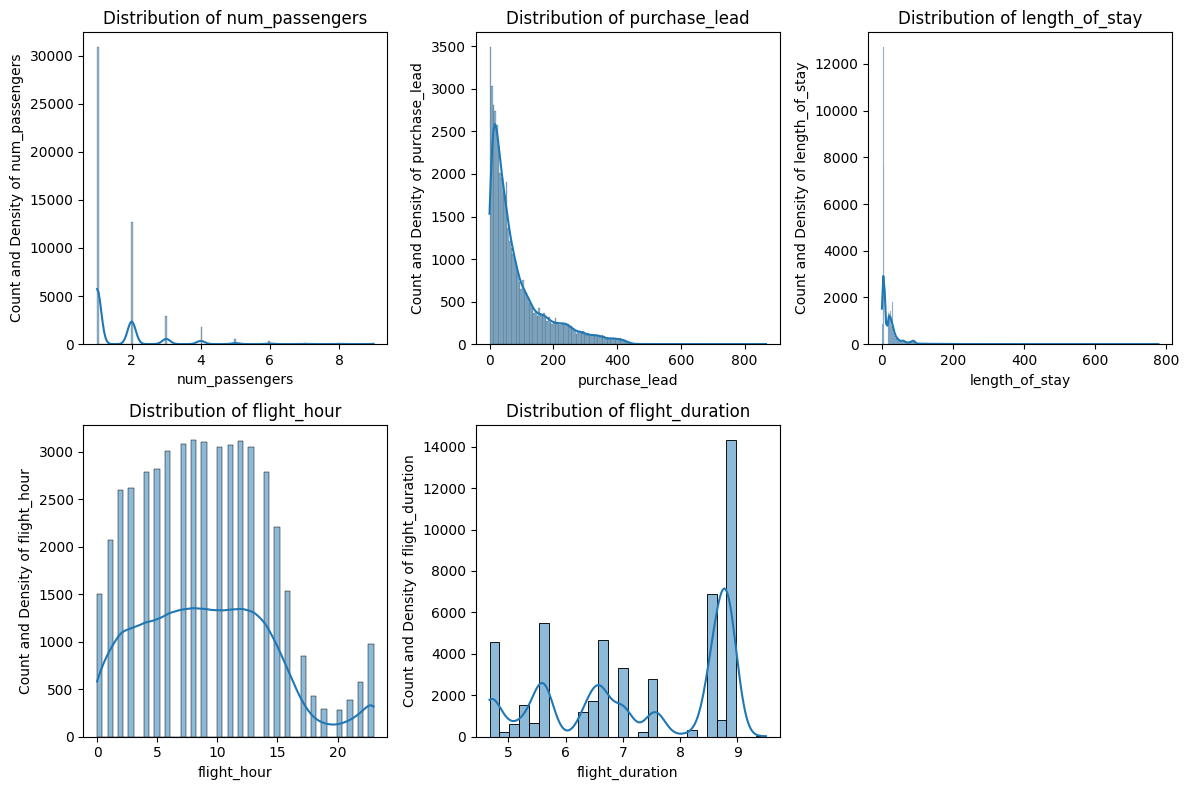

In [20]:
# Hisplot function implementation
plot_dynamic_hisplots_kdeplots(df=df, col_series=nums, ncols=3, figsize=(12, 8))

The distribution of several categorical features are bimodal, while for the `num_passengers`, `purchase_lead` and `lenght_of_stay` have positive/right skewed distribution, we will filter this whether using standarization or log transformation.

In [21]:
# Distribution type analysis
def identify_distribution_types(df, col_series, uniform_cols=None, multimodal_cols=None):
    """
    Identifies and categorizes the distribution type of each numerical column in the DataFrame based on skewness and kurtosis.
    Allows manual specification of columns suspected to be uniform or bimodal/multimodal.

    Parameters:
    df : pd.DataFrame
        The input DataFrame containing the data.
    col_series : list of str
        List of column names to analyze for distribution type.
    uniform_cols : list of str, optional
        List of column names suspected to be uniform. Default is None.
    bimodal_cols : list of str, optional
        List of column names suspected to be bimodal/multimodal. Default is None.

    Returns:
    pd.DataFrame: A DataFrame containing the columns' names, skewness values, kurtosis values, and identified distribution type.
    """
    # Initialize lists to store results
    mean_list = []
    median_list = []
    mode_list = []
    skew_type_list = []
    skew_val_list = []
    kurtosis_val_list = []

    # Loop through each column to calculate distribution metrics
    for col in col_series:
        data = df[col].dropna()  # Remove any NaN values

        # Calculate summary statistics
        mean = round(data.mean(), 3)
        median = data.median()
        mode = data.mode()[0] if not data.mode().empty else median  # Handle case where mode is empty
        skew_val = round(skew(data, nan_policy="omit"), 3)
        kurtosis_val = round(kurtosis(data, nan_policy="omit"), 3)

        # Identify distribution type based on skewness and summary statistics
        if (mean == median == mode) or (-0.2 < skew_val < 0.2):
            skew_type = "Normal Distribution (Symmetric)"
        elif mean < median < mode:
            if skew_val <= -1:
                skew_type = "Highly Negatively Skewed"
            elif -0.5 >= skew_val > -1:
                skew_type = "Moderately Negatively Skewed"
            else:
                skew_type = "Moderately Normal Distribution (Symmetric)"
        else:
            if skew_val >= 1:
                skew_type = "Highly Positively Skewed"
            elif 0.5 <= skew_val < 1:
                skew_type = "Moderately Positively Skewed"
            else:
                skew_type = "Moderately Normal Distribution (Symmetric)"

        # Append the results to the lists
        mean_list.append(mean)
        median_list.append(median)
        mode_list.append(mode)
        skew_type_list.append(skew_type)
        skew_val_list.append(skew_val)
        kurtosis_val_list.append(kurtosis_val)

    # Create a DataFrame to store the results
    dist = pd.DataFrame({
        "Column Name": col_series,
        "Mean": mean_list,
        "Median": median_list,
        "Mode": mode_list,
        "Skewness": skew_val_list,
        "Kurtosis": kurtosis_val_list,
        "Type of Distribution": skew_type_list
    })

    # Manually assign specific distributions based on user-provided column names
    if uniform_cols:
        dist.loc[dist['Column Name'].isin(uniform_cols), 'Type of Distribution'] = 'Uniform Distribution'
    if multimodal_cols:
        dist.loc[dist['Column Name'].isin(multimodal_cols), 'Type of Distribution'] = 'Multi-modal Distribution'

    return dist

In [22]:
# Distribution type function implementation
columns_to_check = nums # List of columns to check distribution
uniform_columns = []  # List of uniform columns (special case)
multimodal_columns = ['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']  # List of multi-modal columns (special case)

identify_distribution_types(df, col_series=columns_to_check, uniform_cols=uniform_columns, multimodal_cols=multimodal_columns)

,Column Name,Mean,Median,Mode,Skewness,Kurtosis,Type of Distribution
0,num_passengers,1.590,1.00,1.00,2.688,10.075,Highly Positively Skewed
1,purchase_lead,84.723,51.00,1.00,1.657,2.501,Highly Positively Skewed
2,length_of_stay,23.054,17.00,6.00,5.296,49.360,Highly Positively Skewed
3,flight_hour,9.071,9.00,8.00,0.398,-0.300,Moderately Normal Distribution (Symmetric)
4,flight_duration,7.280,7.57,8.83,-0.362,-1.373,Moderately Normal Distribution (Symmetric)


In [23]:
# Boxplot analysis
def plot_dynamic_boxplots_violinplots(df, col_series, plot_type='boxplot', ncols=6, figsize=(26, 18), orientation='v', hue=None):
    """
    Creates a dynamic grid of either boxplots or violin plots for multiple numerical columns.

    Parameters:
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data to plot.
    col_series : list of str
        List of column names to include in the plots.
    plot_type : str, optional, default='boxplot'
        Type of plot to generate. Options are 'boxplot' or 'violinplot'.
    ncols : int, optional, default=6
        Number of columns in the subplot grid. Adjust this value to change grid width.
    figsize : tuple, optional, default=(26, 18)
        Size of the figure to control plot dimensions.
    orientation : str, optional, default='v'
        Orientation of the plots. Use 'v' for vertical and 'h' for horizontal.
    hue : str, optional, default=None
        Column name to use for color encoding. Creates separate plots for each category.

    Returns:
    -------
    None
        Displays a grid of plots.

    Examples:
    --------
    >>> # Create vertical boxplots
    >>> plot_dynamic_boxplots_violinplots(df, ['col1', 'col2'], plot_type='boxplot', orientation='v')

    >>> # Create horizontal violin plots with categorical splitting
    >>> plot_dynamic_boxplots_violinplots(df, ['col1', 'col2'], plot_type='violinplot',
                                        orientation='h', hue='category')
    """
    # Validate plot_type parameter
    if plot_type not in ['boxplot', 'violinplot']:
        raise ValueError("plot_type must be either 'boxplot' or 'violinplot'")

    # Calculate required number of rows based on number of plots and specified columns
    num_plots = len(col_series)
    nrows = math.ceil(num_plots / ncols)

    # Adjust figsize based on orientation
    if orientation == 'h':
        figsize = (figsize[1], figsize[0])  # Swap width and height for horizontal plots

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    
    # Convert ax to array if it's a single subplot
    if num_plots == 1:
        ax = np.array([ax])
    else: 
        ax = ax.flatten()  # Flatten the axes array for easy indexing

    # Generate plots for each column
    for i, col in enumerate(col_series):
        if plot_type == 'boxplot':
            if orientation == 'v':
                sns.boxplot(data=df, ax=ax[i], y=col, orient='v', hue=hue)
                ax[i].set_title(f'Boxplot of {col}')
            else:  # orientation == 'h'
                sns.boxplot(data=df, ax=ax[i], x=col, orient='h', hue=hue)
                ax[i].set_title(f'Boxplot of {col}')
        else: # violinplot
            if orientation == 'v':
                sns.violinplot(data=df, ax=ax[i], y=col, orient='v', hue=hue, inner_kws=dict(box_width=15, whis_width=2))
                ax[i].set_title(f'Violinplot of {col}')
            else:  # orientation == 'h'
                sns.violinplot(data=df, ax=ax[i], x=col, orient='h', hue=hue, inner_kws=dict(box_width=15, whis_width=2))
                ax[i].set_title(f'Violinplot of {col}')

    # Remove any unused subplots if total subplots exceed columns in cols
    for j in range(num_plots, len(ax)):
        fig.delaxes(ax[j])

    plt.tight_layout()  # Adjust layout to avoid overlap
    plt.show()

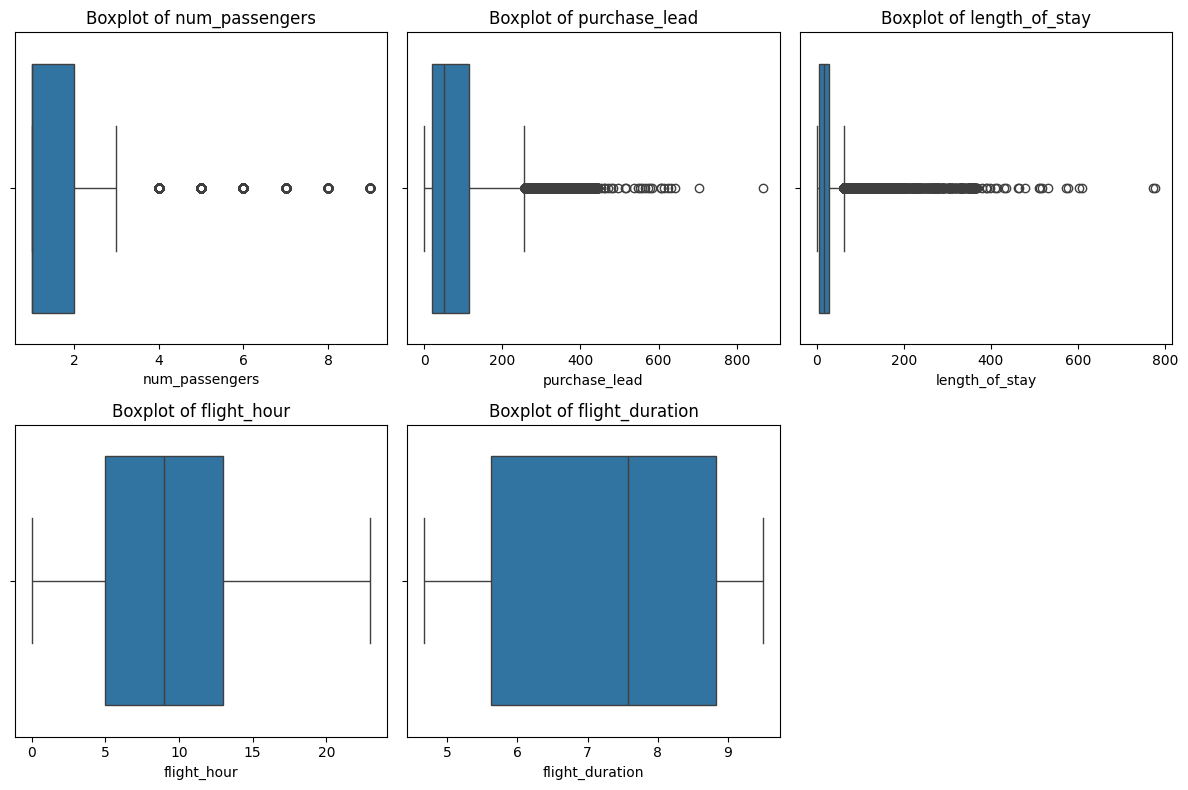

In [24]:
# Boxplot function implementation
plot_dynamic_boxplots_violinplots(df, col_series=nums, ncols=3, figsize=(8, 12), orientation='h')

First we can see that there are quite amount of outliers in `num_passengers`, `purchase_lead` and `lenght_of_stay` feature. Since these features show right-skewed distributions (as indicated by positive skewness values), using IQR would be more appropriate than Z-Score for outlier filtering. Z-Score assumes normal distribution, while IQR is more robust for skewed data and less influenced by extreme values.

In [25]:
# Detect outliers in dataframe using IQR or Z-Score method
def outlier_detection(df, col_series, method='iqr', threshold=3):
    """
    Function to detect outliers in a dataframe using either the IQR or Z-Score method.
    
    Parameters:
    -----------
    df : pd.DataFrame 
        The dataframe containing the data.
    col_series : list of str
        List of column names to include in the analysis.
    method : str, optional (default='iqr')
        The method to use for outlier detection.
        Valid options are:
        - 'iqr': Interquartile Range method (default)
        - 'zscore': Z-Score method
    threshold : float, optional (default=3)
        For IQR method: multiplier for IQR to determine outlier bounds (default is 1.5)
        For Z-Score method: number of standard deviations to use as the outlier cutoff
    
    Returns:
    --------
    pd.DataFrame
        A summary dataframe containing:
        - Column Name: Name of the analyzed column
        - Outlier Exist: Boolean indicating if outliers were found
        - Lower Limit: Lower bound for outlier detection
        - Upper Limit: Upper bound for outlier detection
        - Outlier Data: Number of outliers detected
        - Non-Outlier Data: Number of non-outliers
        - Outlier Percentage (%): Percentage of data points identified as outliers
    
    Examples:
    --------
    # Using IQR method
    result_iqr = outlier_detection(df, ['column1', 'column2'], method='iqr')
    
    # Using Z-Score method
    result_zscore = outlier_detection(df, ['column1', 'column2'], method='zscore', threshold=3)
    """
    # Input validation
    if method.lower() not in ['iqr', 'zscore']:
        raise ValueError("Method must be either 'iqr' or 'zscore'")
    
    print(f'Amount of Rows: {len(df)}')
    
    # Initialize lists to store results
    outlier = []  # Store the number of outlier rows per column
    no_outlier = []  # Store the number of non-outlier rows per column
    is_outlier = []  # Boolean indicating whether any outliers exist in the column
    low_bound = []  # Lower bound for outliers
    high_bound = []  # Upper bound for outliers
    outlier_percentage = []  # Percentage of outliers for each column

    # Start with all rows marked as True (non-outliers) in the cumulative filter
    filtered_entries = np.array([True] * len(df))

    # Loop through each column
    for col in col_series:
        if method.lower() == 'iqr':
            # IQR method
            Q1 = df[col].quantile(0.25)  # First quartile (25th percentile)
            Q3 = df[col].quantile(0.75)  # Third quartile (75th percentile)
            IQR = Q3 - Q1  # Interquartile range
            lower_bound = Q1 - (IQR * 1.5)  # Lower bound for outliers
            upper_bound = Q3 + (IQR * 1.5)  # Upper bound for outliers

            # Create a filter that identifies non-outliers for the current column
            filter_outlier = ((df[col] >= lower_bound) & (df[col] <= upper_bound))
            
        elif method.lower() == 'zscore':
            # Z-Score method
            
            # Calculate Z-Scores
            z_scores = np.abs(stats.zscore(df[col]))

            # Create a filter that identifies non-outliers
            filter_outlier = (z_scores < threshold)
            
            mean = df[col].mean() # mean of the column
            std = df[col].std() # standard deviation of the column
            lower_bound = mean - (threshold * std) # Lower bound for outliers
            upper_bound = mean + (threshold * std) # Upper bound for outliers

        # Calculate statistics
        outlier_count = len(df[~filter_outlier]) # Count of outliers
        non_outlier_count = len(df[filter_outlier]) # Count of non-outliers
        outlier_pct = round((outlier_count / len(df)) * 100, 2) # Percentage of outliers

        # Store results
        outlier.append(outlier_count)
        no_outlier.append(non_outlier_count)
        is_outlier.append(df[col][~filter_outlier].any()) # Whether any outliers exist
        low_bound.append(lower_bound)
        high_bound.append(upper_bound)
        outlier_percentage.append(outlier_pct)

        # Update cumulative filter
        filtered_entries = filtered_entries & filter_outlier

    # Print summary statistics
    print(f'Amount of Outlier Rows (Across All Columns): {len(df[~filtered_entries])}')
    print(f'Amount of Non-Outlier Rows (Across All Columns): {len(df[filtered_entries])}')
    print(f'Percentage of Outliers: {round(len(df[~filtered_entries]) / len(df) * 100, 2)}%')
    print()

    # Create and return summary dataframe
    check_outliers = pd.DataFrame({
        'Column Name': col_series,
        'Outlier Exist': is_outlier,
        'Lower Limit': low_bound,
        'Upper Limit': high_bound,
        'Outlier Data': outlier,
        'Non-Outlier Data': no_outlier,
        'Outlier Percentage (%)': outlier_percentage
    })

    return check_outliers

In [26]:
# Outliers cheking with IQR method function implementation
outlier_summary = outlier_detection(df, col_series=nums, method='zscore', threshold=3)
outlier_summary

Amount of Rows: 49281
Amount of Outlier Rows (Across All Columns): 2804
Amount of Non-Outlier Rows (Across All Columns): 46477
Percentage of Outliers: 5.69%



,Column Name,Outlier Exist,Lower Limit,Upper Limit,Outlier Data,Non-Outlier Data,Outlier Percentage (%)
0,num_passengers,True,-1.459426,4.639799,1084,48197,2.20
1,purchase_lead,True,-186.507407,355.953968,963,48318,1.95
2,length_of_stay,True,-78.442472,124.550424,805,48476,1.63
3,flight_hour,False,-7.168621,25.309973,0,49281,0.00
4,flight_duration,False,2.790804,11.769144,0,49281,0.00


Since the outliers only around 5%, we would handle by filtering them out, not rely on imputation or scaling the outliers. 

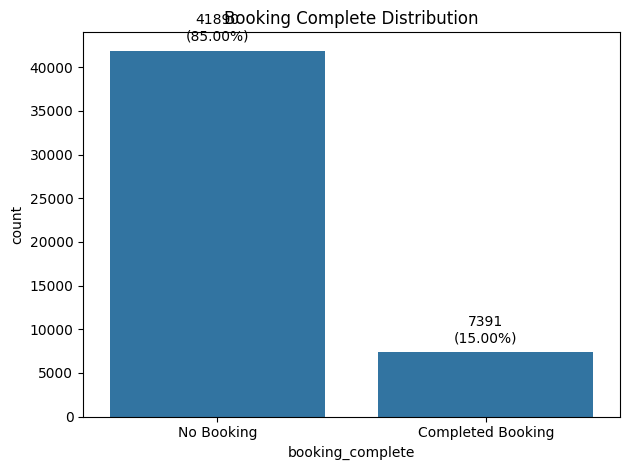

In [27]:
# Univariate booking_complete Only
ax = sns.countplot(data=df, x='booking_complete')

# Get the total count for percentage calculation
total = len(df)

# Annotation of each bar with both count and percentage
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{int(count)}\n({percentage:.2f}%)', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title('Booking Complete Distribution')
plt.tight_layout()
plt.show()

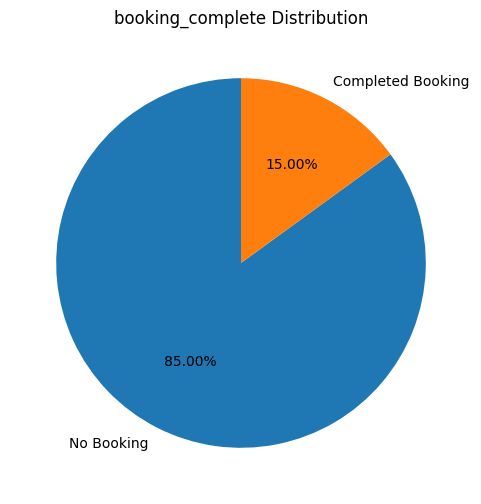

In [28]:
# Creating a pie chart with percentages
plt.figure(figsize=(6, 6))
plt.pie(df['booking_complete'].value_counts(), labels=['No Booking', 'Completed Booking'], autopct='%1.2f%%', startangle=90)
plt.title('booking_complete Distribution')

plt.show()

- As we can that there is quite an class imbalance case here, where the values completed booking (1) only have 15.00 % of total dataset. So in this case we might use resampling method later, either with undersampling or oversampling with SMOTE.

- Note to remember that this is our main goal of this project which is trying to solve the small completed booking number by analyzing the customer booking history and create machine learning model to predict customer booking likelyhood for proactive marketing strategies. 

### Categorical Columns

In [29]:
df[cats].columns

Index(['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin',
       'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals'],
      dtype='object')

In [30]:
# Countplot analysis
def plot_dynamic_countplot(df, col_series, ncols=6, figsize=(26, 18), stat='count', hue=None, order=None):
    """
    Plots a dynamic grid of countplot for a list of categorical columns from a DataFrame.

    Parameters:
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data to plot.
    col_series : list of str
        List of column names to include in the countplots.
    ncols : int, optional, default=6
        Number of columns in the subplot grid. Adjust this value to change grid width.
    figsize : tuple, optional, default=(26, 18)
        Size of the figure to control plot dimensions.
    stat : str, optional, default='count'
        The statistic to compute for the bars
    hue : str, optional, default=None
        Column name to use for color encoding
    order : list, optional, default=None
        Specific ordering for the categorical variables

    Returns:
    -------
    None
        Displays a grid of countplots.
    """

    # Calculate required number of rows based on number of plots and specified columns
    num_plots = len(col_series)
    nrows = math.ceil(num_plots / ncols)

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    
    # Convert ax to array if it's a single subplot
    if num_plots == 1:
        ax = np.array([ax])
    else: 
        ax = ax.flatten()  # Flatten the axes array for easy indexing

    # Generate countplot for each column
    for i, col in enumerate(col_series):
        # Get the specific order for this column if provided
        if isinstance(order, list):
            current_order = order[i].tolist() if hasattr(order[i], 'tolist') else order[i]
        else:
            current_order = None

        sns.countplot(data=df,
                     ax=ax[i],
                     x=col,
                     stat=stat,
                     hue=hue,
                     order=current_order)
        ax[i].set_title(f'Countplot of {col}')
        ax[i].set_ylabel(f'Count of {col}')
        ax[i].set_xlabel(f'{col}')

        # Add value labels on top of bars
        for p in ax[i].patches:
            ax[i].annotate(
                f'{int(p.get_height())}',  # The text to display
                (p.get_x() + p.get_width() / 2., p.get_height()),  # The position
                ha='center',  # Horizontal alignment
                va='bottom'   # Vertical alignment
            )

    # Remove any unused subplots if total subplots exceed columns in cols
    for j in range(num_plots, len(ax)):
        fig.delaxes(ax[j])

    plt.tight_layout()  # Adjust layout to avoid overlap
    plt.show()

In [31]:
# Barplot analysis (Experiment)
def plot_dynamic_barplot(df, col_series, ncols=6, figsize=(26, 18), stat='count', hue=None, order=None, stacked=False):
    """
    Plots a dynamic grid of barplots for a list of categorical columns from a DataFrame.
    Uses value_counts() to prepare data for barplot visualization.

    Parameters:
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data to plot.
    col_series : list of str
        List of column names to include in the barplots.
    ncols : int, optional, default=6
        Number of columns in the subplot grid. Adjust this value to change grid width.
    figsize : tuple, optional, default=(26, 18)
        Size of the figure to control plot dimensions.
    stat : str, optional, default='count'
        The statistic to compute for the bars ('count' or 'percent')
    hue : str, optional, default=None
        Column name to use for color encoding
    order : list, optional, default=None
        Specific ordering for the categorical variables
    stacked : bool, optional, default=False
        Whether to create stacked bars when using hue parameter

    Returns:
    -------
    None
        Displays a grid of barplots.
    """
    # Calculate required number of rows based on number of plots and specified columns
    num_plots = len(col_series)
    nrows = math.ceil(num_plots / ncols)

    # Create subplot grid
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    
    # Convert ax to array if it's a single subplot
    if num_plots == 1:
        ax = np.array([ax])
    else: 
        ax = ax.flatten()

    # Generate barplot for each column
    for i, col in enumerate(col_series):
        # Prepare data for barplot
        if hue is None:
            # Get value counts and convert to DataFrame
            data = df[col].value_counts().reset_index()
            data.columns = [col, 'count']
            
            # Calculate percentages if stat is 'percent'
            y_value = 'count'
            if stat == 'percent':
                data['percent'] = (data['count'] / data['count'].sum()) * 100
                y_value = 'percent'

            # Get the specific order for this column if provided
            if isinstance(order, list):
                current_order = order[i].tolist() if hasattr(order[i], 'tolist') else order[i]
            else:
                current_order = None

            # Create barplot
            sns.barplot(data=data,
                       ax=ax[i],
                       x=col,
                       y=y_value,
                       order=current_order)
            
            # Add value labels
            for p in ax[i].patches:
                height = p.get_height()
                display_value = f'{height:.1f}%' if stat == 'percent' else f'{int(height)}'
                ax[i].annotate(
                    display_value,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center',
                    va='bottom'
                )
        else:
            # Handle hue case with crosstab
            if stacked:
                # Create stacked bars using pandas plot
                data = pd.crosstab(df[col], df[hue], normalize='columns' if stat=='percent' else False)
                data.plot(kind='bar', 
                         stacked=True, 
                         ax=ax[i])
                
                # Add total values on top of stacked bars
                totals = data.sum(axis=1)
                for idx, total in enumerate(totals):
                    display_value = f'{total:.1f}%' if stat == 'percent' else f'{int(total)}'
                    ax[i].text(idx, total, display_value,
                             ha='center', va='bottom')
            else:
                # Original grouped bar implementation
                data = pd.crosstab(df[col], df[hue], normalize='columns' if stat=='percent' else False)
                data = data.reset_index().melt(id_vars=col)
                
                sns.barplot(data=data,
                           ax=ax[i],
                           x=col,
                           y='value',
                           hue=hue)
                
                # Add value labels for grouped bars
                for p in ax[i].patches:
                    height = p.get_height()
                    display_value = f'{height:.1f}%' if stat == 'percent' else f'{int(height)}'
                    ax[i].annotate(
                        display_value,
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center',
                        va='bottom'
                    )

        # Set plot titles and labels
        ax[i].set_title(f'Distribution of {col}')
        ax[i].set_ylabel(f'{"Percentage" if stat=="percent" else "Count"} of {col}')
        ax[i].set_xlabel(f'{col}')
        
        # Rotate x-axis labels if they're too long
        ax[i].tick_params(axis='x', rotation=45)

    # Remove any unused subplots
    for j in range(num_plots, len(ax)):
        fig.delaxes(ax[j])

    plt.tight_layout()
    plt.show()

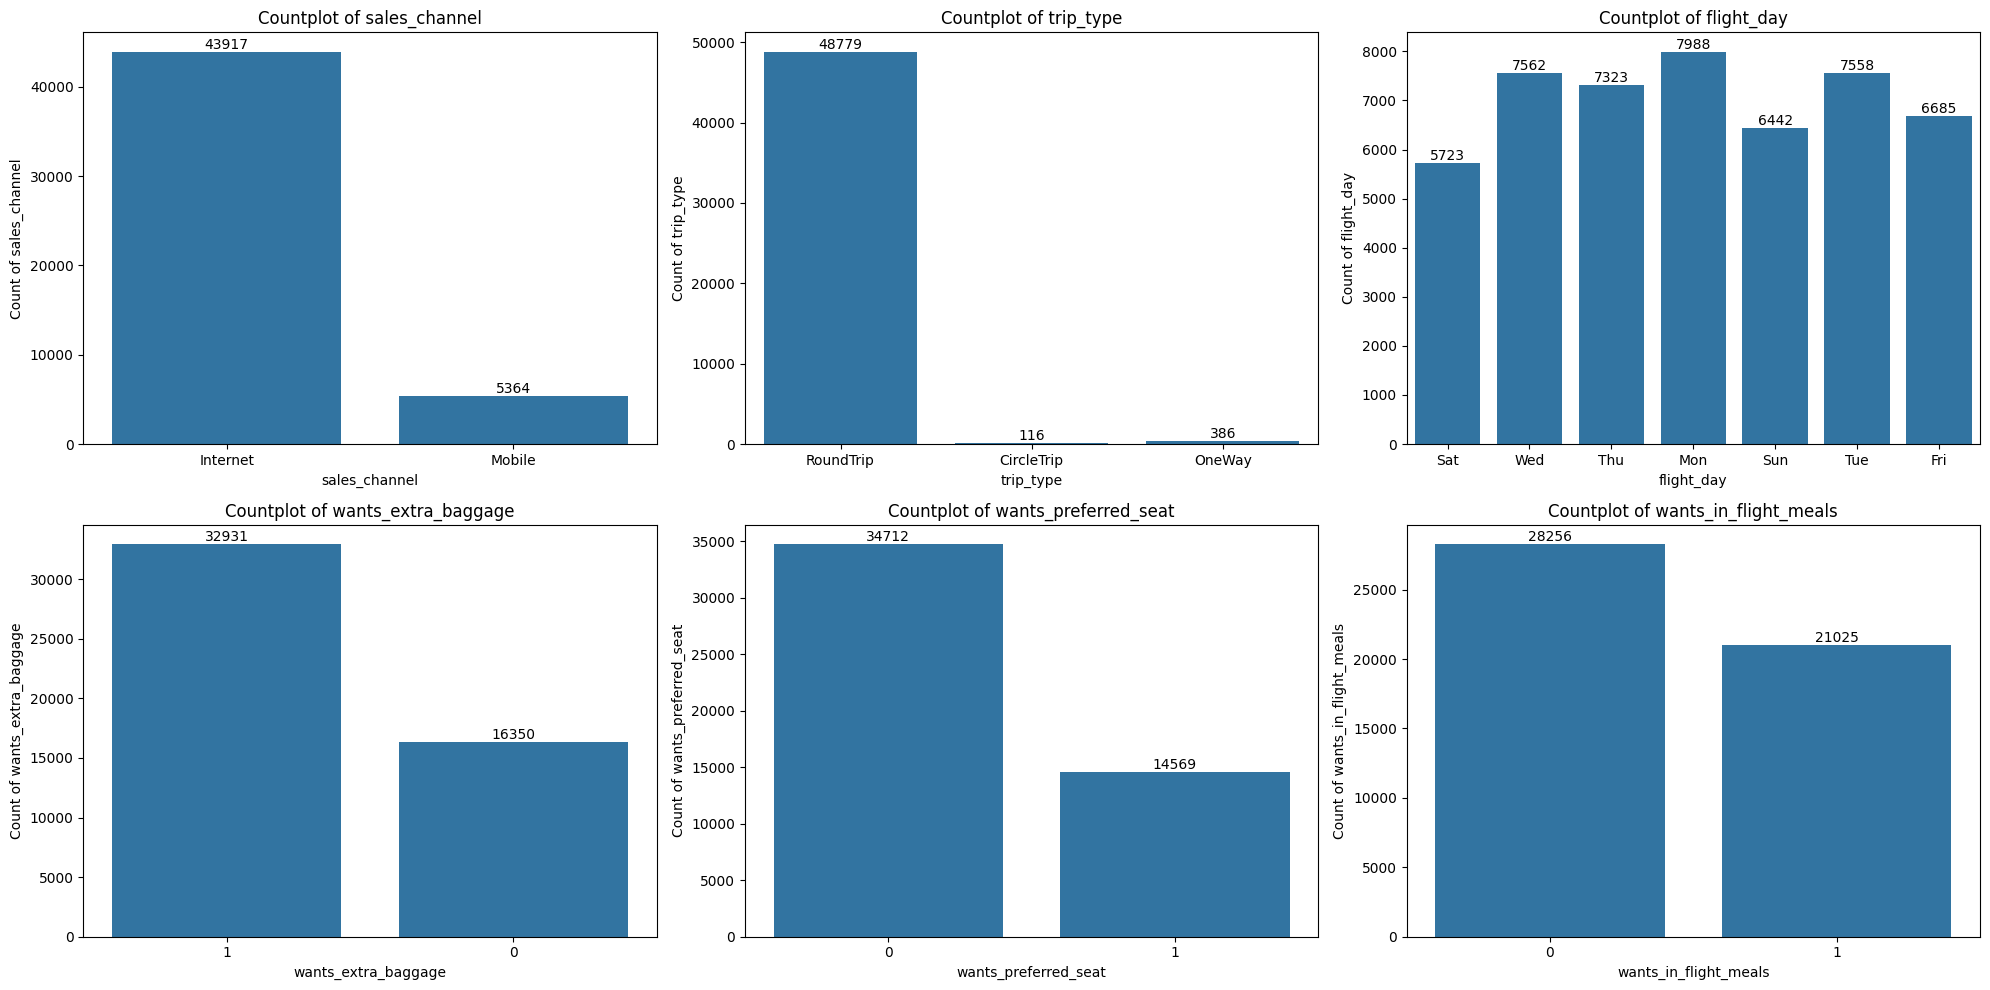

In [32]:
# Countplot function implementation (for few unique values columns)
cats_few = ['sales_channel', 'trip_type', 'flight_day', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']
plot_dynamic_countplot(df=df, col_series=cats_few, ncols=3, figsize=(20, 10))

In [33]:
# # Experiment with barplot
# plot_dynamic_barplot(df, col_series=cats_few, stat='count', figsize=(20, 10), ncols=3)

There is quite an imbalance in the values of feature `sales_channel` and `trip_type` where one category overwhelm the others, we will see it with hue of booking_complete later in the bivariate analysis.

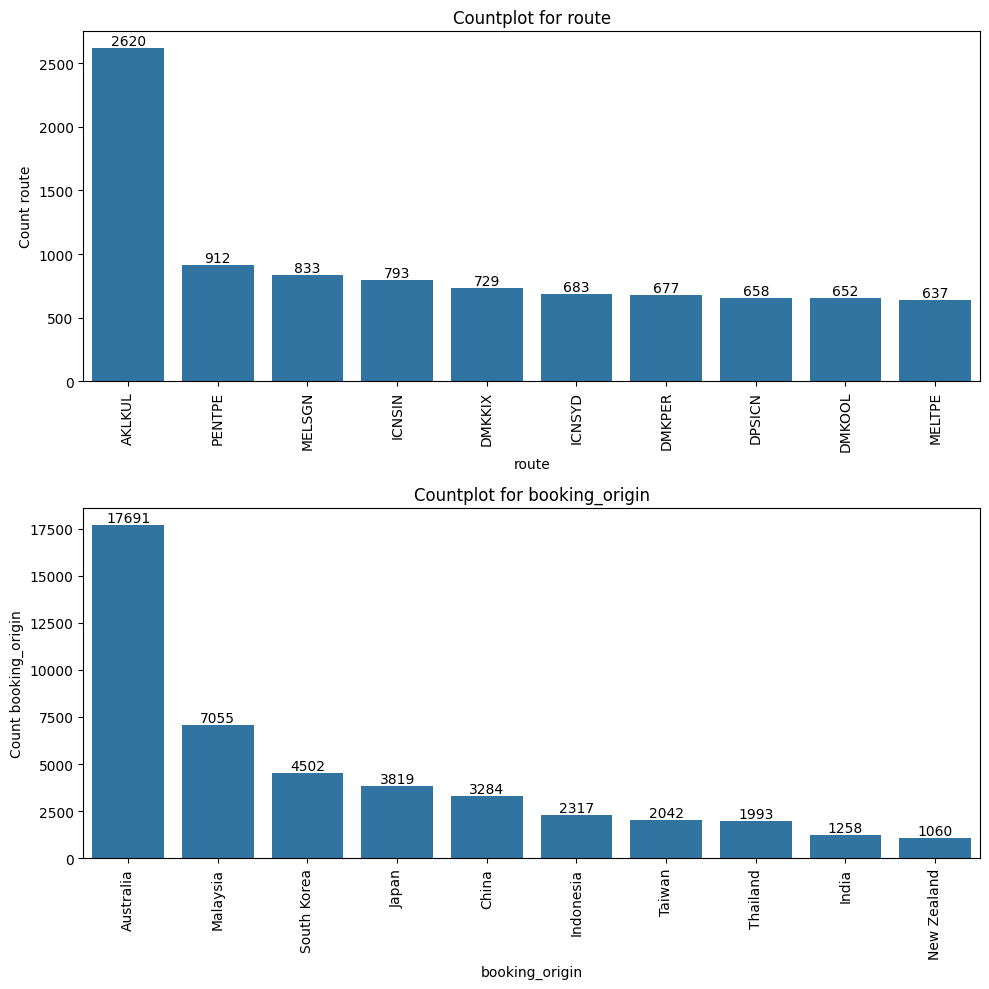

In [34]:
# Categorical Countplot (many unique values)
cats_many = ['route', 'booking_origin']

# Create figure and axes outside the loop
fig, axes = plt.subplots(len(cats_many), 1, figsize=(10, 10))

# If there's only one category, axes will be a single Axes object, not an array
if len(cats_many) == 1:
    axes = [axes]

for i, category in enumerate(cats_many):
    # Get top 10 counts for the current category
    top_10_data = df[category].value_counts().head(10)
    
    # Create countplot on the specific axis
    sns.barplot(x=top_10_data.index, y=top_10_data.values, ax=axes[i])
    
    # Add count values on top of each bar
    for index, value in enumerate(top_10_data.values):
        axes[i].text(index, value + 0.1, str(value), ha='center', va='bottom')
    
    # Set titles and labels for the specific axis
    axes[i].set_title(f'Countplot for {category}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
    axes[i].set_xlabel(category)
    axes[i].set_ylabel(f'Count {category}')

plt.tight_layout()
plt.show()

For categorical feature with many unique values since it is almost impossible to see the entire visualization, we will only make it top 10 or bottom 10.

## Bivariate/Multivariate Analysis

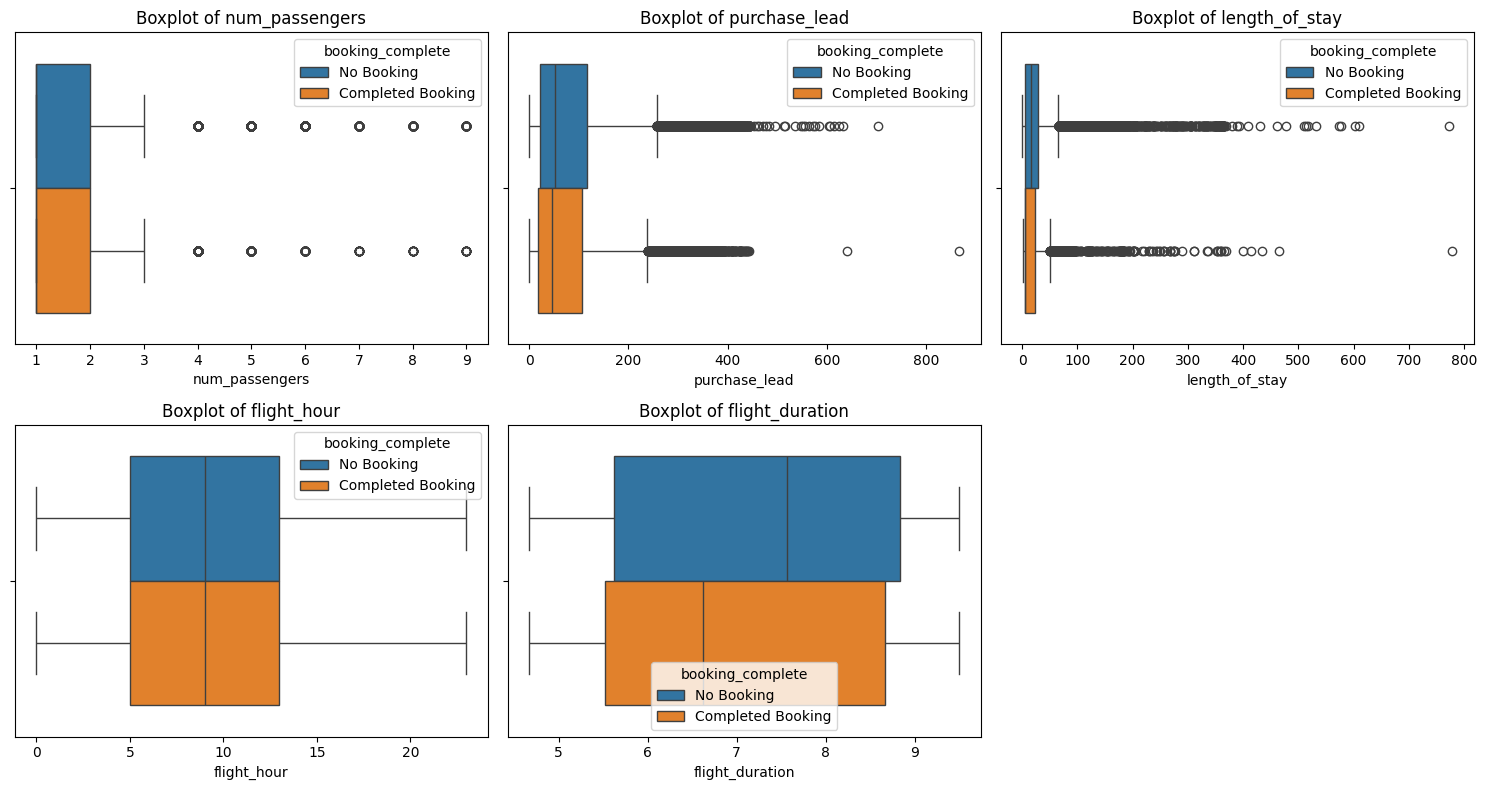

In [35]:
# Boxplot with hue booking_complete
plot_dynamic_boxplots_violinplots(df=df, col_series=nums, hue='booking_complete', orientation='h', ncols=3, figsize=(8, 15))

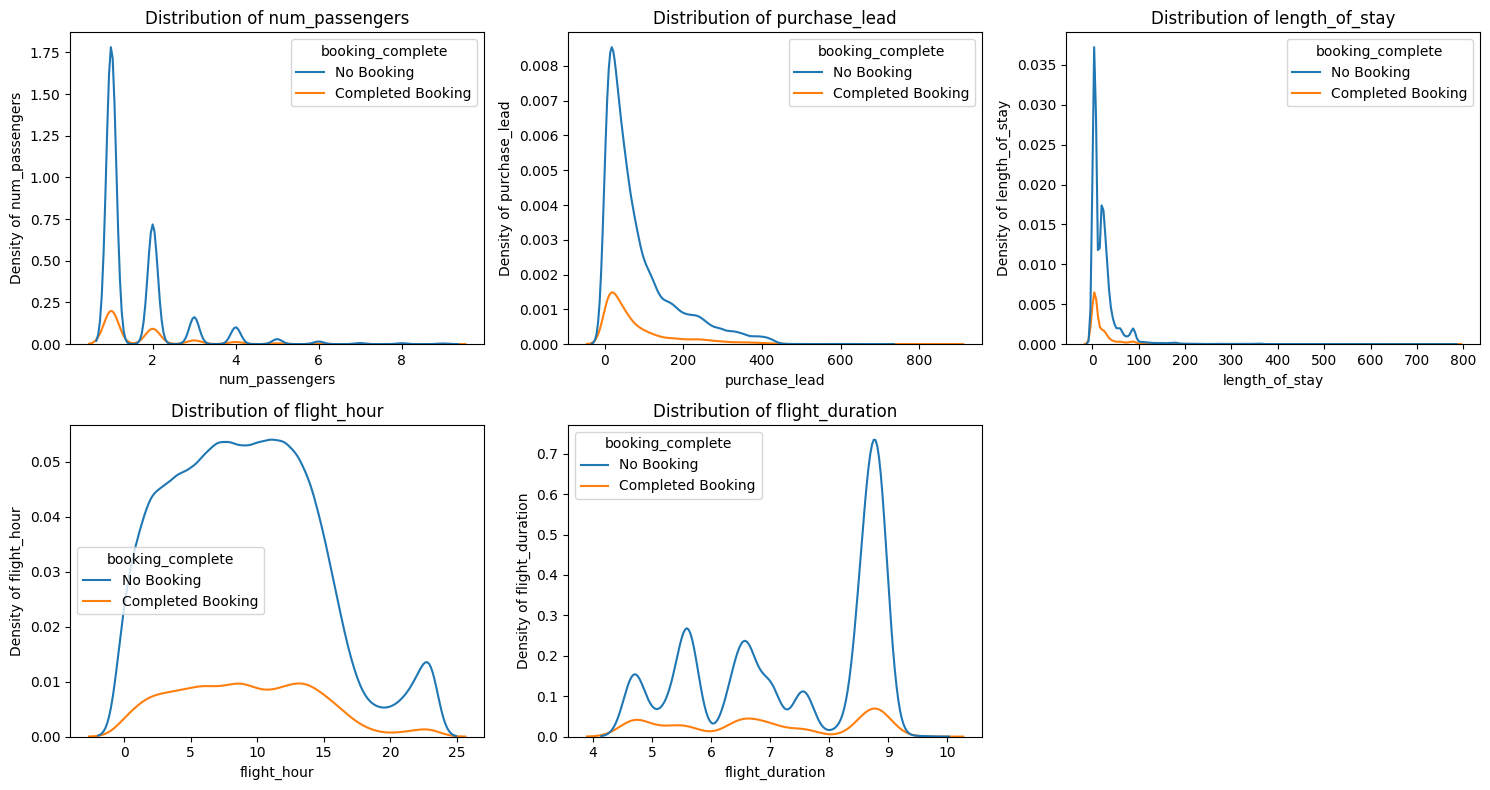

In [36]:
# Kdeplot with hue booking_complete
plot_dynamic_hisplots_kdeplots(df=df, col_series=nums, ncols=3, plot_type='kdeplot', hue='booking_complete', figsize=(15, 8), multiple='layer')

The overall distribution for each feature are quite the same in terms of booking completed or not; only some features have a little more density on some values in booking not completed than completed, but this is related to findings in univariate of booking_complete

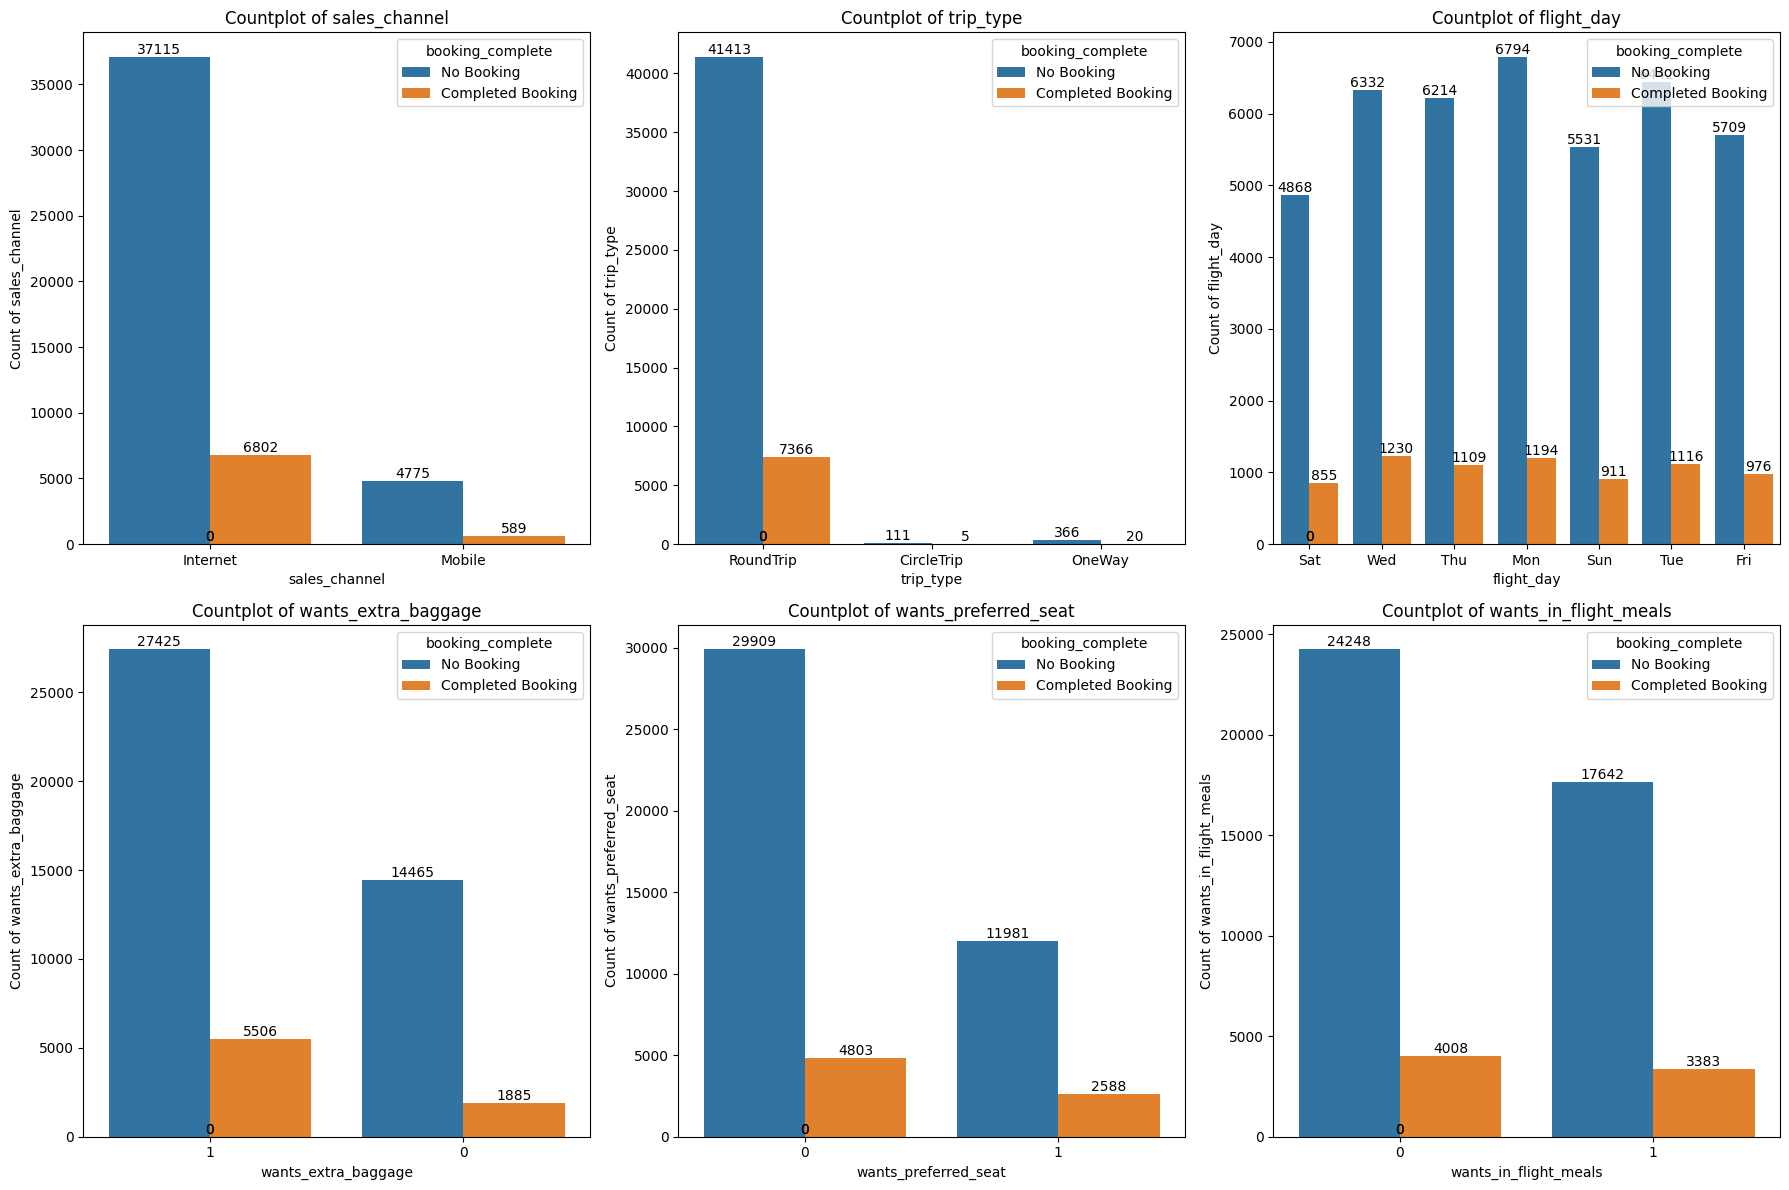

In [37]:
# Countplot with hue booking_complete
plot_dynamic_countplot(df=df, col_series=cats_few, ncols=3, hue='booking_complete', figsize=(18, 12))

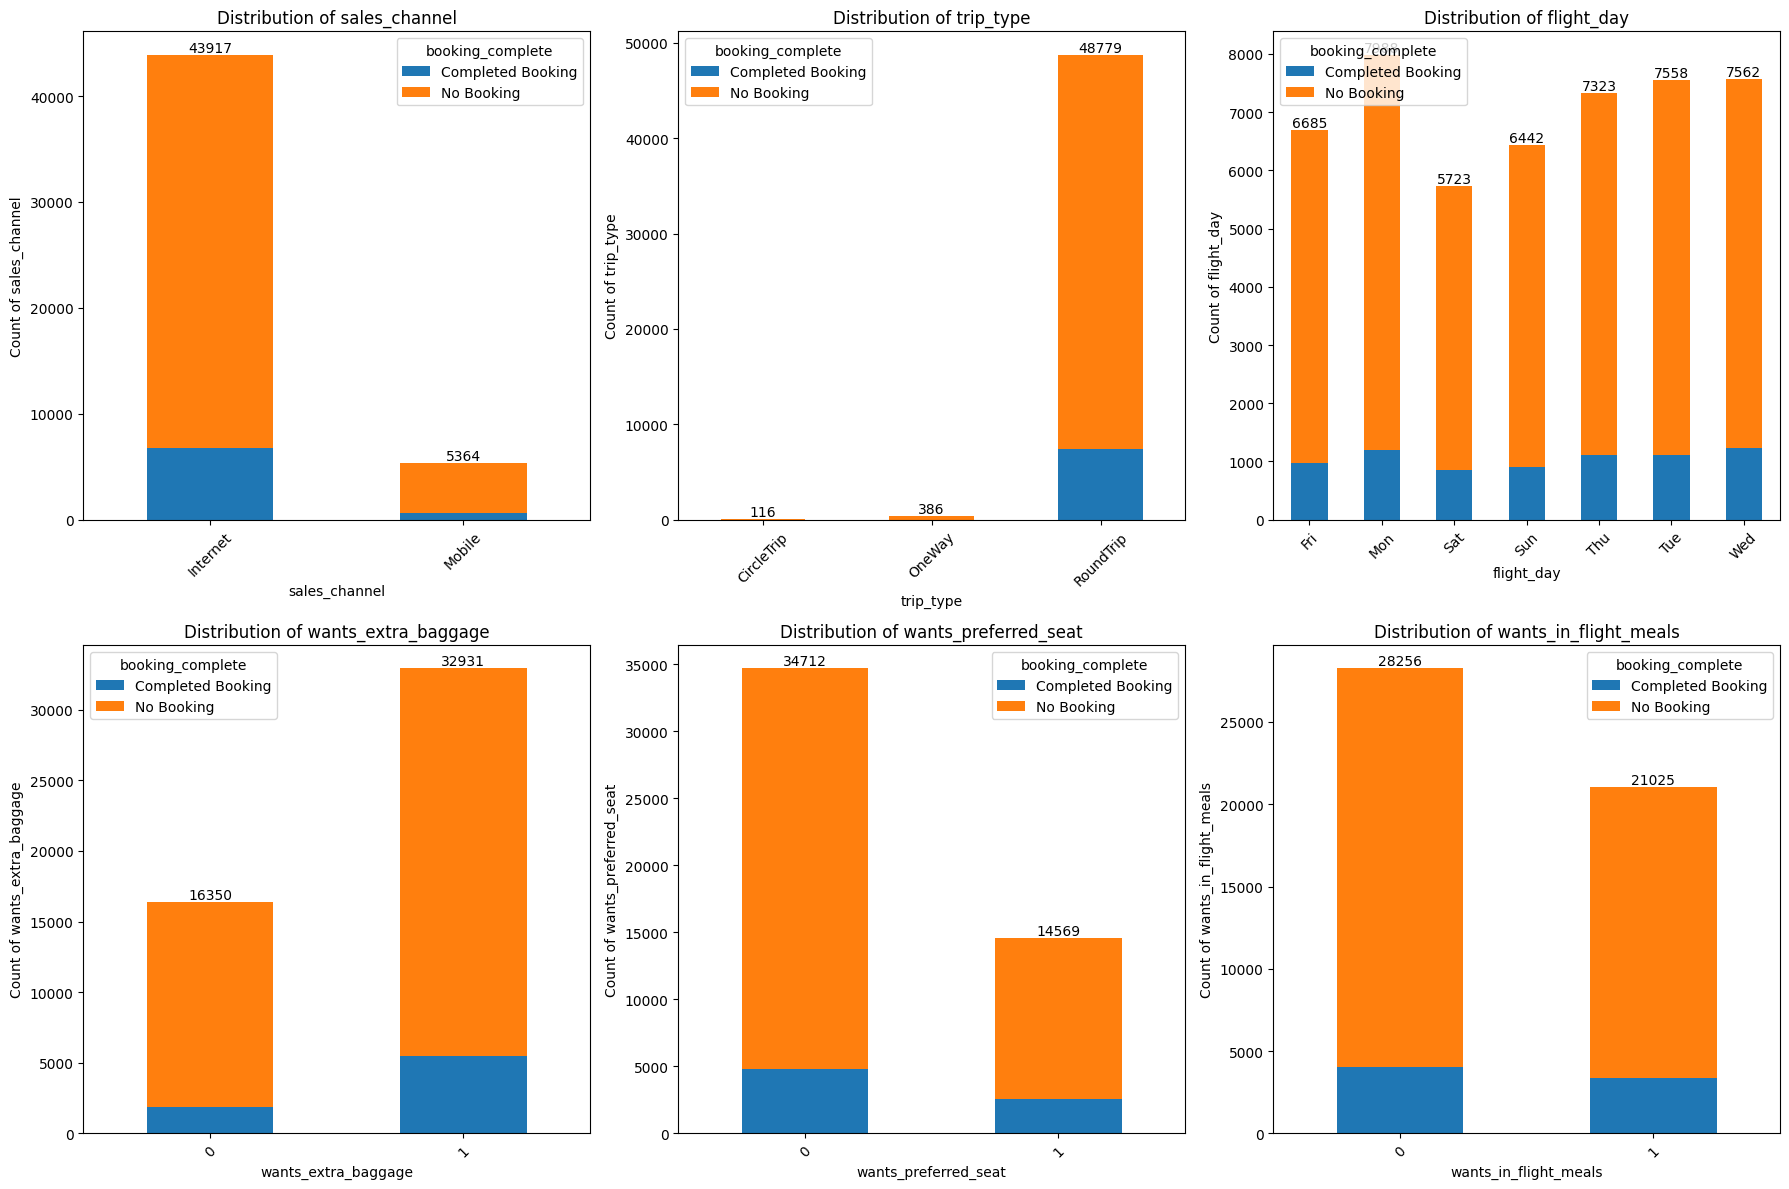

In [38]:
# Stacked chart barplot
plot_dynamic_barplot(df=df, col_series=cats_few, ncols=3, hue='booking_complete', figsize=(18, 12), stacked=True)

Important insights so far:

- There are more people that complete the booking through sales channel of internet than mobile. Also the majority of costumer who complete the booking have round trip as their trip method.

- The imbalance for sales channel and trip type are still the same, but there is something interesting here about the flight_day that we can't see in univariate; that is the customers that completes the booking are actually far less than those who dont. This is in line or related to the original booking complete univariate analysis

In [39]:
change_target_dtype(data=df, target_type='numerical')

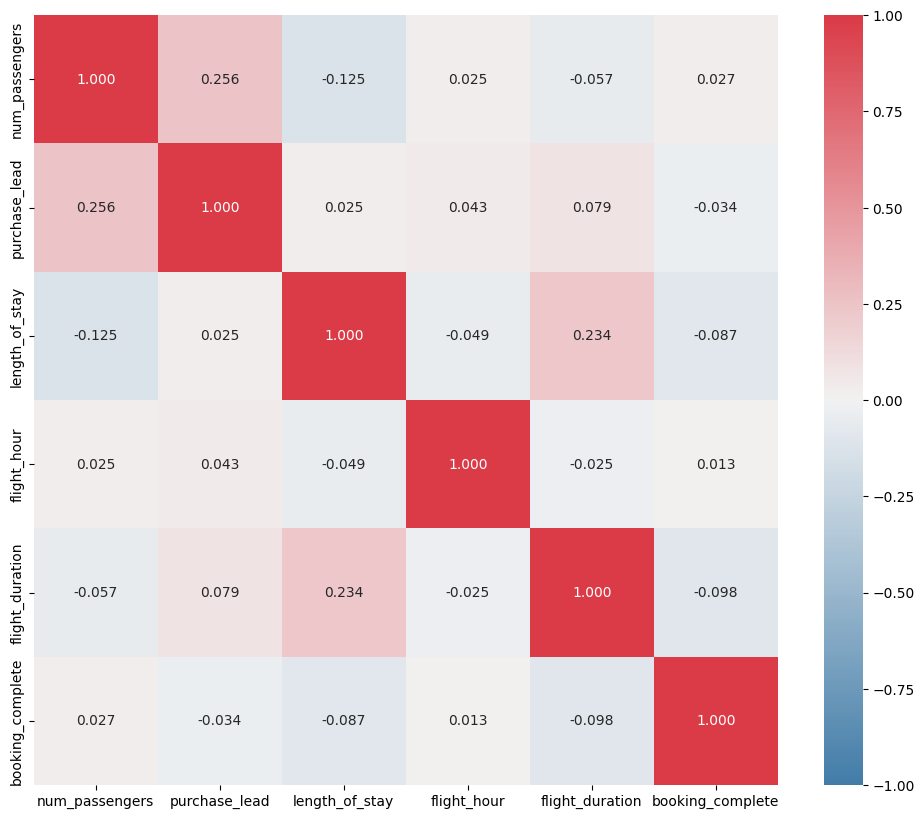

In [40]:
# Heatmap
plt.figure(figsize=(12,10))
cmap_custom = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(data = df.corr(method='spearman', numeric_only=True), cmap=cmap_custom, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.show()

- In this case we use the spearmann method because it is a non-parametric method used when the relationship between variables is monotonic but not necessarily linear. It can be applied to ordinal, interval, or ratio data; compared to pearson correlation that assumes that the variables are normally distributed and have a linear relationship. 

- In this method we can see that `flight_duration` and `lenght_of_stay` are the two feature with the highest correlation even though the overall scores are quite low.

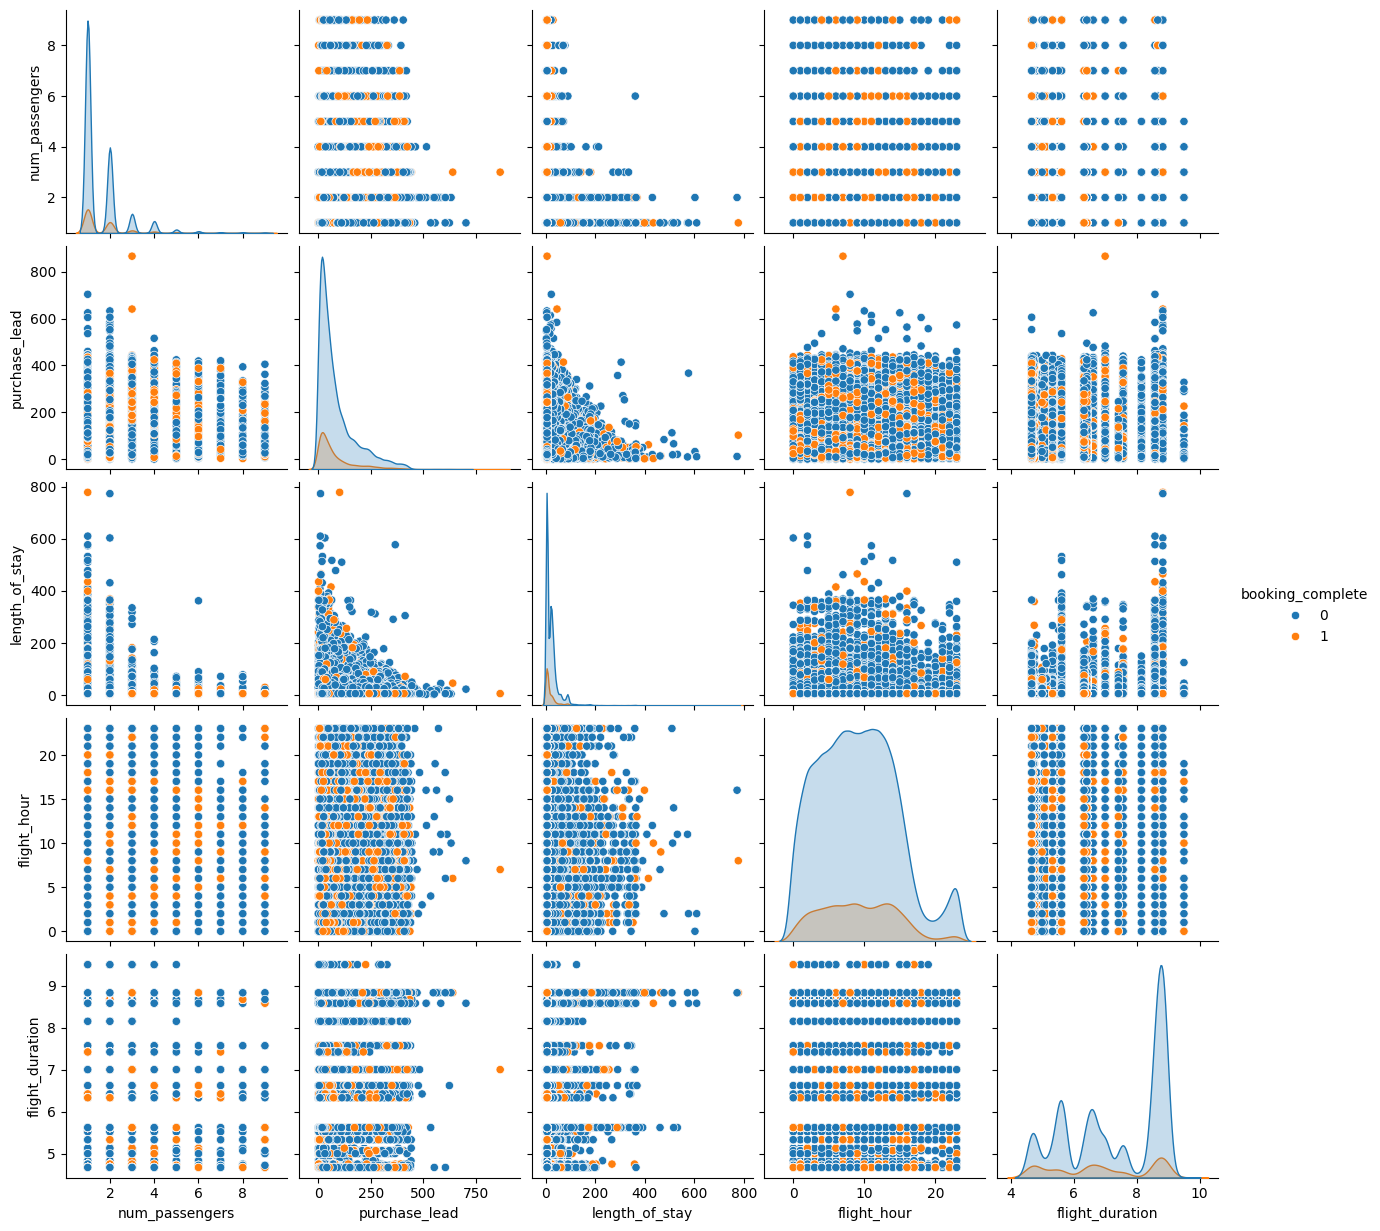

In [41]:
# Pairplot
sns.pairplot(data=df, diag_kind='kde', hue='booking_complete')
plt.show()

The distribution of feature values related to target (booking_complete) are scattered in a non-linear distribution, so we might better use SelectKBest statistical testing to see the feature importance for more information and the correlation heatmap will also help in determining the redundant features. This will be done after we do pre-processing.

# Preprocessing

In [155]:
# Create a new dataframe for preprocessing steps
df_preprocessed = df.copy()

## Feature Engineering

**Additional information to remember about encoding**

The choice between label encoding and one-hot encoding depends on the nature of the data, specifically whether it is nominal or ordinal. Here's a general guideline:

1. **Label Encoding:**
   - **Use Case:** Label encoding is suitable for ordinal data, where there is a clear order or ranking among the categories.
   - **How it works:** It assigns integer values to categories based on their order.
   - **Example:** If you have ordinal data like "low," "medium," and "high," you can assign them values like 1, 2, and 3.

2. **One-Hot Encoding:**
   - **Use Case:** One-hot encoding is suitable for nominal data, where categories have no inherent order or ranking.
   - **How it works:** It creates binary columns for each category, where each column represents the presence or absence of a category.
   - **Example:** For nominal data like colors (e.g., red, blue, green), one-hot encoding would create three binary columns, each representing the presence or absence of a specific color.

   In summary, use label encoding when dealing with ordinal data, where there is a meaningful order among categories. Use one-hot encoding for nominal data when the categories have no inherent order. It's essential to choose the appropriate encoding method to avoid introducing unintended relationships or biases into your models based on the encoding choices.

3. **Frequency Encoding:**

   Frequency encoding is a technique where you encode categorical variables based on the frequency or occurrence of each category in the dataset. Unlike label encoding or one-hot encoding, frequency encoding assigns each category a numerical value proportional to its frequency. This method can be used with both nominal and ordinal data, and its suitability depends on the characteristics of the categorical variable.

   Here are some considerations:

   1. **Nominal Data:**
      - Frequency encoding can be applied to nominal data when you want to represent the importance or prevalence of each category based on its frequency in the dataset.
      - It provides a way to capture information about the distribution of categories in a dataset.

   2. **Ordinal Data:**
      - Frequency encoding can also be used with ordinal data if the ordinal categories have a meaningful relationship with their frequencies.
      - However, in cases where the order of categories is crucial, label encoding might be more appropriate.

   3. **Advantages:**
      - Frequency encoding can be beneficial when dealing with high-cardinality categorical features, as it reduces the dimensionality compared to one-hot encoding.
      - It can capture information about the distribution of categories, which may be useful in certain machine learning scenarios.

   4. **Considerations:**
      - Be cautious when applying frequency encoding if the dataset is imbalanced, as it may overemphasize the importance of infrequent categories.
      - Ensure that the encoding aligns with the underlying nature of the data and the goals of your analysis or modeling task.

   In summary, frequency encoding is a versatile technique that can be applied to both nominal and ordinal data. However, as with any encoding method, it's crucial to consider the characteristics of your data and the goals of your analysis when choosing the most appropriate encoding technique.

4. **Binary Encoding:**

   Binary encoding is another encoding technique commonly used for categorical variables. In binary encoding, each category is represented by its binary code. This method is particularly useful when dealing with nominal data. Here are some key points about binary encoding:

   1. **Nominal Data:**
      - Binary encoding is suitable for nominal data, where there is no inherent order among categories.
      - It encodes each category using binary digits (0s and 1s), creating a binary representation for each category.

   2. **Dimensionality Reduction:**
      - Binary encoding helps reduce dimensionality compared to one-hot encoding, which creates a binary column for each category.
      - The number of binary columns needed is log2(N), where N is the number of unique categories.

   3. **Example:**
      - Suppose you have three categories: A, B, and C. Binary encoding might represent them as 00, 01, and 10, respectively.
      - Each category is represented by a unique binary code, and the length of the binary code depends on the number of unique categories.

   4. **Advantages:**
      - Reduces the dimensionality of the dataset compared to one-hot encoding, making it more memory-efficient.
      - Retains some information about the relationships between categories, especially if there is a hierarchy or pattern in the binary codes.

   5. **Considerations:**
      - Like other encoding techniques, binary encoding assumes no inherent order among categories, so it is not suitable for ordinal data.
      - Care should be taken when dealing with high-cardinality features, as the length of the binary codes increases with the number of unique categories.

   In summary, binary encoding is a suitable choice for nominal data when you want to reduce dimensionality while retaining some information about the relationships between categories. As always, the choice of encoding method depends on the characteristics of your data and the requirements of your machine learning task.

In this case, we can use label encoding for sales_channel since it only have 2 value and frequency encoding for route and booking_origin. While one-hot encoding will be applied on flight_day feature. We dont use one-hot encoding on route and booking_origin because the unique values are too many and will cause curse of dimentionality. Though we can also potentially move sales_channel and trip_type to one-hot encoding since they are nominal type not ordinal type, but we will just go with this for now

**Useful information in determining the encoding for trip_type**

In the context of air travel, the terms "one-way trip," "circle trip," and "round trip" refer to different types of flight itineraries. Here's an explanation of each:

1. **One-Way Trip:**
   - **Definition:** A one-way trip refers to a flight itinerary where the traveler purchases a ticket to travel from one point to another without any intention of returning on the same ticket. It's a single journey with no predetermined return date.
   - **Use Case:** One-way tickets are commonly chosen when the traveler's plans are flexible, and they do not have a fixed return date. This could be suitable for individuals who are relocating, planning to stay at a destination for an extended period, or unsure about their return date.

2. **Circle Trip:**
   - **Definition:** A circle trip involves a traveler flying from one location to another, then to additional destinations, and finally returning to the original departure point. The journey forms a circular or loop-like route.
   - **Use Case:** Circle trips are often chosen when travelers want to visit multiple destinations and return to their starting location without retracing their entire route. This type of itinerary is suitable for exploring several places in a region without having to book separate one-way tickets for each leg.

3. **Round Trip:**
   - **Definition:** A round trip, also known as a return trip, involves a traveler flying from one location to another and then returning to the original departure point on the same ticket. It includes both the outbound and return flights.
   - **Use Case:** Round trips are the most common type of flight itinerary and are suitable for travelers with fixed return dates or those planning to return to their starting location. Round trip tickets often offer cost savings compared to purchasing two separate one-way tickets.

In summary, the key difference lies in the structure of the journey:

- **One-Way Trip:** Single journey from one point to another.
- **Circle Trip:** Multiple destinations forming a circular route with a return to the original departure point.
- **Round Trip:** Outbound journey to a destination and a return journey to the original departure point, both included in a single ticket.

In [156]:
# Check unique values in sales_channel
df_preprocessed['sales_channel'].unique()

# Apply label encoding to sales_channel
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_preprocessed['sales_channel'] = le.fit_transform(df_preprocessed['sales_channel'])

# Verify the encoding
print(f"Original values: {le.classes_}")
print(f"Encoded values: {sorted(df_preprocessed['sales_channel'].unique())}")

Original values: ['Internet' 'Mobile']
Encoded values: [0, 1]


In [157]:
# Frequency/Count Encoding
import category_encoders as ce
count_encoder = ce.CountEncoder()

df_preprocessed['route']= count_encoder.fit_transform(df['route'])
df_preprocessed['booking_origin']= count_encoder.fit_transform(df['booking_origin'])

In [158]:
# One-hot Encoding
columns_to_ohe = ['trip_type', 'flight_day']

# Loop through the columns and perform one-hot encoding
for column in columns_to_ohe:
    onehots = pd.get_dummies(df_preprocessed[column], prefix=column, drop_first=True) * 1
    df_preprocessed = pd.concat([df_preprocessed, onehots], axis=1)

# Drop the original columns after one-hot encoding
df_preprocessed = df_preprocessed.drop(columns=columns_to_ohe)

In [159]:
# Re-arrange the columns (booking_complete in last)
target_col = ['booking_complete']
col_order = [col for col in df_preprocessed if col != 'booking_complete'] + target_col
df_preprocessed = df_preprocessed[col_order]

# Drop the origin airport and destination airport column
df_preprocessed = df_preprocessed.drop(columns=['origin_airport', 'destination_airport'])

# Change the data type for flight amenity preference columns
df_preprocessed['wants_extra_baggage'] = df_preprocessed['wants_extra_baggage'].astype('int')
df_preprocessed['wants_preferred_seat'] = df_preprocessed['wants_preferred_seat'].astype('int')
df_preprocessed['wants_in_flight_meals'] = df_preprocessed['wants_in_flight_meals'].astype('int')

## Feature Selection

### Checking correlation heatmap (spearman method)

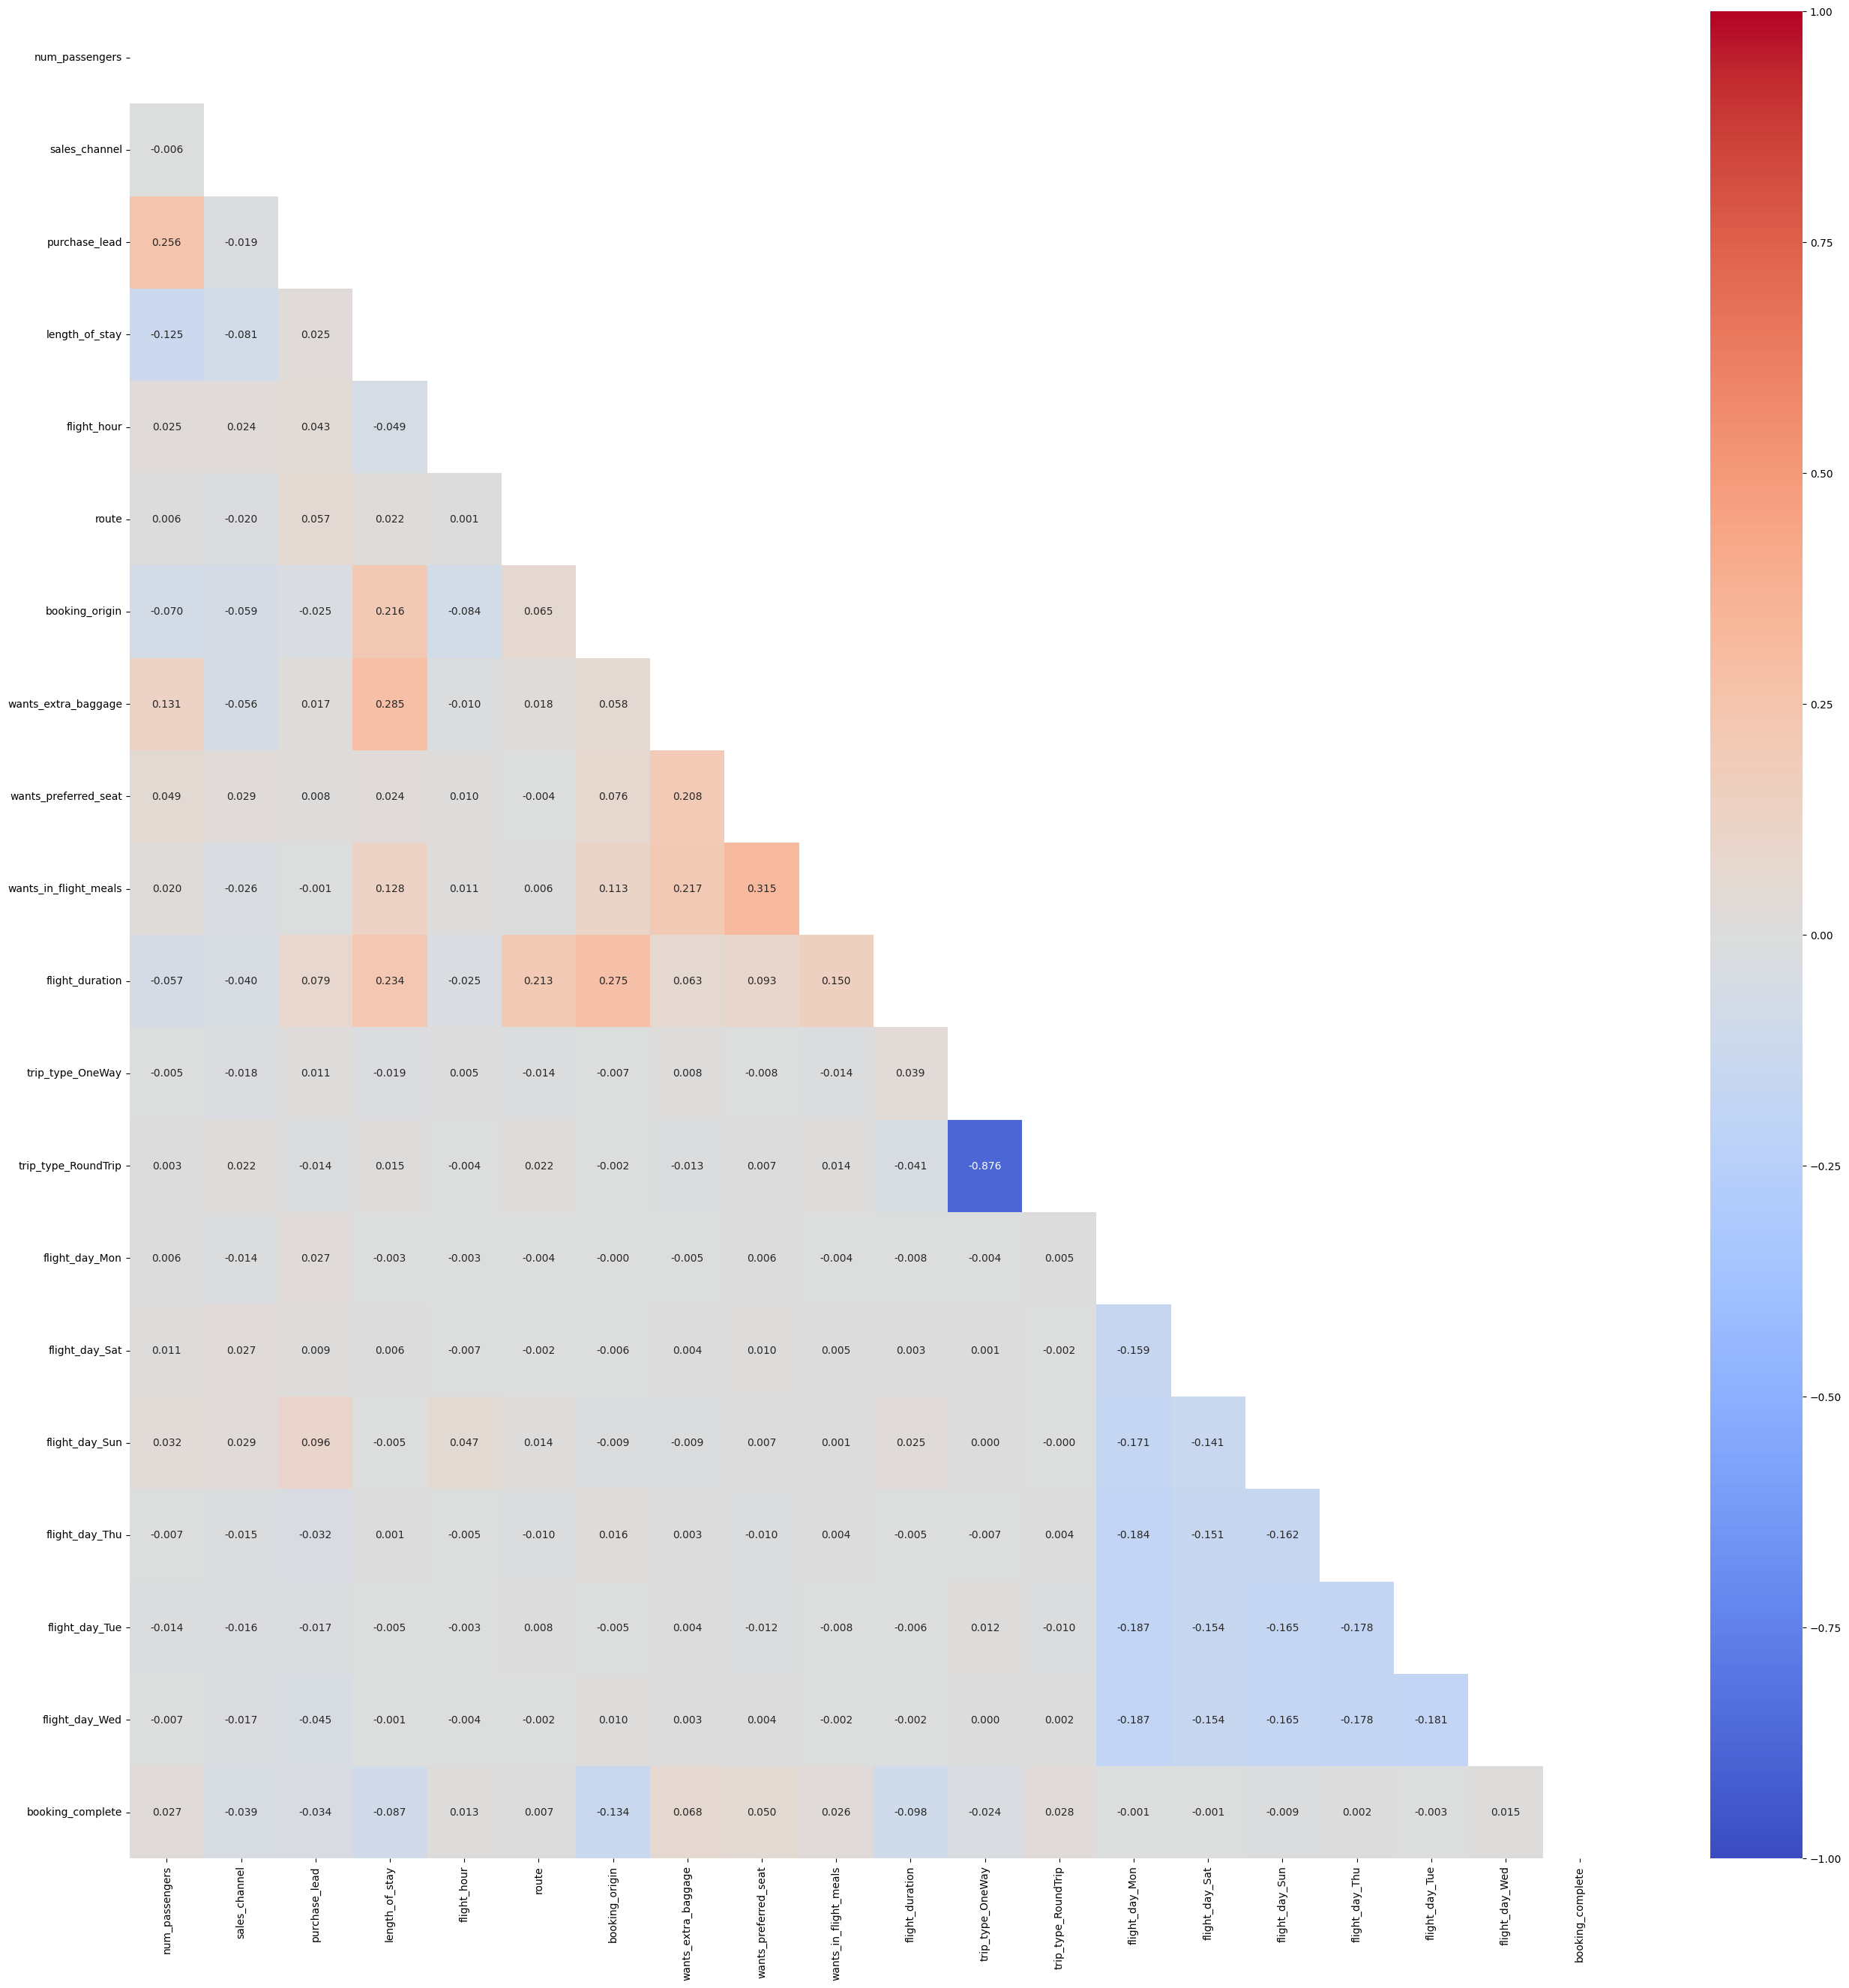

In [160]:
# Heatmap (spearman corr)
plt.figure(figsize=(32, 32))
mask = np.triu(np.ones_like(df_preprocessed.corr(numeric_only=True), dtype=bool))
sns.heatmap(data = df_preprocessed.corr(method='spearman', numeric_only=True), mask=mask, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.show()

In [161]:
# Correlation analysis in tabluar form
def calculate_correlation_tabular(df, target_col, method='spearman', corr_type='feature_feature'):
    """
    Calculate and display correlation analysis in tabular form for feature-to-feature,
    feature-to-target correlations, or both.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the features and target variable
    target_col : str
        Name of the target column in the DataFrame
    method : str, optional (default='spearman')
        Correlation method to use. Options include:
        - 'pearson': standard correlation coefficient
        - 'spearman': Spearman rank correlation
        - 'kendall': Kendall Tau correlation coefficient
    corr_type : str, optional (default='feature_feature')
        Type of correlation analysis to perform:
        - 'feature_feature': correlations between all features
        - 'feature_target': correlations between features and target variable
        - 'both': display both feature-feature and feature-target correlations

    Returns:
    --------
    tuple or pandas.DataFrame
        If corr_type is 'both':
            Returns a tuple (feature_feature_df, feature_target_df)
        Otherwise:
            Returns a single DataFrame containing the correlation analysis results
            
        DataFrame columns for feature_feature:
            - 'A': First feature name
            - 'B': Second feature name
            - 'Corr Value': Absolute correlation value
            - 'Corr Type': 'Positive' or 'Negative'
        DataFrame columns for feature_target:
            - 'Feature': Feature name
            - 'Corr Value': Absolute correlation value
            - 'Corr Type': 'Positive' or 'Negative'

    Raises:
    -------
    ValueError
        If corr_type is not 'feature_feature', 'feature_target', or 'both'
    """
    
    # Input validation for correlation type
    if corr_type not in ['feature_feature', 'feature_target', 'both']:
        raise ValueError("corr_type must be either 'feature_feature', 'feature_target', or 'both'")
    
    def get_feature_feature_corr():
        """
        Helper function to calculate feature-to-feature correlations
        """
        # Calculate correlation matrix for all numeric columns
        corr_feature = df.corr(method=method, numeric_only=True)

        # Convert correlation matrix to long format for better visualization
        flat_cm = corr_feature.stack().reset_index()
        flat_cm.columns = ['A', 'B', 'Corr Value']

        # Apply filters to remove:
        # 1. Self-correlations (A to A)
        # 2. Target variable correlations
        # 3. Duplicate pairs (A-B vs B-A)
        flat_cm = flat_cm.loc[
            (flat_cm['A'] != flat_cm['B']) &  # Remove self-correlations
            (flat_cm['A'] != target_col) &     # Remove target from first column
            (flat_cm['B'] != target_col)       # Remove target from second column
        ]

        # Add correlation type (Positive/Negative) and convert to absolute values
        flat_cm['Corr Type'] = flat_cm['Corr Value'].apply(lambda x: 'Positive' if x >= 0 else 'Negative')
        flat_cm['Corr Value'] = flat_cm['Corr Value'].abs()
        
        # Sort by correlation strength and remove duplicates
        flat_cm = flat_cm.sort_values(by='Corr Value', ascending=False, ignore_index=True)
        redundan_cm = flat_cm.drop_duplicates(subset=['Corr Value', 'Corr Type']).reset_index(drop=True)
        
        print("Correlation Between Features:")
        display(redundan_cm.iloc[:15].reset_index(drop=True))
        return redundan_cm
    
    def get_feature_target_corr():
        """
        Helper function to calculate feature-to-target correlations
        """
        # Calculate correlations between all features and the target variable
        corr_target = df.corrwith(df[target_col], method=method, numeric_only=True)
        
        # Convert to DataFrame for better manipulation
        corr_final = corr_target.reset_index(name='Corr Value').rename(columns={'index': 'Feature'})

        # Remove target variable self-correlation
        corr_final = corr_final.loc[corr_final['Feature'] != target_col]

        # Add correlation type and convert to absolute values
        corr_final['Corr Type'] = corr_final['Corr Value'].apply(lambda x: 'Positive' if x >= 0 else 'Negative')
        corr_final['Corr Value'] = corr_final['Corr Value'].abs()
        
        # Sort by correlation strength
        corr_final = corr_final.sort_values('Corr Value', ascending=False, ignore_index=True)

        print("\nCorrelation of Features to Target:")
        display(corr_final.iloc[:15].reset_index(drop=True))
        return corr_final
    
    # Handle different correlation type requests
    if corr_type == 'feature_feature':
        return get_feature_feature_corr()
    elif corr_type == 'feature_target':
        return get_feature_target_corr()
    else:  # corr_type == 'both'
        # Calculate and return both types of correlations
        feature_feature_df = get_feature_feature_corr()
        feature_target_df = get_feature_target_corr()
        return feature_feature_df, feature_target_df

In [162]:
# Correlation analysis for both feature-feature and feature-target
ff_corr, ft_corr = calculate_correlation_tabular(df_preprocessed, target_col='booking_complete', corr_type='both')

Correlation Between Features:


,A,B,Corr Value,Corr Type
0,trip_type_RoundTrip,trip_type_OneWay,0.875842,Negative
1,wants_in_flight_meals,wants_preferred_seat,0.315162,Positive
2,wants_extra_baggage,length_of_stay,0.284865,Positive
3,booking_origin,flight_duration,0.274545,Positive
4,purchase_lead,num_passengers,0.255729,Positive
5,flight_duration,length_of_stay,0.234047,Positive
6,wants_extra_baggage,wants_in_flight_meals,0.216835,Positive
7,booking_origin,length_of_stay,0.215804,Positive
8,route,flight_duration,0.212599,Positive
9,wants_extra_baggage,wants_preferred_seat,0.208392,Positive



Correlation of Features to Target:


,Feature,Corr Value,Corr Type
0,booking_origin,0.134277,Negative
1,flight_duration,0.097877,Negative
2,length_of_stay,0.086643,Negative
3,wants_extra_baggage,0.068452,Positive
4,wants_preferred_seat,0.050189,Positive
5,sales_channel,0.039320,Negative
6,purchase_lead,0.033627,Negative
7,trip_type_RoundTrip,0.028462,Positive
8,num_passengers,0.027430,Positive
9,wants_in_flight_meals,0.026399,Positive


### Checking multicolinearity using Variance Inflation Factor (VIF)

In [163]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, target_col, high_threshold=10, moderate_threshold=5):
    """
    Calculate VIF for each feature in the dataset.

    Parameters:
    df (pd.DataFrame): Input DataFrame
    target_col (str): Name of target column to exclude

    Returns:
    pd.DataFrame: DataFrame with VIF scores
    """
    # Create DataFrame of features only
    features_df = df.drop(columns=[target_col])

    # Initialize VIF DataFrame
    vif_data = pd.DataFrame()
    vif_data['Feature'] = features_df.columns

    # Calculate VIF for each feature
    try:
        vif_data['VIF'] = [variance_inflation_factor(features_df.values, i)
                          for i in range(features_df.shape[1])]
    except Exception as e:
        print(f"Error calculating VIF: {e}")
        return None

    # Sort by VIF score
    vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

    # Add interpretation column
    vif_data['Interpretation'] = vif_data['VIF'].apply(lambda x:
        'High multicollinearity' if x > high_threshold
        else ('Moderate multicollinearity' if x > moderate_threshold
        else 'Low multicollinearity'))

    return vif_data

In [164]:
# VIF calculation function usage
vif_results = calculate_vif(df_preprocessed.select_dtypes(exclude=['object']), 'booking_complete')

print("Display VIF results:")
display(vif_results)

Display VIF results:


,Feature,VIF,Interpretation
0,trip_type_RoundTrip,35.007708,High multicollinearity
1,flight_duration,29.901040,High multicollinearity
2,flight_hour,3.817453,Low multicollinearity
3,num_passengers,3.750458,Low multicollinearity
4,wants_extra_baggage,3.394746,Low multicollinearity
5,booking_origin,3.025270,Low multicollinearity
6,flight_day_Mon,2.187871,Low multicollinearity
7,flight_day_Wed,2.117848,Low multicollinearity
8,flight_day_Tue,2.117294,Low multicollinearity
9,flight_day_Thu,2.080464,Low multicollinearity


### Checking feature importance using SelectKBest (Mutual information, Chi2, and ANOVA F-test)

In [165]:
# Create temporary dataframe for testing SelectKBest
df_feature_target_relation = df_preprocessed.copy()
df_feature_target_relation.head()

,num_passengers,sales_channel,purchase_lead,length_of_stay,flight_hour,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,trip_type_OneWay,trip_type_RoundTrip,flight_day_Mon,flight_day_Sat,flight_day_Sun,flight_day_Thu,flight_day_Tue,flight_day_Wed,booking_complete
0,2,0,262,19,7,20,1060,1,0,0,5.52,0,1,0,1,0,0,0,0,0
1,1,0,112,20,3,20,1060,0,0,0,5.52,0,1,0,1,0,0,0,0,0
2,2,0,243,22,17,20,1258,1,1,0,5.52,0,1,0,0,0,0,0,1,0
3,1,0,96,31,4,20,1060,0,0,1,5.52,0,1,0,1,0,0,0,0,0
4,2,0,68,22,15,20,1258,1,0,1,5.52,0,1,0,0,0,0,0,1,0


In [166]:
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif,
    f_classif,
    chi2,
    f_regression,
    mutual_info_regression
)

# Calculate feature importance scores using different statistical methods for classification or regression
def calculate_feature_importance(X, y, task='classification', method='mutual_info', k='all'):
    """
    Calculate feature importance scores using different statistical methods for classification or regression.

    Parameters:
    X (DataFrame): Feature matrix
    y (Series): Target variable
    task (str): Task type ('classification' or 'regression')
    method (str): Method for feature selection ('mutual_info', 'anova', 'chi2' for classification; 'f_regression', 'mutual_info' for regression)
    k (int or 'all'): Number of top features to select. Use 'all' to see scores for all features.

    Returns:
    DataFrame: Sorted DataFrame with feature names, scores, and p-values (if applicable)
    """
    # Select the appropriate scoring function based on task and method
    if task == 'classification':
        if method == 'mutual_info':
            score_func = mutual_info_classif
        elif method == 'anova':
            score_func = f_classif
        elif method == 'chi2':
            score_func = chi2
        else:
            raise ValueError("For classification, method must be 'mutual_info', 'anova', or 'chi2'")
    elif task == 'regression':
        if method == 'f_regression':
            score_func = f_regression
        elif method == 'mutual_info':
            score_func = mutual_info_regression
        else:
            raise ValueError("For regression, method must be 'f_regression' or 'mutual_info'")
    else:
        raise ValueError("Task must be 'classification' or 'regression'")

    # Instantiate SelectKBest with the chosen scoring function
    k_best = SelectKBest(score_func=score_func, k=k)

    # Fit the model and transform the data
    k_best.fit_transform(X, y)

    # Extract feature scores and names
    feature_scores = k_best.scores_
    feature_names = X.columns

    # Create a DataFrame to display feature scores
    # Note: p-values are not applicable for mutual_info_classif or mutual_info_regression, hence set to None
    feature_scores_df = pd.DataFrame({
        'Feature': feature_names,
        'Score': feature_scores,
        'P_Values': k_best.pvalues_ if method in ['anova', 'chi2', 'f_regression'] else [None] * len(feature_scores)
    })

    # Sort the DataFrame by scores in descending order
    feature_scores_df = feature_scores_df.sort_values(by='Score', ascending=False)

    return feature_scores_df

In [167]:
# Function implementation (this case is for classification)
x_features_test = df_feature_target_relation.drop(columns=['booking_complete'])  # Features
y_target_test = df_feature_target_relation['booking_complete']  # Target variable

# Calculate feature importance using mutual information
mi_scores_df = calculate_feature_importance(x_features_test, y_target_test, task='classification', method='mutual_info')
print("Mutual Information: ")
display(mi_scores_df.iloc[:15].reset_index(drop=True))

# Calculate feature importance using chi2
chi2_scores_df = calculate_feature_importance(x_features_test, y_target_test, task='classification', method='chi2')
print("Chi2 Test: ")
display(chi2_scores_df.iloc[:15].reset_index(drop=True))

# Calculate feature importance using anova
anova_scores_df = calculate_feature_importance(x_features_test, y_target_test, task='classification', method='anova')
print("ANOVA F-test: ")
display(anova_scores_df.iloc[:15].reset_index(drop=True))

# Bring back the correlation using Spearman for comparison
print("Spearman Correlation :")
ft_corr = calculate_correlation_tabular(df_preprocessed, target_col='booking_complete', corr_type='feature_target')

Mutual Information: 


,Feature,Score,P_Values
0,booking_origin,0.049988,None
1,route,0.041081,None
2,flight_duration,0.016901,None
3,trip_type_RoundTrip,0.009828,None
4,length_of_stay,0.009180,None
5,wants_extra_baggage,0.009156,None
6,wants_in_flight_meals,0.005344,None
7,wants_preferred_seat,0.003318,None
8,purchase_lead,0.003015,None
9,flight_day_Thu,0.002312,None


Chi2 Test: 


,Feature,Score,P_Values
0,booking_origin,8.384306e+06,0.000000e+00
1,route,5.789357e+04,0.000000e+00
2,length_of_stay,4.332449e+03,0.000000e+00
3,purchase_lead,2.328843e+03,0.000000e+00
4,flight_duration,1.720139e+02,2.687311e-39
5,wants_preferred_seat,8.743880e+01,8.692823e-21
6,wants_extra_baggage,7.661047e+01,2.082329e-18
7,sales_channel,6.789687e+01,1.722741e-16
8,trip_type_OneWay,2.917629e+01,6.608283e-08
9,wants_in_flight_meals,1.969178e+01,9.099171e-06


ANOVA F-test: 


,Feature,Score,P_Values
0,booking_origin,1526.360351,0.000000e+00
1,flight_duration,565.655225,2.491830e-124
2,wants_extra_baggage,231.991451,2.885850e-52
3,wants_preferred_seat,124.446250,7.285791e-29
4,length_of_stay,87.413993,9.158134e-21
5,sales_channel,76.304640,2.505851e-18
6,route,69.204382,9.101522e-17
7,trip_type_RoundTrip,39.953641,2.622809e-10
8,wants_in_flight_meals,34.366796,4.593443e-09
9,trip_type_OneWay,29.422988,5.845656e-08


Spearman Correlation :

Correlation of Features to Target:


,Feature,Corr Value,Corr Type
0,booking_origin,0.134277,Negative
1,flight_duration,0.097877,Negative
2,length_of_stay,0.086643,Negative
3,wants_extra_baggage,0.068452,Positive
4,wants_preferred_seat,0.050189,Positive
5,sales_channel,0.039320,Negative
6,purchase_lead,0.033627,Negative
7,trip_type_RoundTrip,0.028462,Positive
8,num_passengers,0.027430,Positive
9,wants_in_flight_meals,0.026399,Positive


**Reminder About P-Values**

In statistical hypothesis testing, the p-value is a measure that helps you assess the evidence against a null hypothesis. In the context of evaluating selected features for model training, p-values are often associated with statistical tests, such as t-tests or ANOVA, to determine whether there is a significant difference between groups.

Here's a general guideline:

1. **Null Hypothesis (\(H_0\)):** The null hypothesis typically assumes that there is no significant relationship or difference between groups.
   
2. **Alternative Hypothesis (\(H_1\) or \(H_a\)):** The alternative hypothesis suggests that there is a significant relationship or difference.

3. **P-value Interpretation:**
   - If the p-value is less than or equal to your chosen significance level (often 0.05), you reject the null hypothesis. This suggests that there is enough evidence to conclude that there is a significant relationship or difference.
   - If the p-value is greater than your chosen significance level, you fail to reject the null hypothesis. This implies that there is not enough evidence to conclude a significant relationship or difference.

However, it's crucial to note a few considerations:

- **Multiple Comparisons:** When you're evaluating multiple features simultaneously, there is a risk of inflated Type I error (false positives) due to multiple comparisons. In such cases, you might want to apply a correction method (like Bonferroni correction) to adjust the significance level.

- **Effect Size:** Even if a result is statistically significant, it might not be practically significant. Therefore, it's important to consider the effect size along with p-values.

- **Domain Knowledge:** Statistical significance does not guarantee practical importance. Consider the context and domain-specific knowledge when interpreting results.

- **Model Performance:** P-values alone might not be sufficient for feature selection. It's crucial to also consider how well the selected features contribute to the overall performance of your predictive model.

In summary, while a commonly used threshold is a p-value less than 0.05, the interpretation should be made in the context of your study, and it's essential to consider additional factors like effect size, domain knowledge, and overall model performance.

In this case since the overall feature relation to target are non-linear, it is more acceptable if we use the chi2 parameter as our baseline for determining features used in modelling process

In [168]:
# Select only relevant features for each cases before moving to modelling process
df_model = df_preprocessed.copy()

selected_features = ['booking_origin', 'route', 'flight_duration', 'length_of_stay', 'sales_channel', 'purchase_lead',  
                     'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'num_passengers',
                     'trip_type_OneWay', 'trip_type_RoundTrip', 'booking_complete']

df_model = df_model[selected_features]

# Modelling

## Train-Test Split

In [169]:
# Re-arrange the columns (booking_complete in last)
target_col = ['booking_complete']
col_order = [col for col in df_model if col != 'booking_complete'] + target_col
df_model = df_model[col_order]

In [170]:
# Checking dataframe for modelling process
df_model.head()

,booking_origin,route,flight_duration,length_of_stay,sales_channel,purchase_lead,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,num_passengers,trip_type_OneWay,trip_type_RoundTrip,booking_complete
0,1060,20,5.52,19,0,262,1,0,0,2,0,1,0
1,1060,20,5.52,20,0,112,0,0,0,1,0,1,0
2,1258,20,5.52,22,0,243,1,1,0,2,0,1,0
3,1060,20,5.52,31,0,96,0,0,1,1,0,1,0
4,1258,20,5.52,22,0,68,1,0,1,2,0,1,0


In [171]:
# Train test split
X = df_model.drop(columns=['booking_complete'])
y = df_model[['booking_complete']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

**Additional Information about Split Train-Test with Target Class Imbalance**

The class distribution in the training set and the test set may not necessarily reflect the original class imbalance if you use a simple train-test split, especially if the dataset is imbalanced.

When you split the data into training and testing sets, the split is often random, and there's a chance that the class distribution in the training set and test set might differ from the original dataset. If the class distribution is imbalanced, you might end up with imbalanced subsets in both the training and testing sets.

To address this concern, you can use techniques like stratified sampling during the train-test split. Stratified sampling ensures that the class distribution is preserved in both the training and testing sets, maintaining the original imbalance. This is particularly important when dealing with imbalanced datasets because it helps ensure that the model learns and generalizes well on both classes.

Here's an example using scikit-learn in Python:

```python
from sklearn.model_selection import train_test_split

# Assuming X is your feature matrix and y is your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
```

In this example, the `stratify=y` argument ensures that the class distribution in the target variable `y` is preserved when splitting the data into training and testing sets. Adjust the `test_size` parameter based on your preference for the split ratio.

In [172]:
# Checking imbalance before train-test split
value_counts = y.value_counts()
percentage_values = (value_counts / len(y)) * 100

print(percentage_values)

booking_complete
0                   85.002334
1                   14.997666
Name: count, dtype: float64


In [173]:
# Checking imbalance after train-test split
value_counts = y_train.value_counts()
percentage_values = (value_counts / len(y_train)) * 100

print(percentage_values)

booking_complete
0                   85.00116
1                   14.99884
Name: count, dtype: float64


## Handling Outliers

In [174]:
# Make temporary dataframe of features and target for train set
df_train_handling_outliers = pd.concat([X_train, y_train], axis=1)

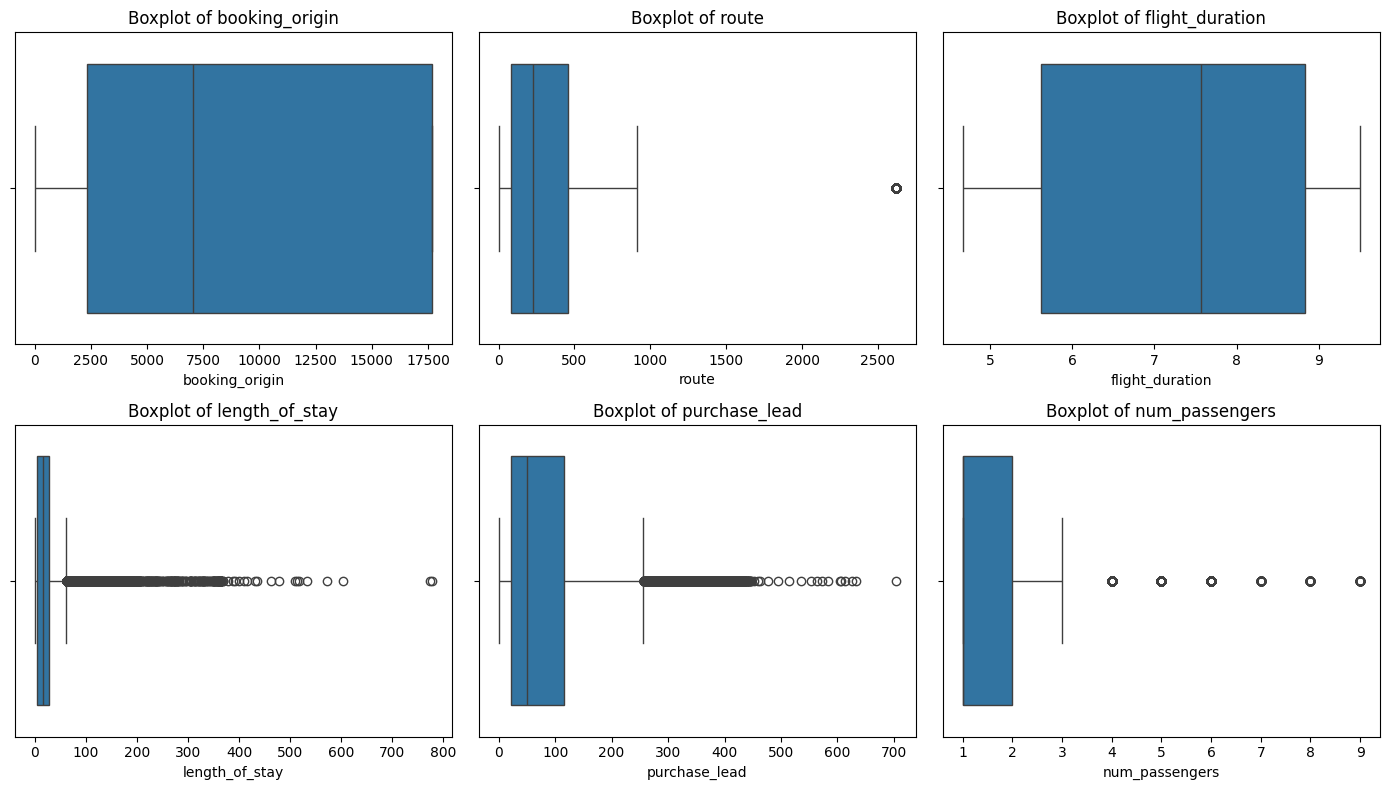

In [175]:
# Check the distribution before handling outliers
col_to_handle_outliers = ['booking_origin', 'route', 'flight_duration', 'length_of_stay', 'purchase_lead', 'num_passengers']
plot_dynamic_boxplots_violinplots(df_train_handling_outliers, col_series=col_to_handle_outliers, ncols=3, figsize=(8, 14), orientation='h')

In [176]:
# Detect outliers in dataframe using IQR or Z-Score method
def outlier_detection(df, col_series, method='iqr', threshold=3):
    """
    Function to detect outliers in a dataframe using either the IQR or Z-Score method.
    
    Parameters:
    -----------
    df : pd.DataFrame 
        The dataframe containing the data.
    col_series : list of str
        List of column names to include in the analysis.
    method : str, optional (default='iqr')
        The method to use for outlier detection.
        Valid options are:
        - 'iqr': Interquartile Range method (default)
        - 'zscore': Z-Score method
    threshold : float, optional (default=3)
        For IQR method: multiplier for IQR to determine outlier bounds (default is 1.5)
        For Z-Score method: number of standard deviations to use as the outlier cutoff
    
    Returns:
    --------
    pd.DataFrame
        A summary dataframe containing:
        - Column Name: Name of the analyzed column
        - Outlier Exist: Boolean indicating if outliers were found
        - Lower Limit: Lower bound for outlier detection
        - Upper Limit: Upper bound for outlier detection
        - Outlier Data: Number of outliers detected
        - Non-Outlier Data: Number of non-outliers
        - Outlier Percentage (%): Percentage of data points identified as outliers
    
    Examples:
    --------
    # Using IQR method
    result_iqr = outlier_detection(df, ['column1', 'column2'], method='iqr')
    
    # Using Z-Score method
    result_zscore = outlier_detection(df, ['column1', 'column2'], method='zscore', threshold=3)
    """
    # Input validation
    if method.lower() not in ['iqr', 'zscore']:
        raise ValueError("Method must be either 'iqr' or 'zscore'")
    
    print(f'Amount of Rows: {len(df)}')
    
    # Initialize lists to store results
    outlier = []  # Store the number of outlier rows per column
    no_outlier = []  # Store the number of non-outlier rows per column
    is_outlier = []  # Boolean indicating whether any outliers exist in the column
    low_bound = []  # Lower bound for outliers
    high_bound = []  # Upper bound for outliers
    outlier_percentage = []  # Percentage of outliers for each column

    # Start with all rows marked as True (non-outliers) in the cumulative filter
    filtered_entries = np.array([True] * len(df))

    # Loop through each column
    for col in col_series:
        if method.lower() == 'iqr':
            # IQR method
            Q1 = df[col].quantile(0.25)  # First quartile (25th percentile)
            Q3 = df[col].quantile(0.75)  # Third quartile (75th percentile)
            IQR = Q3 - Q1  # Interquartile range
            lower_bound = Q1 - (IQR * 1.5)  # Lower bound for outliers
            upper_bound = Q3 + (IQR * 1.5)  # Upper bound for outliers

            # Create a filter that identifies non-outliers for the current column
            filter_outlier = ((df[col] >= lower_bound) & (df[col] <= upper_bound))
            
        elif method.lower() == 'zscore':
            # Z-Score method
            
            # Calculate Z-Scores
            z_scores = np.abs(stats.zscore(df[col]))

            # Create a filter that identifies non-outliers
            filter_outlier = (z_scores < threshold)
            
            mean = df[col].mean() # mean of the column
            std = df[col].std() # standard deviation of the column
            lower_bound = mean - (threshold * std) # Lower bound for outliers
            upper_bound = mean + (threshold * std) # Upper bound for outliers

        # Calculate statistics
        outlier_count = len(df[~filter_outlier]) # Count of outliers
        non_outlier_count = len(df[filter_outlier]) # Count of non-outliers
        outlier_pct = round((outlier_count / len(df)) * 100, 2) # Percentage of outliers

        # Store results
        outlier.append(outlier_count)
        no_outlier.append(non_outlier_count)
        is_outlier.append(df[col][~filter_outlier].any()) # Whether any outliers exist
        low_bound.append(lower_bound)
        high_bound.append(upper_bound)
        outlier_percentage.append(outlier_pct)

        # Update cumulative filter
        filtered_entries = filtered_entries & filter_outlier

    # Print summary statistics
    print(f'Amount of Outlier Rows (Across All Columns): {len(df[~filtered_entries])}')
    print(f'Amount of Non-Outlier Rows (Across All Columns): {len(df[filtered_entries])}')
    print(f'Percentage of Outliers: {round(len(df[~filtered_entries]) / len(df) * 100, 2)}%')
    print()

    # Create and return summary dataframe
    check_outliers = pd.DataFrame({
        'Column Name': col_series,
        'Outlier Exist': is_outlier,
        'Lower Limit': low_bound,
        'Upper Limit': high_bound,
        'Outlier Data': outlier,
        'Non-Outlier Data': no_outlier,
        'Outlier Percentage (%)': outlier_percentage
    })

    return check_outliers

In [177]:
# Outliers cheking with IQR method function implementation
outlier_summary = outlier_detection(df_train_handling_outliers, col_series=col_to_handle_outliers, method='iqr')
outlier_summary

Amount of Rows: 34496
Amount of Outlier Rows (Across All Columns): 7833
Amount of Non-Outlier Rows (Across All Columns): 26663
Percentage of Outliers: 22.71%



,Column Name,Outlier Exist,Lower Limit,Upper Limit,Outlier Data,Non-Outlier Data,Outlier Percentage (%)
0,booking_origin,False,-20744.000,40752.000,0,34496,0.00
1,route,True,-481.500,1018.500,1835,32661,5.32
2,flight_duration,False,0.805,13.645,0,34496,0.00
3,length_of_stay,True,-29.500,62.500,2609,31887,7.56
4,purchase_lead,True,-120.000,256.000,2371,32125,6.87
5,num_passengers,True,-0.500,3.500,2014,32482,5.84


Filtering out every single columns will result in throwing out so much of our data, so we will not apply the filtering for the `num_passangers` column.

In [178]:
# Handling the outliers in dataframe based on chosen method using (IQR or Z-Score)
def outlier_handling(df, col_series, method='iqr', threshold=3):
    """
    Function to remove outliers from specific columns of a dataframe using either IQR or Z-Score method.
    
    Parameters:
    df (pd.DataFrame): The dataframe containing the data
    col_series (list): List of column names to remove outliers from
    method (str): Method to use for outlier detection - either 'iqr' or 'zscore'
    threshold (float): Threshold for z-score method (default=3). Only used if method='zscore'
    
    Returns:
    pd.DataFrame: A new dataframe with outliers removed for the specified columns
    
    Raises:
    ValueError: If an invalid method is specified
    """
    print(f'Rows before removing outliers: {len(df)}')
    
    # Validate the method parameter
    if method.lower() not in ['iqr', 'zscore']:
        raise ValueError("Method must be either 'iqr' or 'zscore'")
    
    # Start with all rows marked as True (non-outliers)
    filtered_entries = np.array([True] * len(df))
    
    # Loop through each column
    for col in col_series:
        if method.lower() == 'iqr':
            # IQR method
            Q1 = df[col].quantile(0.25)  # First quartile (25th percentile)
            Q3 = df[col].quantile(0.75)  # Third quartile (75th percentile)
            IQR = Q3 - Q1  # Interquartile range
            lower_bound = Q1 - (IQR * 1.5)  # Lower bound for outliers
            upper_bound = Q3 + (IQR * 1.5)  # Upper bound for outliers

            # Create a filter that identifies non-outliers for the current column
            filter_outlier = ((df[col] >= lower_bound) & (df[col] <= upper_bound))
            
        elif method.lower() == 'zscore':  # zscore method
            # Calculate Z-Scores
            z_scores = np.abs(stats.zscore(df[col]))

            # Create a filter that identifies non-outliers
            filter_outlier = (z_scores < threshold)
        
        # Update the filter to exclude rows that have outliers in the current column
        filtered_entries = filtered_entries & filter_outlier
    
    # Create a new dataframe by applying the cumulative filter
    df_filtered_outliers = df[filtered_entries]
    
    print(f'Rows after removing outliers: {len(df_filtered_outliers)}')
    
    return df_filtered_outliers

In [179]:
# Outliers handling with IQR method function implementation
columns_to_filter = ['route', 'length_of_stay', 'purchase_lead']
df_train_handling_outliers = outlier_handling(df_train_handling_outliers, col_series=columns_to_filter, method='iqr')
df_train_handling_outliers

Rows before removing outliers: 34496
Rows after removing outliers: 28222


,booking_origin,route,flight_duration,length_of_stay,sales_channel,purchase_lead,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,num_passengers,trip_type_OneWay,trip_type_RoundTrip,booking_complete
48771,17691,143,5.62,6,0,50,1,1,1,1,0,1,0
11527,17691,106,8.83,31,0,28,1,1,1,1,0,1,0
16183,7055,97,6.42,28,0,131,1,0,0,1,0,1,0
4519,3284,12,4.83,30,0,9,1,0,0,1,0,1,0
4679,17691,456,8.83,29,0,5,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37571,3819,337,7.00,5,0,218,0,0,0,2,0,1,0
29299,7055,32,4.67,3,0,56,0,0,1,1,0,1,0
13262,17691,142,5.62,29,0,61,1,0,1,1,0,1,0
26571,3819,91,7.00,3,0,40,1,0,0,2,0,1,0


In [180]:
# Split the features and target for train set again
X_train = df_train_handling_outliers.drop(columns='booking_complete')
y_train = df_train_handling_outliers['booking_complete']

## Feature Scaling

**Additional Reminder About Feature Scalling**

When the original distribution is right-skewed, meaning that the majority of the data is concentrated on the left side with a long tail to the right, it's often more appropriate to use transformations that are less sensitive to extreme values. In this case, Min-Max scaling may be a better choice than Z-score normalization.

Here's a brief explanation:

1. **Min-Max Scaling:**
   - Scales the data to a specific range (e.g., between 0 and 1).
   - Less affected by outliers compared to Z-score normalization.
   - Suitable when the distribution is not normal and skewed.

2. **Z-score Normalization (Standardization):**
   - Centers the data around the mean and scales it by the standard deviation.
   - Can be sensitive to outliers, and right-skewed distributions may have extreme values that influence the scaling.
   - More appropriate when the data is approximately normally distributed.

Given a right-skewed distribution, Min-Max scaling is often a better choice as it allows the preservation of the skewed shape of the distribution and avoids amplifying the impact of outliers. However, the choice may also depend on the specific characteristics of your data and the requirements of your modeling task. If your data has extreme outliers, you might also consider other robust scaling methods.

In [181]:
# See how many subplot shoud be made
len(X_train.columns)

12

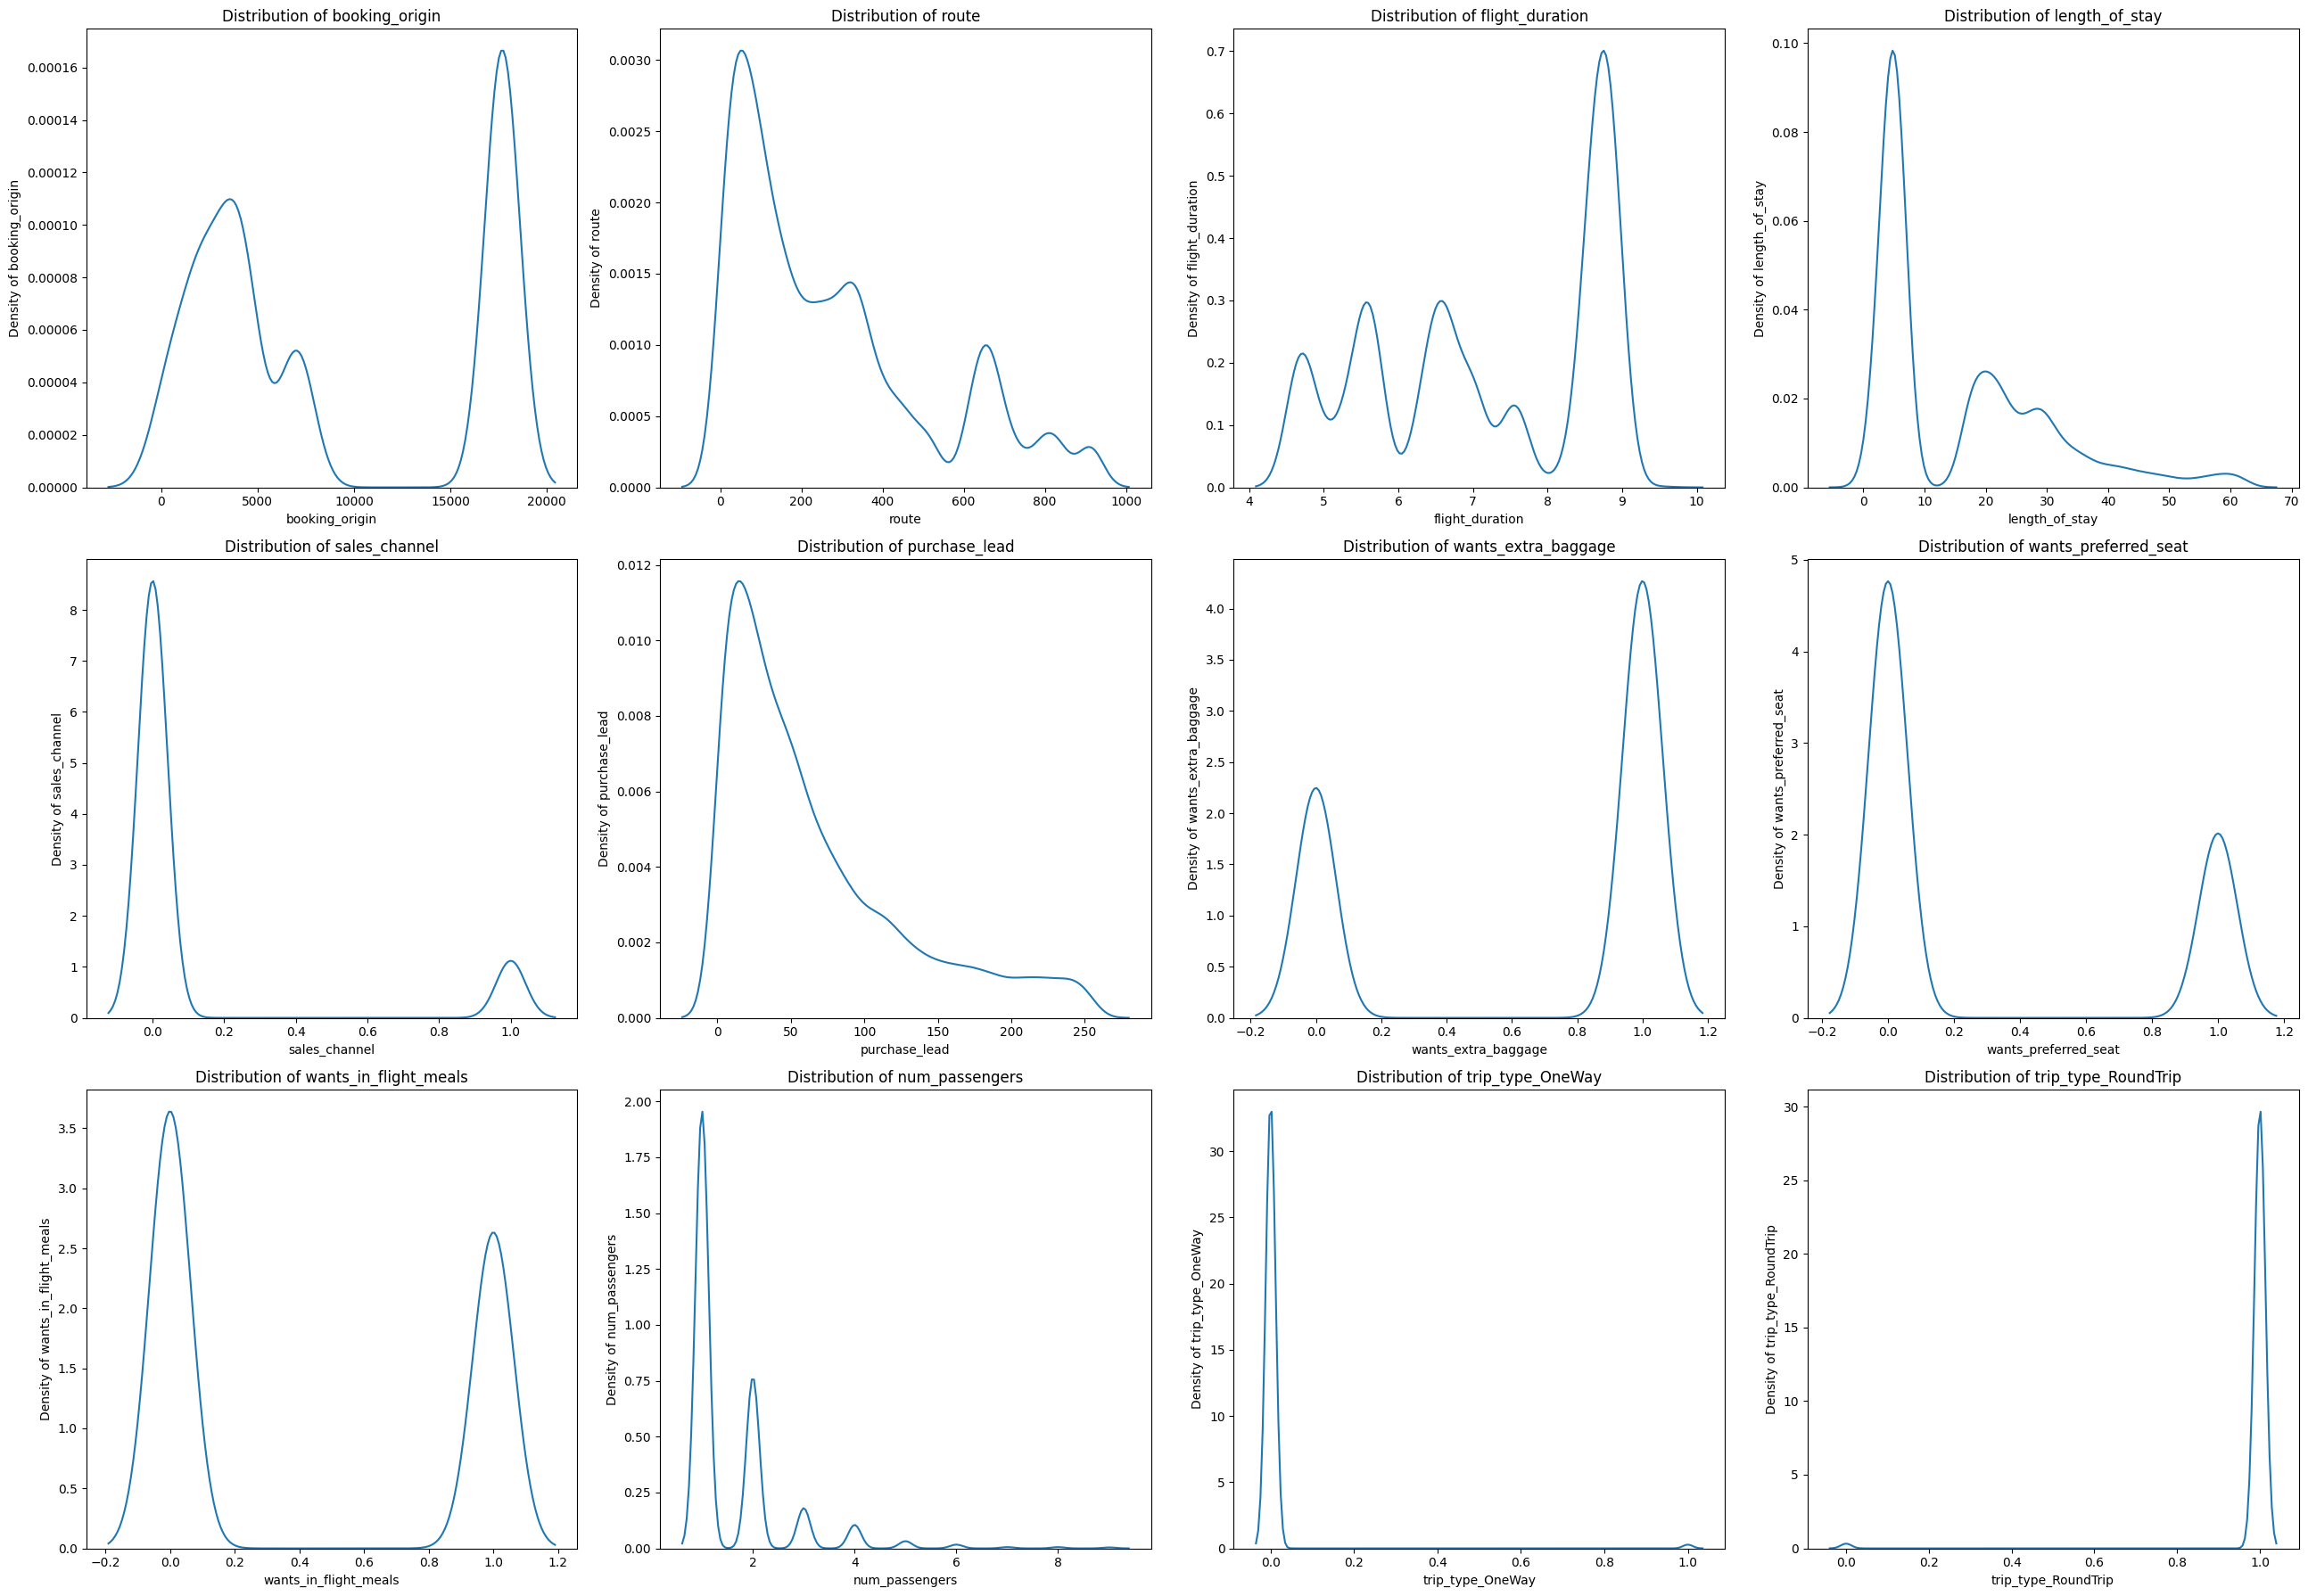

In [183]:
# Kdeplot before scaling
plot_dynamic_hisplots_kdeplots(df=X_train, col_series=X_train.columns, ncols=4, plot_type='kdeplot')

In [187]:
# Normalization (MinMaxScaller)
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()

columns_to_scale = ['purchase_lead', 'route', 'length_of_stay', 'booking_origin', 'flight_duration', 'num_passengers']
X_train[columns_to_scale] = ms.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = ms.transform(X_test[columns_to_scale])

# Save the scaler using joblib
joblib.dump(ms, 'minmax_scaler.joblib')

['minmax_scaler.joblib']

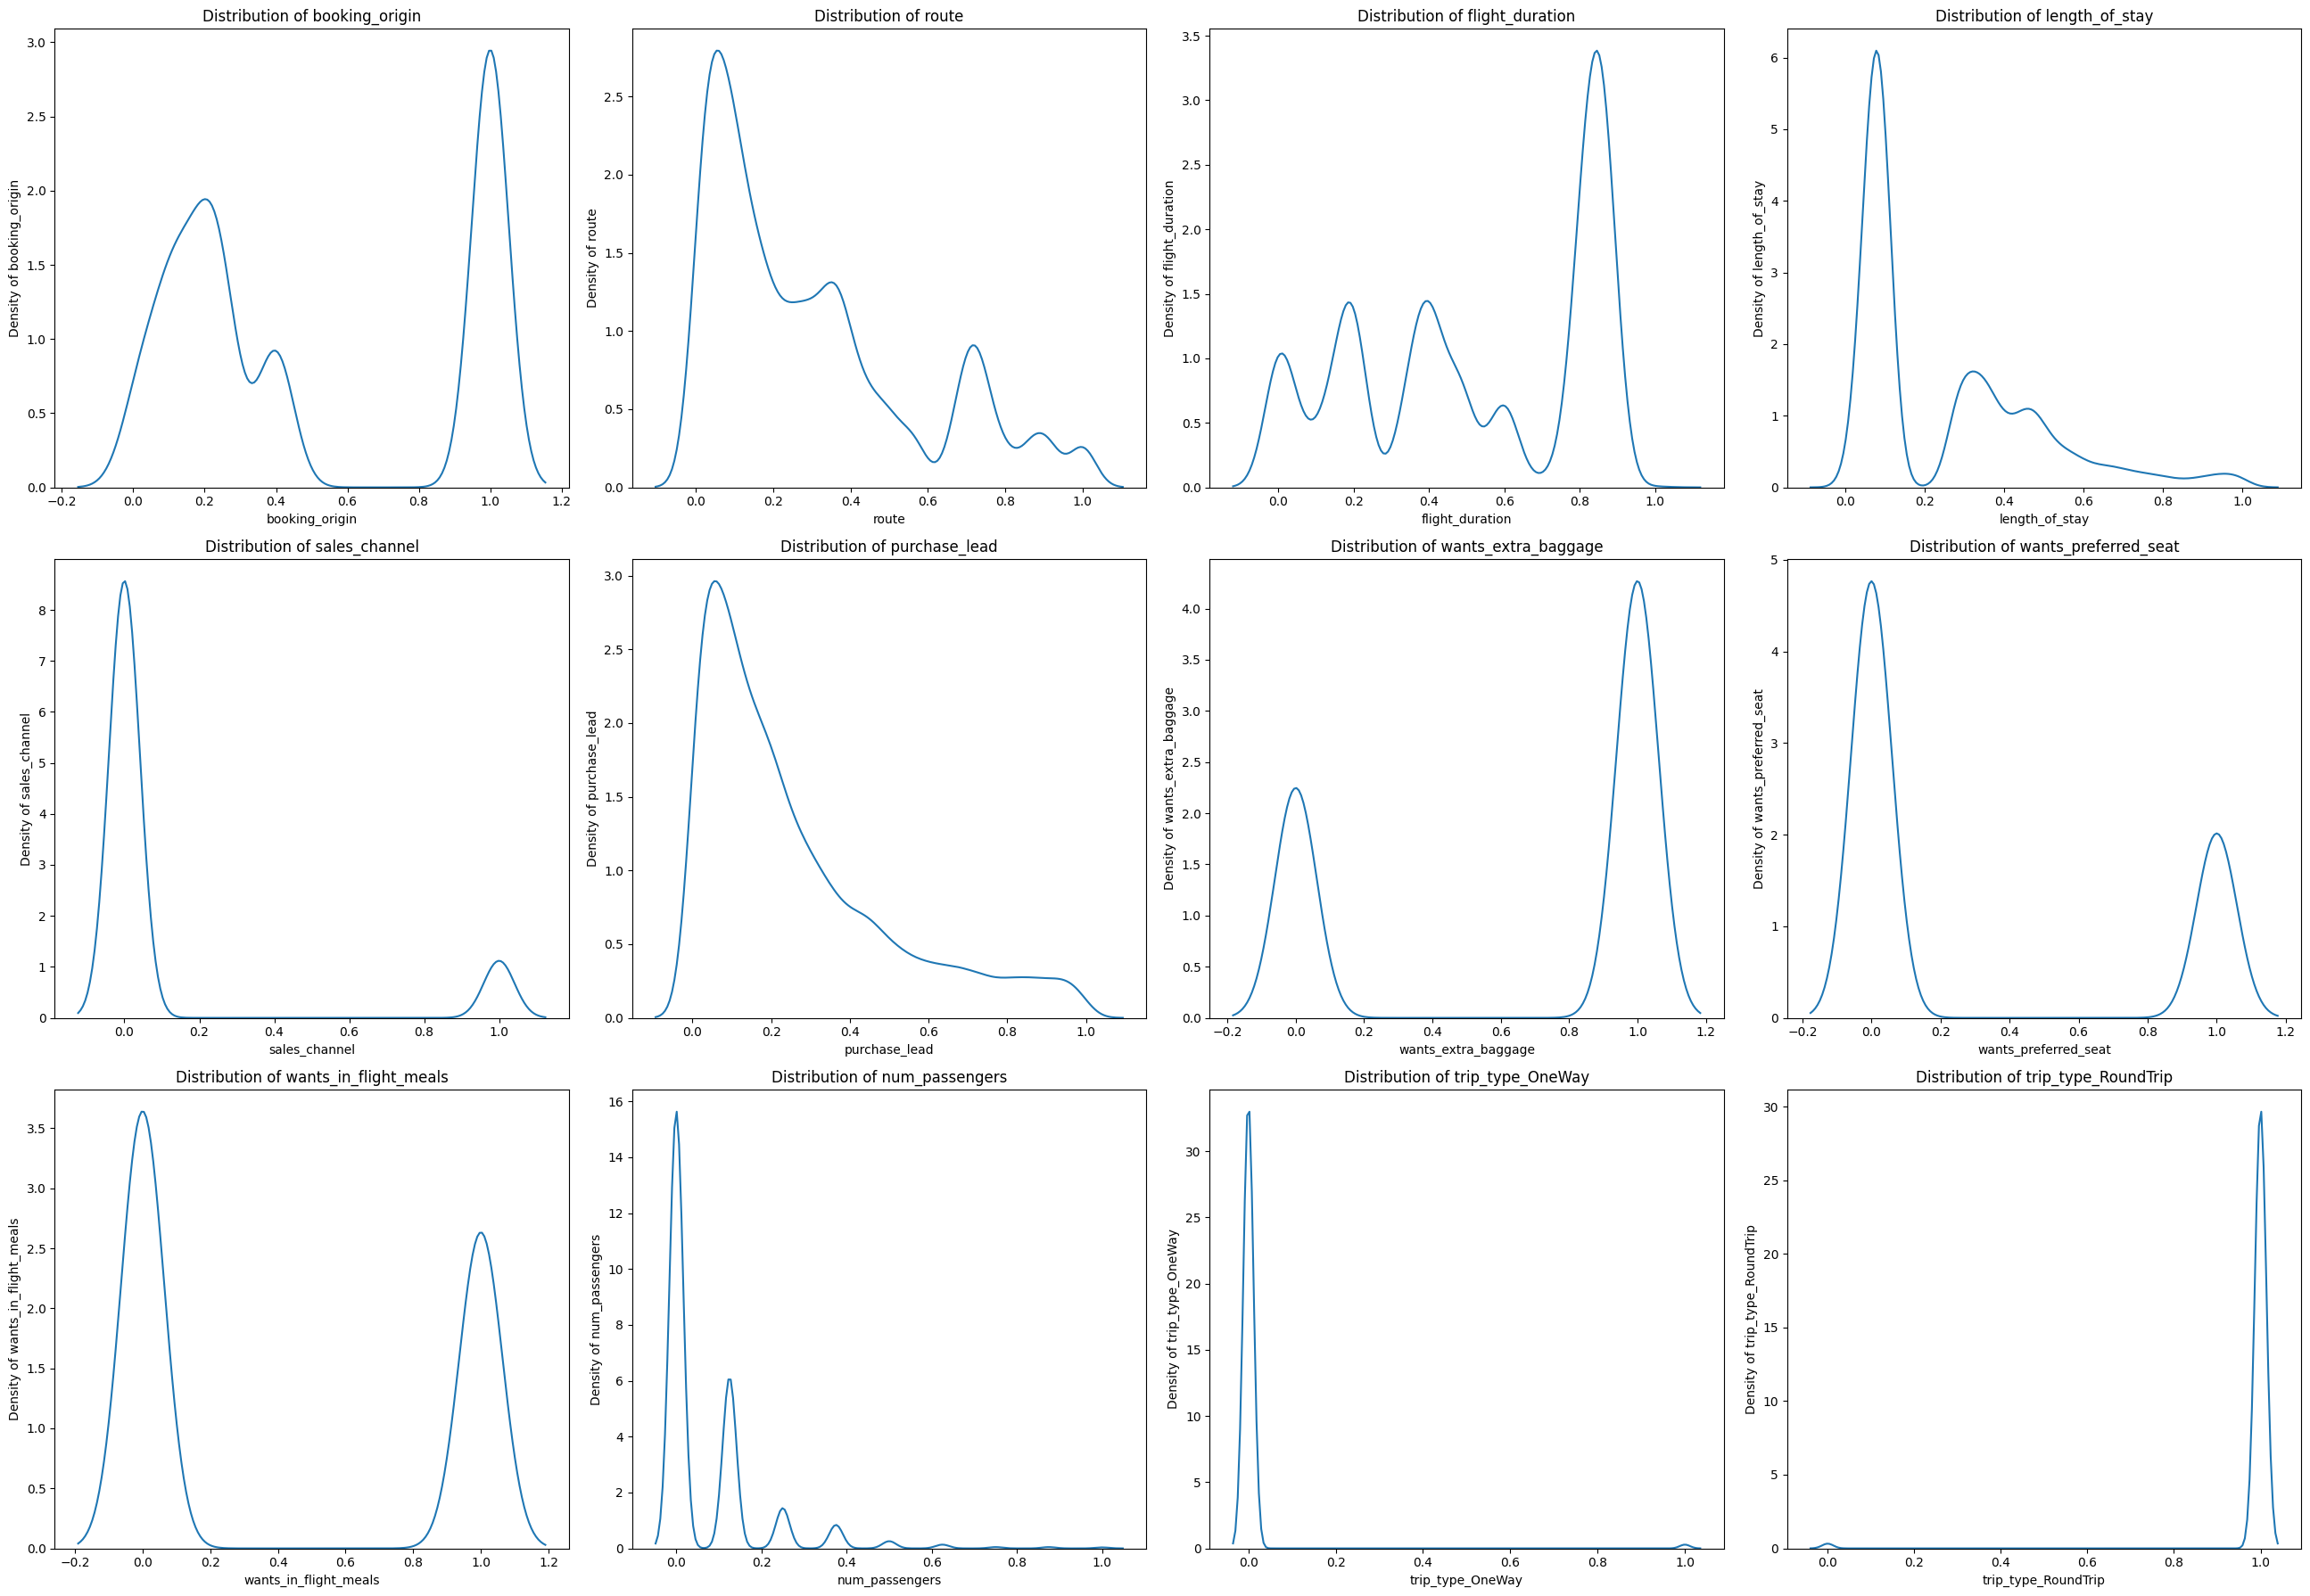

In [188]:
# Checking distribution after scaling
plot_dynamic_hisplots_kdeplots(df=X_train, col_series=X_train.columns, ncols=4, plot_type='kdeplot')

## Handling Class Imbalance

In [189]:
#Initiate dataframe before sampling
x_imbalance = X_train.copy()
y_imbalance = y_train.copy()

In [190]:
# Target values before sampling
y_imbalance.value_counts()

booking_complete
0    24086
1     4136
Name: count, dtype: int64

In [191]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

def resample_data(X, y, method='smote', sampling_strategy=1):
    """
    Resample data using specified method and sampling strategy
    
    Parameters:
    -----------
    X : DataFrame
        Features dataframe
    y : Series
        Target variable
    method : str, default='smote'
        Resampling method: 'under' for RandomUnderSampler, 
        'over' for RandomOverSampler, 'smote' for SMOTE
    sampling_strategy : float or dict, default=1
        Sampling strategy to use
        
    Returns:
    --------
    X_resampled, y_resampled : tuple of resampled data
    """
    print("Before sampling:")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    
    if method.lower() == 'under':
        resampler = RandomUnderSampler(sampling_strategy=sampling_strategy)
        method_name = "RandomUnderSampler"
    elif method.lower() == 'over':
        resampler = RandomOverSampler(sampling_strategy=sampling_strategy)
        method_name = "RandomOverSampler"
    elif method.lower() == 'smote':
        resampler = SMOTE(sampling_strategy=sampling_strategy)
        method_name = "SMOTE"
    else:
        raise ValueError("Method must be 'under', 'over', or 'smote'")
    
    X_resampled, y_resampled = resampler.fit_resample(X, y)
    
    print(f"After {method_name}:")
    print(f"X_resampled shape: {X_resampled.shape}")
    print(f"y_resampled shape: {y_resampled.shape}")
    
    return X_resampled, y_resampled

# Apply SMOTE resampling (can be changed to 'under' or 'over')
x_train_SMOTE, y_train_SMOTE = resample_data(x_imbalance, y_imbalance, method='smote', sampling_strategy=1)

Before sampling:
X shape: (28222, 12)
y shape: (28222,)
After SMOTE:
X_resampled shape: (48172, 12)
y_resampled shape: (48172,)


In [192]:
# Target values after sampling
y_train_SMOTE.value_counts()

booking_complete
0    24086
1    24086
Name: count, dtype: int64

In [193]:
# Initialize sampled train set for modeling process
X_train_sampled = x_train_SMOTE.copy()
y_train_sampled = y_train_SMOTE.copy()

## Train Classification Models

Initial train are done using default hyperparameters

In [ ]:
# logictic regression
from sklearn.linear_model import LogisticRegression # import logistic regression from sklearn
lg = LogisticRegression() # initiation object called lg
lg.fit(x_train_sampled, y_train_sampled) # fit logistic regression model in train data

LogisticRegression()

In [ ]:
# knn
from sklearn.neighbors import KNeighborsClassifier # import knn from sklearn
knn = KNeighborsClassifier() # initiation object called knn
knn.fit(x_train_sampled, y_train_sampled) # fit knn model in train data

KNeighborsClassifier()

In [ ]:
# decision tree
from sklearn.tree import DecisionTreeClassifier # import decision tree from sklearn
dt = DecisionTreeClassifier() # initiation object called dt
dt.fit(x_train_sampled, y_train_sampled) # fit decision tree model in train data

DecisionTreeClassifier()

In [ ]:
# random forest
from sklearn.ensemble import RandomForestClassifier # import random forest from sklearn
rf = RandomForestClassifier(random_state=42) # initiation object called rf
rf.fit(x_train_sampled, y_train_sampled) # fit random forest model in train data

RandomForestClassifier(random_state=42)

In [ ]:
# Boosting : AdaBoost Classification
from sklearn.ensemble import AdaBoostClassifier # import ADB from sklearn
ab = AdaBoostClassifier() # initiation object called ab
ab.fit(x_train_sampled, y_train_sampled) # fit ADB model in train data

AdaBoostClassifier()

In [ ]:
# xgboost
from xgboost import XGBClassifier # import XGB from sklearn
xg = XGBClassifier() # initiation object called xg
xg.fit(x_train_sampled, y_train_sampled) # fit XGB model in train data

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

## Evaluate Classification Models

The focus is on increasing the number of customers who complete the booking (class 1), evaluating the Recall metric is appropriate. Recall is particularly relevant in scenarios where capturing all positive instances is crucial. Here's a brief explanation of the metrics you mentioned:

1. **Recall (Sensitivity):**
   - **Definition:** Recall is the ratio of true positive predictions to the total actual positives (completed bookings). It is also known as Sensitivity or True Positive Rate.
   - **Importance:** A high recall implies that the model is effective in identifying and capturing a significant portion of customers who eventually complete their bookings.

2. **Precision:**
   - **Definition:** Precision is the ratio of true positive predictions to the total predicted positives (both true positives and false positives).
   - **Importance:** Precision focuses on the accuracy of positive predictions. In the context of booking completion, it tells you how many of the predicted completed bookings are actually correct.

3. **Accuracy:**
   - **Definition:** Accuracy is the ratio of correctly predicted instances (both true positives and true negatives) to the total instances.
   - **Importance:** Accuracy provides an overall measure of model performance but might not be the best metric when dealing with imbalanced datasets (where one class significantly outnumbers the other). In cases where the classes are imbalanced, accuracy might be misleading, and other metrics like precision or recall may be more informative.

Given your specific goal of increasing the number of completed bookings, focusing on Recall is appropriate. A high Recall indicates that your model is effectively capturing a larger proportion of customers who complete their bookings, which aligns with your objective. However, it's also advisable to consider Precision in conjunction with Recall to have a more comprehensive understanding of your model's performance, especially if there are implications or costs associated with false positives.

In [ ]:
#Import metrics score that will be evalueated
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate

#Function for model evaluation metrics score
def eval_classification(model):
    y_pred = model.predict(x_test)
    y_pred_train = model.predict(x_train_sampled)
    y_pred_proba = model.predict_proba(x_test)
    y_pred_proba_train = model.predict_proba(x_train_sampled)

    print("Accuracy (Test Set): %.2f" % accuracy_score(y_test, y_pred))
    print("Precision (Test Set): %.2f" % precision_score(y_test, y_pred))
    print("Recall (Test Set): %.2f" % recall_score(y_test, y_pred))
    print("F1-Score (Test Set): %.2f" % f1_score(y_test, y_pred))

    print("roc_auc (Train-Proba): %.2f" % roc_auc_score(y_train_sampled, y_pred_proba_train[:, 1]))
    print("roc_auc (Test-Proba): %.2f" % roc_auc_score(y_test, y_pred_proba[:, 1]))

    #Cross Validation
    score = cross_validate(model, x_train_sampled, y_train_sampled, cv=5, scoring='recall', return_train_score=True) #scoring change based on what metrics we want to validate (usually choose the main performance metric)
    print('Recall (crossval train): '+ str(score['train_score'].mean()))
    print('Recall (crossval test): '+ str(score['test_score'].mean()))

    # Print standard deviation of recall scores
    print('Recall Std Dev (crossval train): ' + str(score['train_score'].std()))
    print('Recall Std Dev (crossval test): ' + str(score['test_score'].std()))

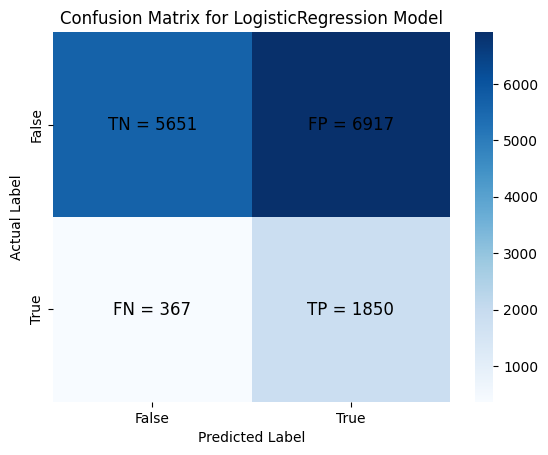

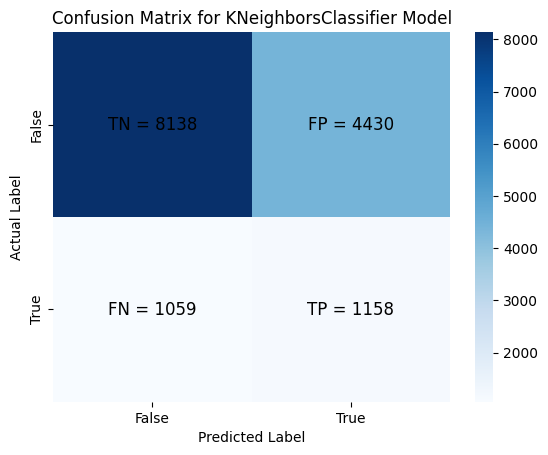

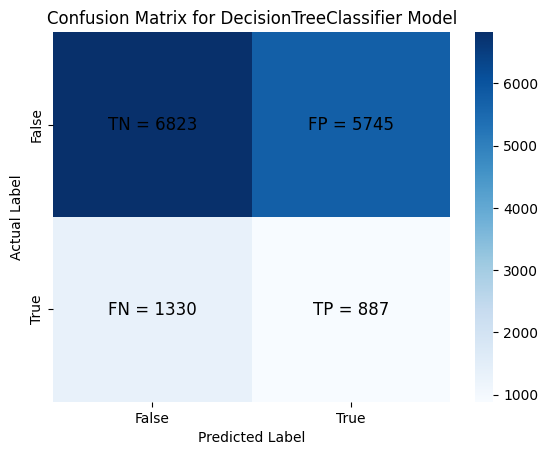

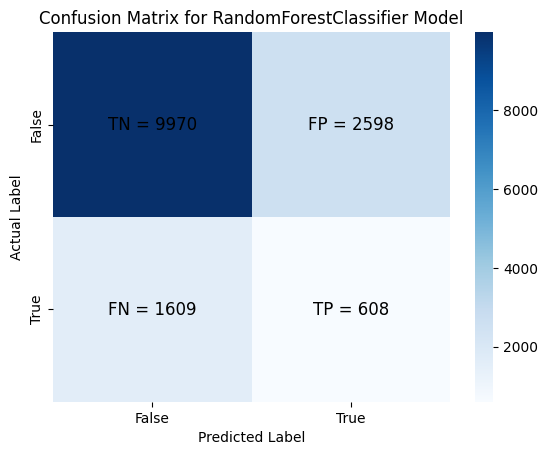

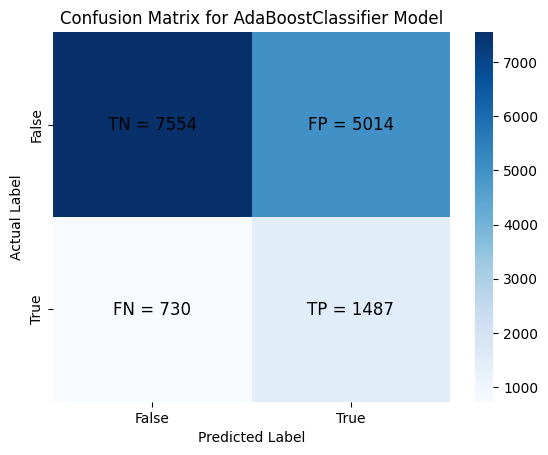

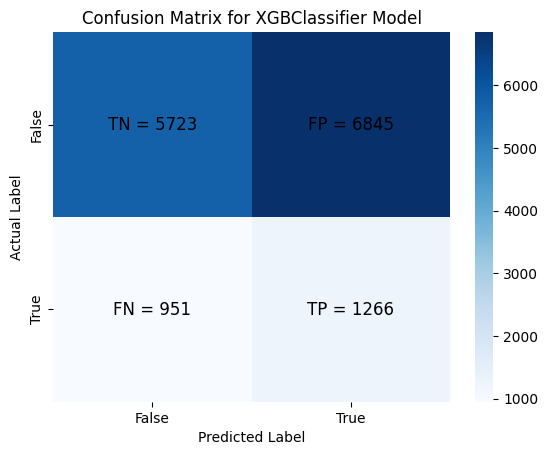

In [ ]:
#Confusion matrix of all models

from sklearn.metrics import confusion_matrix

# Instantiate models
models = [
    LogisticRegression(),
    KNeighborsClassifier(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    AdaBoostClassifier(),
    XGBClassifier()
]

for model in models :

    model.fit(x_train_sampled, y_train_sampled)

    y_pred = model.predict(x_test)

    #Make confusion matrix
    conf_mat = confusion_matrix(y_test, y_pred)

    #Plot the confusion matrix in heatmap
    sns.heatmap(conf_mat, fmt='d', cmap='Blues', xticklabels=['False', 'True'], yticklabels=['False', 'True'])

    # Add annotations for TN, FN, FP, TP
    for i in range(2):
        for j in range(2):
            if i == 0 and j == 0:
                text = f'TN = {conf_mat[i, j]}'
            elif i == 1 and j == 0:
                text = f'FN = {conf_mat[i, j]}'
            elif i == 0 and j == 1:
                text = f'FP = {conf_mat[i, j]}'
            elif i == 1 and j == 1:
                text = f'TP = {conf_mat[i, j]}'

            plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black', fontsize=12)

    plt.title(f'Confusion Matrix for {type(model).__name__} Model')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

**Additional Information About confusion_matrix**

Documentation : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

The `confusion_matrix` function from scikit-learn is used to compute the confusion matrix, which is a table that summarizes the performance of a classification algorithm. The confusion matrix is typically a 2x2 matrix for binary classification problems.

Here's the breakdown:

```python
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are your true labels and predicted labels, respectively
conf_mat = confusion_matrix(y_test, y_pred)
```

The confusion matrix `conf_mat` will be a 2x2 matrix in the form:

```
[[True Negative  False Positive]
 [False Negative True Positive]]
```

- True Negative (TN): The instances that are actually negative (class 0) and are predicted correctly as negative.
- False Positive (FP): The instances that are actually negative (class 0) but are predicted incorrectly as positive.
- False Negative (FN): The instances that are actually positive (class 1) but are predicted incorrectly as negative.
- True Positive (TP): The instances that are actually positive (class 1) and are predicted correctly as positive.

So, in the confusion matrix `conf_mat`, the elements are arranged as follows:

- `conf_mat[0, 0]`: True Negatives (TN)
- `conf_mat[0, 1]`: False Positives (FP)
- `conf_mat[1, 0]`: False Negatives (FN)
- `conf_mat[1, 1]`: True Positives (TP)

These values help evaluate the performance of your binary classification model. The diagonal elements (`conf_mat[0, 0]` and `conf_mat[1, 1]`) represent correct predictions, while the off-diagonal elements represent errors in predictions.

In [ ]:
#Printing metrics in form of classification report
from sklearn.metrics import classification_report

def display_classification_reports(model_for_report):
    model_for_report.fit(x_train_sampled, y_train_sampled)
    y_pred = model_for_report.predict(x_test)
    print("Classification Report for", type(model_for_report).__name__)
    print(classification_report(y_test, y_pred))

# Instantiate models
models = [
    LogisticRegression(),
    KNeighborsClassifier(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    AdaBoostClassifier(),
    XGBClassifier()
]

# Evaluate and print classification reports for all models
for model in models:
    display_classification_reports(model)

Classification Report for LogisticRegression
              precision    recall  f1-score   support

           0       0.94      0.45      0.61     12568
           1       0.21      0.83      0.34      2217

    accuracy                           0.51     14785
   macro avg       0.58      0.64      0.47     14785
weighted avg       0.83      0.51      0.57     14785

Classification Report for KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.88      0.65      0.75     12568
           1       0.21      0.52      0.30      2217

    accuracy                           0.63     14785
   macro avg       0.55      0.58      0.52     14785
weighted avg       0.78      0.63      0.68     14785

Classification Report for DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.83      0.54      0.66     12568
           1       0.13      0.39      0.20      2217

    accuracy                           0.

**Additional Information About Classification_Report**

1. `from sklearn.metrics import classification_report`: This line imports the `classification_report` function from scikit-learn's `metrics` module. This function is used to generate a text report that includes precision, recall, f1-score, and support for each class.

2. `print(classification_report(y_test, y_pred))`: This line prints the classification report based on the true labels (`y_test`) and the predicted labels (`y_pred`). `y_test` typically represents the actual class labels in your test set, and `y_pred` represents the predicted labels generated by your machine learning model.

Now, regarding the interpretation of the classification report:
- Precision: Precision is the ratio of correctly predicted positive observations to the total predicted positives. For class 0 and class 1, precision will be separately calculated.
- Recall: Recall is the ratio of correctly predicted positive observations to the all observations in the actual class. It is also calculated separately for class 0 and class 1.
- F1-score: The F1-score is the weighted average of precision and recall. It is a good way to show a balance between precision and recall.
- Support: Support is the number of actual occurrences of the class in the specified dataset.

The classification report will include these metrics for each class in your classification problem. The classes are typically denoted as 0 and 1 in binary classification problems. Class 0 usually represents the negative class (e.g., non-event or absence of a condition), and Class 1 represents the positive class (e.g., event or presence of a condition).

In the report, you will see values for precision, recall, f1-score, and support for both Class 0 and Class 1. The interpretation of these metrics depends on the context of your specific classification problem. Generally, you would want high values for precision, recall, and f1-score, indicating good performance of your model.

In [ ]:
#Printing metrics score for all models to compare

#Logistic Regression
print('Evaluate LogisticRegression')
eval_classification(lg)

#K-Neareest Neighbors Classifier
print('\nEvaluate KNeighborsClassifier')
eval_classification(knn)

#Decision Tree Classifier
print('\nEvaluate DecisionTreeClassifier')
eval_classification(dt)

#Random Forest Classifier
print('\nEvaluate RandomForestClassifier')
eval_classification(rf)

#AdaBoost Classifier
print('\nEvaluate AdaBoostClassifier')
eval_classification(ab)

#XGBoost Classifier
print('\nEvaluate XGBoostClassifier')
eval_classification(xg)

Evaluate LogisticRegression
Accuracy (Test Set): 0.51
Precision (Test Set): 0.21
Recall (Test Set): 0.83
F1-Score (Test Set): 0.34
roc_auc (Train-Proba): 0.69
roc_auc (Test-Proba): 0.68
Recall (crossval train): 0.714419353904573
Recall (crossval test): 0.7140015402494095
Recall Std Dev (crossval train): 0.001632779416215143
Recall Std Dev (crossval test): 0.008651064016875426

Evaluate KNeighborsClassifier
Accuracy (Test Set): 0.63
Precision (Test Set): 0.21
Recall (Test Set): 0.52
F1-Score (Test Set): 0.30
roc_auc (Train-Proba): 0.95
roc_auc (Test-Proba): 0.62
Recall (crossval train): 0.9282317089741581
Recall (crossval test): 0.8827907656306608
Recall Std Dev (crossval train): 0.0012367601744184553
Recall Std Dev (crossval test): 0.006013156697858162

Evaluate DecisionTreeClassifier
Accuracy (Test Set): 0.51
Precision (Test Set): 0.13
Recall (Test Set): 0.40
F1-Score (Test Set): 0.20
roc_auc (Train-Proba): 1.00
roc_auc (Test-Proba): 0.47
Recall (crossval train): 0.9895924278908923
Re

The tree best models for this case is decision tree, random forest, and xgboost classifier, for further improvement we can do hyperparameter tuning but only on the best model and that is random forest

## Feature Importances from Classification Models

**Additional Information About feature_importances_**

This code defines a function called `show_feature_importance` that takes a machine learning model as input, extracts the feature importances from the model, and then plots a horizontal bar chart to visualize the importance scores of the top 25 features.

Here's a breakdown of the code:

1. `model`: The input to the function is expected to be a trained machine learning model, likely a tree-based model such as a decision tree, random forest, or gradient boosting model.

2. `feat_importances = pd.Series(model.feature_importances_, index=x.columns)`: This line creates a Pandas Series object (`feat_importances`) where the feature importances from the model are stored. The index of the series is set to the column names of the features (`x.columns`).

3. `ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))`: The top 25 features with the highest importance scores are selected using `nlargest(25)`, and a horizontal bar chart (`barh`) is created using Matplotlib. The `ax` variable holds the axes of the plot.

4. `ax.invert_yaxis()`: This inverts the y-axis of the plot, displaying the features with the highest importance at the top.

5. `plt.xlabel('score')`: Sets the x-axis label of the plot to 'score'.

6. `plt.ylabel('feature')`: Sets the y-axis label of the plot to 'feature'.

7. `plt.title('feature importance score')`: Sets the title of the plot to 'feature importance score'.

In machine learning models, feature importance refers to a score assigned to each feature indicating its contribution to the predictive performance of the model. Higher feature importance suggests that the feature has a greater impact on the model's predictions. Feature importance is often used for interpretability, helping to identify which features are the most influential in making predictions.

For tree-based models, feature importance is typically calculated based on metrics such as information gain, Gini impurity, or mean decrease in impurity. It helps in understanding the relative contribution of different features in making decisions within the model.

In [ ]:
#Function for model feature importance score
def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=x.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('Score')
    plt.ylabel('Feature')
    plt.title('Feature importance score')

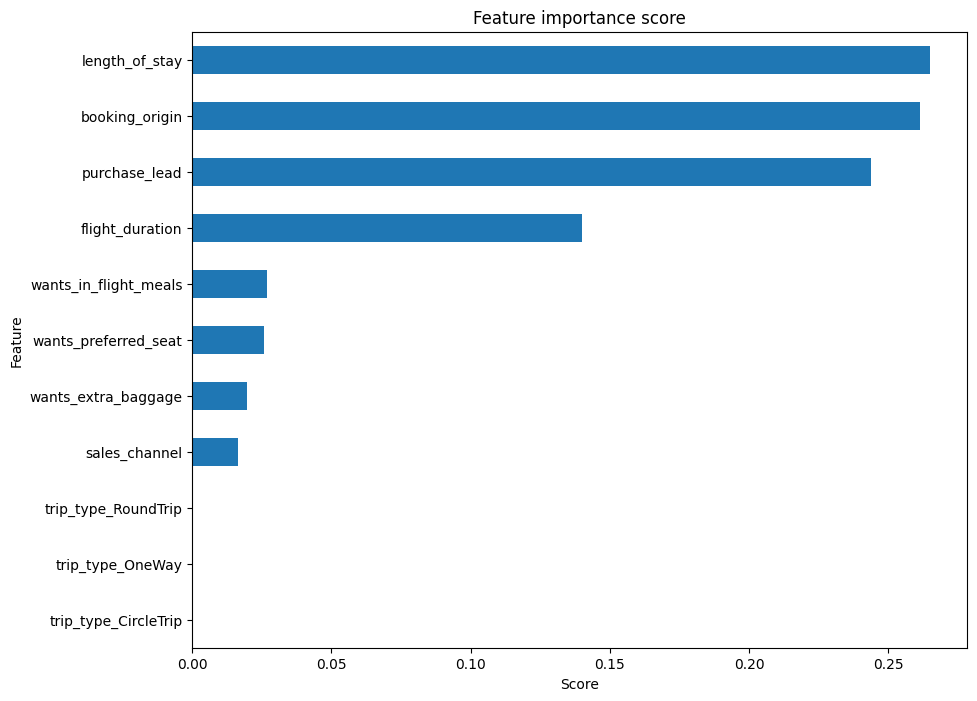

In [ ]:
# Feature importance in random forest
show_feature_importance(dt)

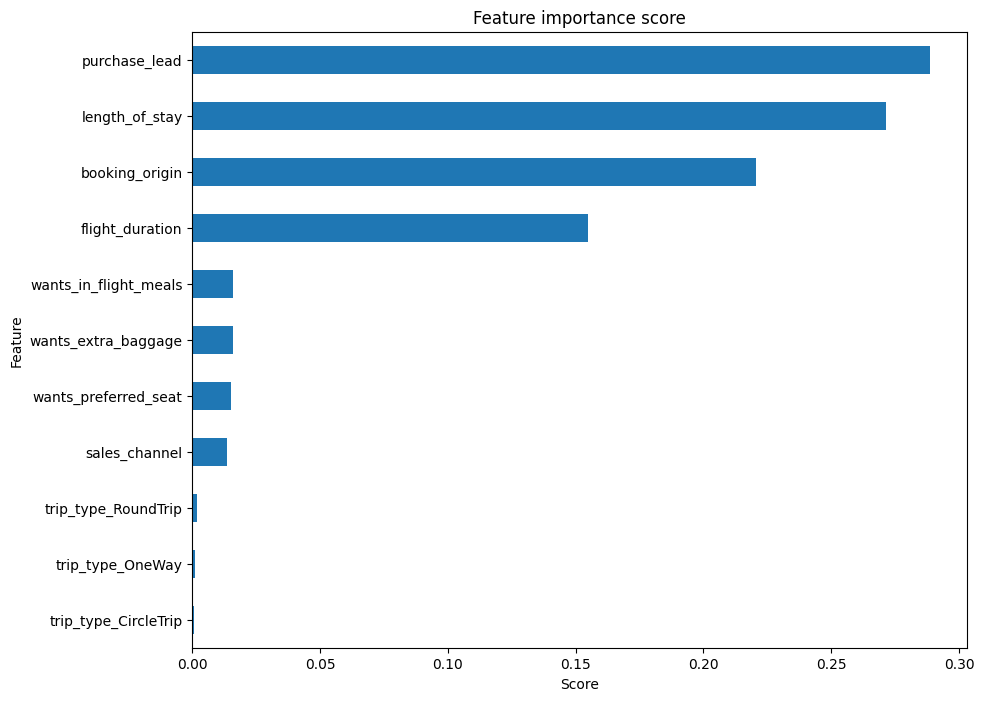

In [ ]:
# Feature importance in random forest
show_feature_importance(rf)

In decision tree and random forest model, feature purchase_lead, length_of_stay, booking_origin, and flight_duration are important to the predictive performance of the model.

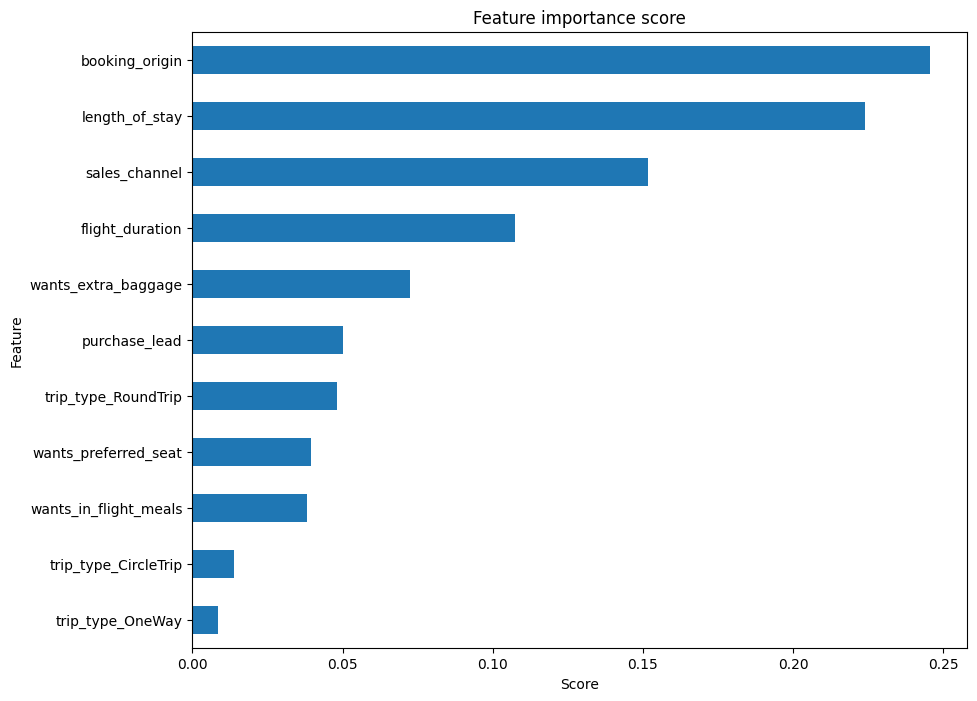

In [ ]:
# Feature importance in XGB
show_feature_importance(xg)

In xgb model, the purchase lead feature does not have the same importance as both dt and rf model. sales channel have high importance in this model

## Hyperparameter Tuning

**Additional Information About best_estimator_.get_params()**

This code defines a function called `show_best_hyperparameter` that takes a model trained with hyperparameter tuning (using techniques like grid search or randomized search) as input and prints the best hyperparameters found during the tuning process.

Here's an explanation of the code:

1. `model`: The input to the function is expected to be an object that resulted from hyperparameter tuning. This could be, for example, a `GridSearchCV` or `RandomizedSearchCV` object from the scikit-learn library.

2. `model.best_estimator_`: This attribute of the model object holds the best estimator (model) found during the hyperparameter tuning process. It encapsulates both the best hyperparameters and the trained model.

3. `model.best_estimator_.get_params()`: This method retrieves the hyperparameters of the best estimator and prints them. It returns a dictionary where keys are the hyperparameter names, and values are their corresponding values.

So, when you call `show_best_hyperparameter(model)`, it will print the hyperparameters of the best estimator obtained through hyperparameter tuning.

For example, if you have a grid search with various combinations of hyperparameters and you call `grid_search.best_estimator_.get_params()`, it will provide you with the hyperparameters that yielded the best performance on the validation set according to the specified scoring metric.

In [ ]:
#Function for best hyperparameters found during the tuning process
def show_best_hyperparameter(model):
    print(model.best_estimator_.get_params())

### Hyperparameter Tuning For Random Forest

Param value: 1; train: 0.9268088832285282; test: 0.4370771312584574; difference: 0.4897317519700708
Param value: 6; train: 0.9658123059778715; test: 0.2774018944519621; difference: 0.6884104115259093
Param value: 12; train: 0.9829658521053889; test: 0.2832656743346865; difference: 0.6997001777707024
Param value: 18; train: 0.986189604393855; test: 0.2918358141632837; difference: 0.6943537902305712
Param value: 24; train: 0.9893337578603837; test: 0.29995489400090214; difference: 0.6893788638594815
Param value: 30; train: 0.9912839289978508; test: 0.2724402345511953; difference: 0.7188436944466554
Param value: 36; train: 0.9918809201623816; test: 0.2769508344609833; difference: 0.7149300857013983
Param value: 41; train: 0.9924381119159437; test: 0.2868741542625169; difference: 0.7055639576534267
Param value: 47; train: 0.9919207195733503; test: 0.2814614343707713; difference: 0.710459285202579
Param value: 53; train: 0.9923187136830375; test: 0.2855209742895805; difference: 0.7067977393

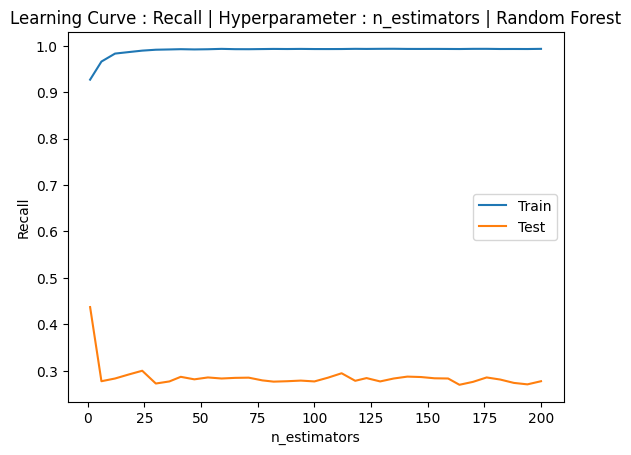

In [ ]:
#Learning curve for hyperparameters (n_estimators)

# Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
param_values = [int(x) for x in np.linspace(1, 200, num = 35)] # n_estimators
# param_values = [int(x) for x in np.linspace(1, 100, num = 15)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 150, num = 15)] # min_samples_split
# param_values = [int(x) for x in np.linspace(1, 150, num = 15)] # min_samples_leaf

train_scores = []
test_scores = []
difference_scores = []

for i in param_values:
    model = RandomForestClassifier(n_estimators=i) # Change based on what hyperparameter that we used
    model.fit(x_train_sampled, y_train_sampled)

    # eval on train
    y_pred_train = model.predict(x_train_sampled)
    train_recall = recall_score(y_train_sampled, y_pred_train)
    train_scores.append(train_recall)

    # eval on test
    y_pred_test = model.predict(x_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_scores.append(test_recall)

    # difference eval on train and test
    diff_score = train_recall - test_recall
    difference_scores.append(diff_score)

    print('Param value: ' + str(i) + '; train: ' + str(train_recall) + '; test: '+ str(test_recall) + '; difference: '+ str(diff_score))

plt.title('Learning Curve : Recall | Hyperparameter : n_estimators | Random Forest') # Change based on what hyperparameter that we used
plt.ylabel('Recall')
plt.xlabel('n_estimators') # Change based on what hyperparameter that we used
plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

Param value: 1; train: 0.9319290522641632; test: 0.5256100902206118; difference: 0.40631896204355145
Param value: 6; train: 0.9978955043734716; test: 0.574489661222651; difference: 0.42340584315082064
Param value: 12; train: 0.999335564784688; test: 0.594486767806318; difference: 0.40484879697836995
Param value: 18; train: 0.9995785905121132; test: 0.5987684820467499; difference: 0.40081010846536325
Param value: 24; train: 0.9996806970841963; test: 0.5958478434824702; difference: 0.40383285360172605
Param value: 30; train: 0.9997074507278826; test: 0.6027264724553367; difference: 0.39698097827254586
Param value: 36; train: 0.9997535979912534; test: 0.5985037427068824; difference: 0.40124985528437096
Param value: 41; train: 0.9997591974069095; test: 0.5916059845984977; difference: 0.4081532128084119
Param value: 47; train: 0.9997623139133602; test: 0.6058721026717049; difference: 0.39389021124165535
Param value: 53; train: 0.9997837778120441; test: 0.5903599170175947; difference: 0.4094

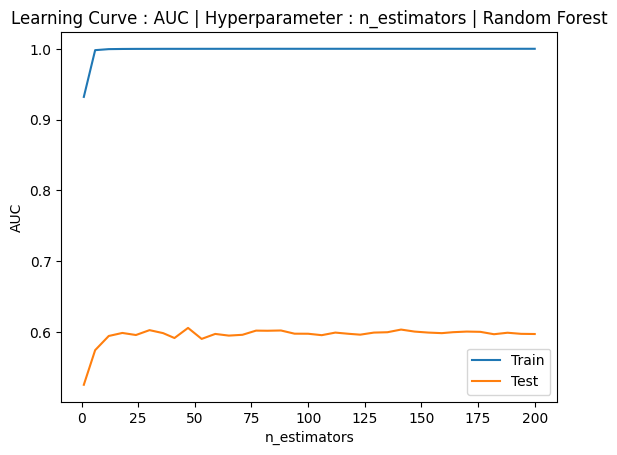

In [ ]:
#Learning curve for hyperparameters (n_estimators)

# Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
param_values = [int(x) for x in np.linspace(1, 200, num = 35)] # n_estimators
# param_values = [int(x) for x in np.linspace(1, 100, num = 15)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 150, num = 15)] # min_samples_split
# param_values = [int(x) for x in np.linspace(1, 150, num = 15)] # min_samples_leaf

train_scores = []
test_scores = []
difference_scores = []

for i in param_values:
    model = RandomForestClassifier(n_estimators=i) # Change based on what hyperparameter that we used
    model.fit(x_train_sampled, y_train_sampled)

    # eval on train
    y_pred_train_proba = model.predict_proba(x_train_sampled)
    train_auc = roc_auc_score(y_train_sampled, y_pred_train_proba[:,1])
    train_scores.append(train_auc)

    # eval on test
    y_pred_proba = model.predict_proba(x_test)
    test_auc = roc_auc_score(y_test, y_pred_proba[:,1])
    test_scores.append(test_auc)

    # difference eval on train and test
    diff_score = train_auc - test_auc
    difference_scores.append(diff_score)

    print('Param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; difference: '+ str(diff_score))

plt.title('Learning Curve : AUC | Hyperparameter : n_estimators | Random Forest') # Change based on what hyperparameter that we used
plt.ylabel('AUC')
plt.xlabel('n_estimators') # Change based on what hyperparameter that we used
plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

Param value: 1; train: 0.79547082703176; test: 0.8565629228687416; difference: -0.06109209583698161
Param value: 8; train: 0.8287033351906392; test: 0.7889039242219216; difference: 0.03979941096871764
Param value: 15; train: 0.8991482926052694; test: 0.5196211096075778; difference: 0.3795271829976916
Param value: 22; train: 0.985194619119637; test: 0.2823635543527289; difference: 0.702831064766908
Param value: 29; train: 0.9924381119159437; test: 0.2679296346414073; difference: 0.7245084772745364
Param value: 36; train: 0.9929953036695057; test: 0.28101037437979254; difference: 0.7119849292897131
Param value: 43; train: 0.9933136989572554; test: 0.2805593143888137; difference: 0.7127543845684416
Param value: 50; train: 0.992955504258537; test: 0.2913847541723049; difference: 0.701570750086232
Param value: 57; train: 0.9927167077927247; test: 0.27604871447902574; difference: 0.716667993313699
Param value: 64; train: 0.9928361060256308; test: 0.2805593143888137; difference: 0.71227679163

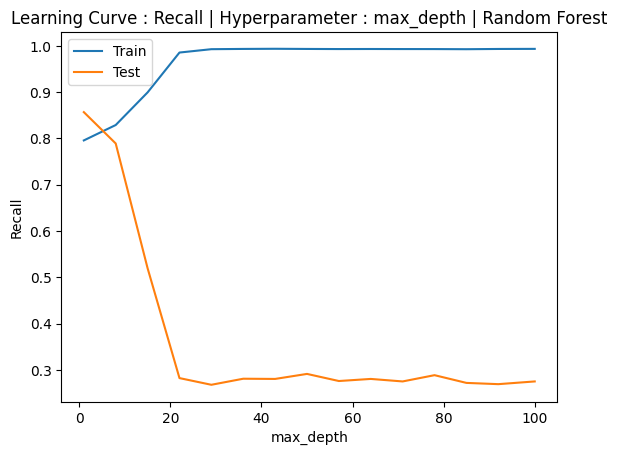

In [ ]:
#Learning curve for hyperparameters (max_depth)

# Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# param_values = [int(x) for x in np.linspace(1, 200, num = 35)] # n_estimators
param_values = [int(x) for x in np.linspace(1, 100, num = 15)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 150, num = 15)] # min_samples_split
# param_values = [int(x) for x in np.linspace(1, 150, num = 15)] # min_samples_leaf

train_scores = []
test_scores = []
difference_scores = []

for i in param_values:
    model = RandomForestClassifier(max_depth=i) # Change based on what hyperparameter that we used
    model.fit(x_train_sampled, y_train_sampled)

    # eval on train
    y_pred_train = model.predict(x_train_sampled)
    train_recall = recall_score(y_train_sampled, y_pred_train)
    train_scores.append(train_recall)

    # eval on test
    y_pred_test = model.predict(x_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_scores.append(test_recall)

    # difference eval on train and test
    diff_score = train_recall - test_recall
    difference_scores.append(diff_score)

    print('Param value: ' + str(i) + '; train: ' + str(train_recall) + '; test: '+ str(test_recall) + '; difference: '+ str(diff_score))

plt.title('Learning Curve : Recall | Hyperparameter : max_depth | Random Forest') # Change based on what hyperparameter that we used
plt.ylabel('Recall')
plt.xlabel('max_depth') # Change based on what hyperparameter that we used
plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

Param value: 1; train: 0.7085139088122663; test: 0.6779022164530951; difference: 0.03061169235917116
Param value: 8; train: 0.8610265117109142; test: 0.7204484644579945; difference: 0.14057804725291967
Param value: 15; train: 0.9703959306101784; test: 0.6508198288096697; difference: 0.31957610180050866
Param value: 22; train: 0.9989028154901018; test: 0.6037087876592743; difference: 0.3951940278308276
Param value: 29; train: 0.9997876688911275; test: 0.59649008715995; difference: 0.40329758173117747
Param value: 36; train: 0.9998218364145811; test: 0.6013909501459558; difference: 0.39843088626862533
Param value: 43; train: 0.9998181963984065; test: 0.6012492940523533; difference: 0.39856890234605324
Param value: 50; train: 0.9998204654685415; test: 0.6029631282144484; difference: 0.3968573372540931
Param value: 57; train: 0.999815606569666; test: 0.5938002005221501; difference: 0.40601540604751585
Param value: 64; train: 0.9998223440843741; test: 0.5983211904595789; difference: 0.40150

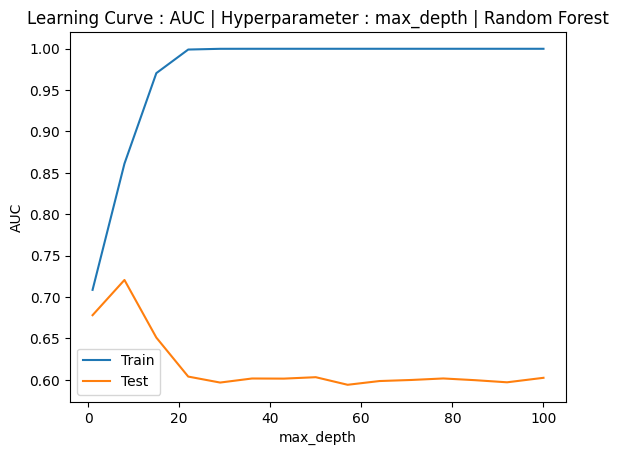

In [ ]:
#Learning curve for hyperparameters (max_depth)

# Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# param_values = [int(x) for x in np.linspace(1, 200, num = 35)] # n_estimators
param_values = [int(x) for x in np.linspace(1, 100, num = 15)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 150, num = 15)] # min_samples_split
# param_values = [int(x) for x in np.linspace(1, 150, num = 15)] # min_samples_leaf

train_scores = []
test_scores = []
difference_scores = []

for i in param_values:
    model = RandomForestClassifier(max_depth=i) # Change based on what hyperparameter that we used
    model.fit(x_train_sampled, y_train_sampled)

    # eval on train
    y_pred_train_proba = model.predict_proba(x_train_sampled)
    train_auc = roc_auc_score(y_train_sampled, y_pred_train_proba[:,1])
    train_scores.append(train_auc)

    # eval on test
    y_pred_proba = model.predict_proba(x_test)
    test_auc = roc_auc_score(y_test, y_pred_proba[:,1])
    test_scores.append(test_auc)

    # difference eval on train and test
    diff_score = train_auc - test_auc
    difference_scores.append(diff_score)

    print('Param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; difference: '+ str(diff_score))

plt.title('Learning Curve : AUC | Hyperparameter : max_depth | Random Forest') # Change based on what hyperparameter that we used
plt.ylabel('AUC')
plt.xlabel('max_depth') # Change based on what hyperparameter that we used
plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

Param value: 2; train: 0.9928759054365995; test: 0.2764997744700045; difference: 0.716376130966595
Param value: 12; train: 0.9309480219692748; test: 0.31393775372124494; difference: 0.6170102682480298
Param value: 23; train: 0.8988696967284884; test: 0.34596301308073973; difference: 0.5529066836477486
Param value: 33; train: 0.8852582981771869; test: 0.40775823184483534; difference: 0.4775000663323516
Param value: 44; train: 0.8691395367348563; test: 0.467298150654037; difference: 0.4018413860808193
Param value: 54; train: 0.8622542386372681; test: 0.4767704104645918; difference: 0.38548382817267635
Param value: 65; train: 0.8541749582106185; test: 0.5029318899413622; difference: 0.35124306826925633
Param value: 76; train: 0.8487622383188729; test: 0.5412719891745602; difference: 0.30749024914431267
Param value: 86; train: 0.8408819549470667; test: 0.584573748308525; difference: 0.2563082066385417
Param value: 97; train: 0.839727772028974; test: 0.5814163283716735; difference: 0.258311

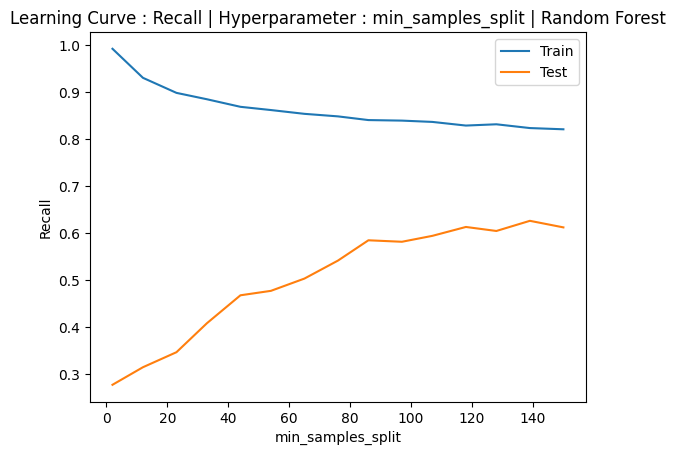

In [ ]:
#Learning curve for hyperparameters (min_samples_split)

# Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# param_values = [int(x) for x in np.linspace(1, 200, num = 35)] # n_estimators
# param_values = [int(x) for x in np.linspace(1, 100, num = 15)] # max_depth
param_values = [int(x) for x in np.linspace(2, 150, num = 15)] # min_samples_split
# param_values = [int(x) for x in np.linspace(1, 150, num = 15)] # min_samples_leaf

train_scores = []
test_scores = []
difference_scores = []

for i in param_values:
    model = RandomForestClassifier(min_samples_split=i) # Change based on what hyperparameter that we used
    model.fit(x_train_sampled, y_train_sampled)

    # eval on train
    y_pred_train = model.predict(x_train_sampled)
    train_recall = recall_score(y_train_sampled, y_pred_train)
    train_scores.append(train_recall)

    # eval on test
    y_pred_test = model.predict(x_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_scores.append(test_recall)

    # difference eval on train and test
    diff_score = train_recall - test_recall
    difference_scores.append(diff_score)

    print('Param value: ' + str(i) + '; train: ' + str(train_recall) + '; test: '+ str(test_recall) + '; difference: '+ str(diff_score))

plt.title('Learning Curve : Recall | Hyperparameter : min_samples_split | Random Forest') # Change based on what hyperparameter that we used
plt.ylabel('Recall')
plt.xlabel('min_samples_split') # Change based on what hyperparameter that we used
plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

Param value: 2; train: 0.9998158861444506; test: 0.6037873140167107; difference: 0.3960285721277399
Param value: 12; train: 0.9898618635403998; test: 0.6187767502835992; difference: 0.3710851132568006
Param value: 23; train: 0.9766140587283442; test: 0.6411291810260795; difference: 0.33548487770226465
Param value: 33; train: 0.9673993165982095; test: 0.6514158287889972; difference: 0.31598348780921237
Param value: 44; train: 0.9584658084853865; test: 0.6608383277245129; difference: 0.29762748076087364
Param value: 54; train: 0.9515251308205656; test: 0.6710426089470664; difference: 0.2804825218734992
Param value: 65; train: 0.9469614153977018; test: 0.6649557754484975; difference: 0.28200563994920436
Param value: 76; train: 0.9410508971581764; test: 0.6752235811923775; difference: 0.2658273159657989
Param value: 86; train: 0.9363912107605542; test: 0.6801501949377344; difference: 0.2562410158228198
Param value: 97; train: 0.932146187624149; test: 0.6829123272599584; difference: 0.24923

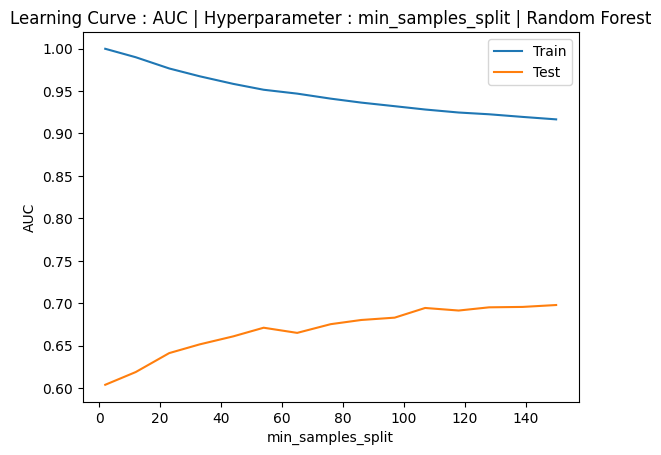

In [ ]:
#Learning curve for hyperparameters (min_samples_split)

# Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# param_values = [int(x) for x in np.linspace(1, 200, num = 35)] # n_estimators
# param_values = [int(x) for x in np.linspace(1, 100, num = 15)] # max_depth
param_values = [int(x) for x in np.linspace(2, 150, num = 15)] # min_samples_split
# param_values = [int(x) for x in np.linspace(1, 150, num = 15)] # min_samples_leaf

train_scores = []
test_scores = []
difference_scores = []

for i in param_values:
    model = RandomForestClassifier(min_samples_split=i) # Change based on what hyperparameter that we used
    model.fit(x_train_sampled, y_train_sampled)

    # eval on train
    y_pred_train_proba = model.predict_proba(x_train_sampled)
    train_auc = roc_auc_score(y_train_sampled, y_pred_train_proba[:,1])
    train_scores.append(train_auc)

    # eval on test
    y_pred_proba = model.predict_proba(x_test)
    test_auc = roc_auc_score(y_test, y_pred_proba[:,1])
    test_scores.append(test_auc)

    # difference eval on train and test
    diff_score = train_auc - test_auc
    difference_scores.append(diff_score)

    print('Param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; difference: '+ str(diff_score))

plt.title('Learning Curve : AUC | Hyperparameter : min_samples_split | Random Forest') # Change based on what hyperparameter that we used
plt.ylabel('AUC')
plt.xlabel('min_samples_split') # Change based on what hyperparameter that we used
plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

Param value: 1; train: 0.9927565072036934; test: 0.2724402345511953; difference: 0.7203162726524981
Param value: 11; train: 0.8544137546764308; test: 0.5818673883626523; difference: 0.2725463663137785
Param value: 22; train: 0.8304545092732628; test: 0.6594497068110059; difference: 0.1710048024622569
Param value: 32; train: 0.8260765740667038; test: 0.6711772665764547; difference: 0.15489930749024905
Param value: 43; train: 0.8159675236806495; test: 0.699594046008119; difference: 0.11637347767253048
Param value: 54; train: 0.8087638302953116; test: 0.7320703653585927; difference: 0.07669346493671891
Param value: 64; train: 0.8100772108572794; test: 0.7582318448353631; difference: 0.05184536602191625
Param value: 75; train: 0.8026347210061291; test: 0.7415426251691475; difference: 0.06109209583698161
Param value: 86; train: 0.8034705086364722; test: 0.7591339648173207; difference: 0.04433654381915153
Param value: 96; train: 0.7917296824007005; test: 0.7631935047361299; difference: 0.028

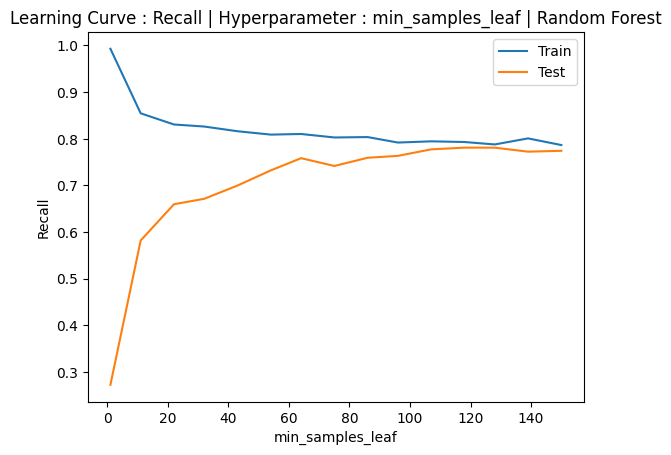

In [ ]:
#Learning curve for hyperparameters (min_samples_leaf)

# Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# param_values = [int(x) for x in np.linspace(1, 200, num = 35)] # n_estimators
# param_values = [int(x) for x in np.linspace(1, 100, num = 15)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 150, num = 15)] # min_samples_split
param_values = [int(x) for x in np.linspace(1, 150, num = 15)] # min_samples_leaf

train_scores = []
test_scores = []
difference_scores = []

for i in param_values:
    model = RandomForestClassifier(min_samples_leaf=i) # Change based on what hyperparameter that we used
    model.fit(x_train_sampled, y_train_sampled)

    # eval on train
    y_pred_train = model.predict(x_train_sampled)
    train_recall = recall_score(y_train_sampled, y_pred_train)
    train_scores.append(train_recall)

    # eval on test
    y_pred_test = model.predict(x_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_scores.append(test_recall)

    # difference eval on train and test
    diff_score = train_recall - test_recall
    difference_scores.append(diff_score)

    print('Param value: ' + str(i) + '; train: ' + str(train_recall) + '; test: '+ str(test_recall) + '; difference: '+ str(diff_score))

plt.title('Learning Curve : Recall | Hyperparameter : min_samples_leaf | Random Forest') # Change based on what hyperparameter that we used
plt.ylabel('Recall')
plt.xlabel('min_samples_leaf') # Change based on what hyperparameter that we used
plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

Param value: 1; train: 0.999820947002448; test: 0.6004089041137188; difference: 0.3994120428887291
Param value: 11; train: 0.939403187129734; test: 0.6919074353693624; difference: 0.24749575176037164
Param value: 22; train: 0.9114880464371532; test: 0.7116888815865597; difference: 0.19979916485059346
Param value: 32; train: 0.8984536324253629; test: 0.7123168412191311; difference: 0.18613679120623183
Param value: 43; train: 0.8862244983365506; test: 0.7175734056350055; difference: 0.1686510927015451
Param value: 54; train: 0.8802680149928623; test: 0.7166079405795216; difference: 0.16366007441334074
Param value: 64; train: 0.8780482149636294; test: 0.7187451279922203; difference: 0.15930308697140905
Param value: 75; train: 0.8719895434722126; test: 0.7204909038627791; difference: 0.15149863960943344
Param value: 86; train: 0.8632311616380134; test: 0.720316749772532; difference: 0.14291441186548137
Param value: 96; train: 0.8600691454811442; test: 0.7233743608428247; difference: 0.1366

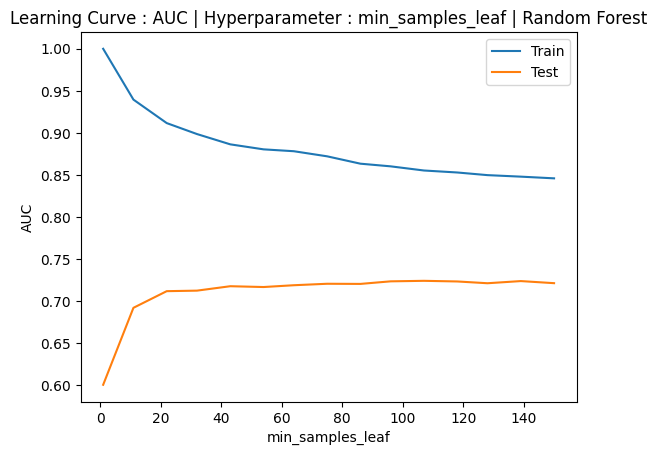

In [ ]:
#Learning curve for hyperparameters (min_samples_leaf)

# Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# param_values = [int(x) for x in np.linspace(1, 200, num = 35)] # n_estimators
# param_values = [int(x) for x in np.linspace(1, 100, num = 15)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 150, num = 15)] # min_samples_split
param_values = [int(x) for x in np.linspace(1, 150, num = 15)] # min_samples_leaf

train_scores = []
test_scores = []
difference_scores = []

for i in param_values:
    model = RandomForestClassifier(min_samples_leaf=i) # Change based on what hyperparameter that we used
    model.fit(x_train_sampled, y_train_sampled)

    # eval on train
    y_pred_train_proba = model.predict_proba(x_train_sampled)
    train_auc = roc_auc_score(y_train_sampled, y_pred_train_proba[:,1])
    train_scores.append(train_auc)

    # eval on test
    y_pred_proba = model.predict_proba(x_test)
    test_auc = roc_auc_score(y_test, y_pred_proba[:,1])
    test_scores.append(test_auc)

    # difference eval on train and test
    diff_score = train_auc - test_auc
    difference_scores.append(diff_score)

    print('Param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; difference: '+ str(diff_score))

plt.title('Learning Curve : AUC | Hyperparameter : min_samples_leaf | Random Forest') # Change based on what hyperparameter that we used
plt.ylabel('AUC')
plt.xlabel('min_samples_leaf') # Change based on what hyperparameter that we used
plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

Final Hyperparameter used are chosen based on learning curve, iteration of showing best hyperparameters, and some other references

In [ ]:
#Hyperparameter tuning for random forest

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

#Initiate hyperparameters used and their values
n_estimators = [int(x) for x in np.linspace(1, 75, num = 20)] # Number of trees in the forest
criterion = ['gini', 'entropy'] # Function to measure the quality of a split
max_depth = [int(x) for x in np.linspace(1, 60, num = 20)] # Maximum depth of the tree
min_samples_split = [int(x) for x in np.linspace(2, 140, num = 20)] # Minimum number of samples required to split an internal node
min_samples_leaf = [int(x) for x in np.linspace(1, 125, num = 20)] # Minimum number of samples required to be at a leaf node

#Collecting all hyperparameters into a single dictionary
hyperparameters = dict(n_estimators = n_estimators,
                       criterion = criterion,
                       max_depth = max_depth,
                       min_samples_split = min_samples_split,
                       min_samples_leaf = min_samples_leaf)

#Initiate tuned model
rf = RandomForestClassifier(random_state=42)
# rf_tuned = GridSearchCV(rf, hyperparameters, cv=5, scoring='recall')
rf_tuned = RandomizedSearchCV(rf, hyperparameters, random_state=42, cv=5, scoring='recall')
rf_tuned.fit(x_train_sampled, y_train_sampled)

#Tuned model evaluation
eval_classification(rf_tuned)

Accuracy (Test Set): 0.67
Precision (Test Set): 0.26
Recall (Test Set): 0.64
F1-Score (Test Set): 0.37
roc_auc (Train-Proba): 0.91
roc_auc (Test-Proba): 0.71
Recall (crossval train): 0.8294694226989524
Recall (crossval test): 0.8012392078604194
Recall Std Dev (crossval train): 0.011932884544508594
Recall Std Dev (crossval test): 0.12317161215998174


In [ ]:
show_best_hyperparameter(rf_tuned)

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 53, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 20, 'min_samples_split': 45, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 67, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [ ]:
# Retrieving the best hyperparameters for random forest (similar to show_best_hyperparameter code before, but only shows the ones that we used)
best_params = rf_tuned.best_params_
best_params

{'n_estimators': 67,
 'min_samples_split': 45,
 'min_samples_leaf': 20,
 'max_depth': 53,
 'criterion': 'gini'}

# Business Simulation

To assess the impact of model on your business, particularly in the context of completed bookings, we can look at the following aspects:

1. **Baseline Understanding:**
   - Start by understanding the baseline or original scenario. You mentioned that in the original data, 15% of customers complete the booking.

2. **Model's Performance:**
   - Evaluate how well your model performs, especially in terms of the True Positive Rate (Recall) for completed bookings. In your case, if the True Positive Rate is high, it means your model is effective in capturing a significant portion of customers who eventually complete their bookings.

3. **Increased True Positives:**
   - Compare the number of true positives (completed bookings) predicted by your model with the baseline. If your model predicts more true positives than what would be expected based on the baseline rate, it indicates a positive impact.

4. **Conversion Rate Improvement:**
   - Calculate the conversion rate using your model's predictions. The conversion rate is the ratio of predicted completed bookings to the total number of predictions.

   \[ \text{Conversion Rate} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} \]

   If the conversion rate is higher than the original completion rate, it suggests that your model is contributing to an improvement.

5. **Business Impact Assessment:**
   - Consider the business implications of correctly predicting completed bookings. If completing a booking has a positive impact on revenue or other key business metrics, then the increased number of true positives can be seen as a positive outcome.

6. **Cost-Benefit Analysis:**
   - Perform a cost-benefit analysis, taking into account any associated costs or benefits with each completed booking and the potential costs of false positives or false negatives. This will provide a more comprehensive understanding of the overall impact on the business.

In summary, assess how well your model is performing in terms of identifying customers who complete bookings, compare the model's predictions with the baseline, and consider the business implications of these predictions. It's essential to interpret the results in the context of your specific business goals and objectives.

**In this case we get conversion rate of 18% which is already pretty high in a business.**

# Model Deployment

## Save Model

**Additional Information About Libraries for Saving Model**

Both `pickle` and `joblib` are Python libraries that provide ways to serialize and deserialize objects, including machine learning models. They are used for saving and loading Python objects, and each has its own advantages and use cases.

Here are some key differences between `pickle` and `joblib`:

1. **Performance:**
   - `joblib` is generally more efficient in terms of serialization and deserialization speed, especially for large NumPy arrays and objects with large data structures.
   - `pickle` might be slower than `joblib` for certain use cases.

2. **Dependencies:**
   - `pickle` is a standard library module in Python, so it comes pre-installed with Python. It doesn't have external dependencies beyond the standard library.
   - `joblib` is an external library that you need to install separately using `pip install joblib`. It is not included in the standard library, but it is commonly used in the scientific computing and machine learning community.

3. **Handling NumPy arrays:**
   - `joblib` is particularly optimized for handling NumPy arrays, making it a good choice for saving and loading large numerical datasets efficiently.
   - `pickle` can also handle NumPy arrays, but `joblib` may be more performant for this specific use case.

4. **Compression:**
   - `joblib` supports optional compression, which can be beneficial when dealing with large datasets. You can compress the serialized file to reduce storage space and speed up the I/O operations.
   - `pickle` does not have built-in compression, but you can use external compression libraries in conjunction with `pickle` if needed.

5. **Compatibility:**
   - `pickle` is a standard library module that is widely available and compatible across different Python environments.
   - `joblib` is not a standard library module, so you need to ensure that it is available in your Python environment. While it is commonly used in data science and machine learning environments, it may not be available in every Python environment.

In summary, both `pickle` and `joblib` are suitable for saving and loading machine learning models, but `joblib` is often preferred for its performance benefits, especially when dealing with large numerical datasets. If you are working in a machine learning or scientific computing context, `joblib` might be a good choice. However, for basic serialization needs, `pickle` is a reliable and built-in option.

In [ ]:
import joblib

# Save random forest model
joblib.dump(rf_tuned, 'tuned_random_forest_model.joblib')

['tuned_random_forest_model.joblib']

In [ ]:
# # Install steamlit if you haven't

# pip install streamlit

Problem solving for error installing streamlit

https://youtu.be/zHAM5MGehV8?si=9KkUKX2PBg42sM-M

- The deployment will be done in a separate python file : model_deployment.py

- To run in terminal : streamlit run model_deployment.py

## **Additional Information About Model Deployment Using Streamlit**

**Scaling Process**

When you use MinMaxScaler or any other scaling technique during preprocessing to scale your features to a specific range (e.g., 0 to 1), it's important to use the same scaling on the input features during deployment.

Here's why:

1. **Consistency:** The model has been trained on the scaled features, so it expects input features to be in the same scale. If you provide unscaled features during testing or deployment, the model may not perform as expected.

2. **Normalization:** Many machine learning models, especially distance-based models or models with gradient-based optimization, benefit from normalized features. Normalization ensures that all features contribute equally to the model's learning process.

Therefore, when deploying your model, make sure to apply the same scaling transformation to the input features that you used during the preprocessing stage. This could involve using the MinMaxScaler (or any other scaler) with the same parameters that were used during training.

Here's an example of how you can use the scaler for deployment:

```python
import streamlit as st
import joblib

# Load the trained model
model = joblib.load('your_model_file.joblib')

# Load the scaler used during training
scaler = joblib.load('your_scaler_file.joblib')

# Create a Streamlit interface to take user input and make predictions
st.title('Your Machine Learning Model Deployment')

# Add input elements for the features
input_feature1 = st.number_input('Feature 1')
input_feature2 = st.number_input('Feature 2')
# Add more input features as needed

# Organize the user inputs into a list or array
user_inputs = [[input_feature1, input_feature2, ...]]

# Scale the user inputs using the same scaler
scaled_inputs = scaler.transform(user_inputs)

# Make predictions
prediction = model.predict(scaled_inputs)

# Display the prediction
st.success(f'The predicted class is {prediction[0]}')
```

In this example, `your_scaler_file.joblib` is the file where you saved the MinMaxScaler during training. Make sure to adjust the file names and paths based on your specific setup.

Using the same scaling parameters ensures that the model receives input features in the same scale it has seen during training, leading to more reliable predictions.

**Features Used**

The number of input elements in your Streamlit app should be based on the total number of features after the encoding process. When you perform feature engineering such as one-hot encoding and count/frequency encoding, you create additional features based on the original ones.

For example, if your original dataset had 5 categorical features and 8 numerical features, and after encoding, you end up with 20 features (10 from one-hot encoding and 10 from count/frequency encoding), then your Streamlit app should have input elements for all 20 features.

In the modified Streamlit code, you'll need to add input elements for each of the engineered features. Here's a general example:

```python
import streamlit as st
import joblib

# Load the trained model
model = joblib.load('your_model_file.joblib')

# Create a Streamlit interface to take user input and make predictions
st.title('Your Machine Learning Model Deployment')

# Add input elements for the encoded features
# Replace these with the actual names of your features
input_feature1 = st.slider('Feature 1', min_value=0.0, max_value=10.0, value=5.0)
input_feature2 = st.slider('Feature 2', min_value=0.0, max_value=10.0, value=5.0)
# Repeat this for all 20 features after encoding

# When the user clicks the 'Predict' button, make predictions using the loaded model
if st.button('Predict'):
    # Organize the user inputs into a list or array
    user_inputs = [input_feature1, input_feature2, ..., input_feature20]

    # Make predictions
    prediction = model.predict([user_inputs])

    # Display the prediction
    st.success(f'The predicted class is {prediction[0]}')
```

Make sure to adjust the input elements and their names based on your specific feature names after the encoding process. If you performed one-hot encoding, you might have binary features, and sliders might not be the best choice. You might need to use other Streamlit input elements, such as checkboxes or text inputs, depending on the nature of your encoded features.